[Data] N=100, T=60, D=5
[Data] states: (100, 60, 5), controls: (100, 60, 2), goals: (100, 2)
[Canonical] X1: (100, 5, 60), cond: (100, 5)
[Batch] x: torch.Size([64, 5, 60]), cond: torch.Size([64, 5])
[Model] 从头初始化 (随机权重)
[Model] Parameters: 2,904,965
[History] Previous epochs: 0

开始继续训练: 4000 epochs, LR=0.0005

  Epoch 50/4000 | loss=0.436690 | best=0.403008 | step=50
  Epoch 100/4000 | loss=0.313660 | best=0.248651 | step=100
  Epoch 150/4000 | loss=0.322538 | best=0.248651 | step=150
  Epoch 200/4000 | loss=0.293113 | best=0.208328 | step=200
  Epoch 250/4000 | loss=0.242946 | best=0.189925 | step=250
  Epoch 300/4000 | loss=0.195673 | best=0.185619 | step=300
  Epoch 350/4000 | loss=0.222276 | best=0.160940 | step=350
  Epoch 400/4000 | loss=0.187879 | best=0.160940 | step=400
  Epoch 450/4000 | loss=0.177227 | best=0.140601 | step=450
  Epoch 500/4000 | loss=0.196798 | best=0.140601 | step=500
  💾 Saved checkpoint: step=500, best_loss=0.140601
  Epoch 550/4000 | loss=0.168500 | bes

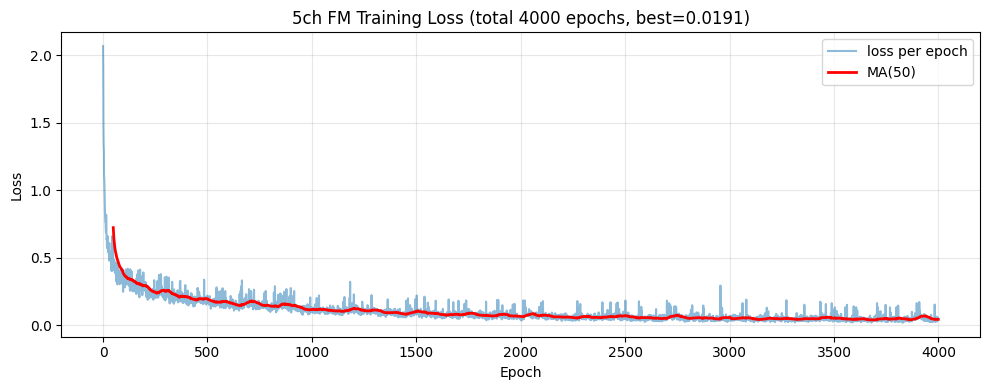

In [115]:
# ===============================================================
# 继续训练 model_5ch (Flow Matching 5-channel)
# ===============================================================
# 必须先运行 Cell 5 加载 model_5ch

import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path

torch.set_grad_enabled(True)  # 确保梯度开启

# ---------------------------------------------------------------
# 1) 加载数据 & 规范化
# ---------------------------------------------------------------
data_path = Path("cache/car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")
if not data_path.exists():
    data_path = Path(r"D:\projects\lab2025\dmpc_fm_cbf\notebooks\cache\car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")

raw = np.load(str(data_path), allow_pickle=True).item()
states   = raw['states']      # (N, T, 5) = [x, y, theta, v, delta]
controls = raw['controls']    # (N, T, 2) = [a, delta_rate]
goals    = raw.get('goals', None)

N, T, D = states.shape
print(f"[Data] N={N}, T={T}, D={D}")
print(f"[Data] states: {states.shape}, controls: {controls.shape}, goals: {goals.shape if goals is not None else None}")

# 构建 5-channel: [x, y, theta, a, delta_rate]
traj_5ch = np.stack([
    states[:, :, 0],       # x
    states[:, :, 1],       # y
    states[:, :, 2],       # theta
    controls[:, :, 0],     # a
    controls[:, :, 1],     # delta_rate
], axis=1)  # (N, 5, T)

# Canonical frame: 每条轨迹以 start->goal 为 x 轴
def canonicalize_batch(trajs, goals_xy=None):
    """trajs: (N,5,T), goals_xy: (N,2) or None"""
    N2 = trajs.shape[0]
    out = trajs.copy()
    cond_list = []
    for i in range(N2):
        x0, y0 = trajs[i, 0, 0], trajs[i, 1, 0]
        if goals_xy is not None:
            gx, gy = goals_xy[i]
        else:
            gx, gy = trajs[i, 0, -1], trajs[i, 1, -1]
        dx, dy = gx - x0, gy - y0
        dist = float(np.sqrt(dx**2 + dy**2) + 1e-9)
        cos_a, sin_a = dx / dist, dy / dist
        # Rotate XY
        rx = cos_a * (trajs[i, 0] - x0) + sin_a * (trajs[i, 1] - y0)
        ry = -sin_a * (trajs[i, 0] - x0) + cos_a * (trajs[i, 1] - y0)
        out[i, 0] = rx
        out[i, 1] = ry
        # Rotate theta
        angle_off = float(np.arctan2(sin_a, cos_a))
        out[i, 2] = np.array([float((th - angle_off + np.pi) % (2*np.pi) - np.pi) for th in trajs[i, 2]])
        # cond: [dist, v0, cos(th0_can), sin(th0_can), delta0]
        th0_can = float((trajs[i, 2, 0] - angle_off + np.pi) % (2*np.pi) - np.pi)
        cond_list.append([dist, float(states[i, 0, 3]),
                          float(np.cos(th0_can)), float(np.sin(th0_can)),
                          float(states[i, 0, 4])])
    return out, np.array(cond_list, dtype=np.float32)

X1, cond_all = canonicalize_batch(traj_5ch, goals)
print(f"[Canonical] X1: {X1.shape}, cond: {cond_all.shape}")

X1_t = torch.tensor(X1, dtype=torch.float32, device=device)
cond_t = torch.tensor(cond_all, dtype=torch.float32, device=device)

ds = TensorDataset(X1_t, cond_t)
dl = DataLoader(ds, batch_size=64, shuffle=True, drop_last=True)

# 测试 batch
for xb, cb in dl:
    print(f"[Batch] x: {xb.shape}, cond: {cb.shape}")
    break

# ---------------------------------------------------------------
# 2) 从头初始化模型 & optimizer (不加载 checkpoint)
# ---------------------------------------------------------------
from fmtorch.models.simple1d_unet import SimpleUNet1D

ckpt_path = Path("cache/model_vel_5ch_canonical_r.pt")

# 重新初始化模型 (随机权重)
model_5ch = SimpleUNet1D(
    time_emb_dim=128,
    hidden_dim=128,
    cond_dim=5,
    in_channels=5,
    out_channels=5,
).to(device)

model_5ch.train()
global_step = 0
best_loss   = float('inf')
history     = []

print(f"[Model] 从头初始化 (随机权重)")
print(f"[Model] Parameters: {sum(p.numel() for p in model_5ch.parameters()):,}")

LR = 5e-4
GRAD_CLIP = 1.0
optimizer = torch.optim.AdamW(model_5ch.parameters(), lr=LR, weight_decay=1e-5)

print(f"[History] Previous epochs: {len(history)}")

# ---------------------------------------------------------------
# 3) Training loop
# ---------------------------------------------------------------
EPOCHS = 4000
SAVE_EVERY = 500

print(f"\n{'='*60}")
print(f"开始继续训练: {EPOCHS} epochs, LR={LR}")
print(f"{'='*60}\n")

for epoch in range(1, EPOCHS + 1):
    epoch_loss = 0.0
    n_batch = 0

    for x_1, cond_b in dl:
        B = x_1.shape[0]
        x_0 = torch.randn_like(x_1)
        t = torch.rand(B, device=device)
        t_exp = t.view(B, 1, 1)

        x_t = (1 - t_exp) * x_0 + t_exp * x_1
        v_target = x_1 - x_0
        v_pred = model_5ch(x_t, t, cond=cond_b)
        loss = F.mse_loss(v_pred, v_target)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_5ch.parameters(), GRAD_CLIP)
        optimizer.step()

        epoch_loss += loss.item()
        n_batch += 1

    avg_loss = epoch_loss / max(n_batch, 1)
    history.append(avg_loss)
    global_step += 1

    if avg_loss < best_loss:
        best_loss = avg_loss

    if epoch % 50 == 0:
        print(f"  Epoch {epoch}/{EPOCHS} | loss={avg_loss:.6f} | best={best_loss:.6f} | step={global_step}")

    if epoch % SAVE_EVERY == 0:
        torch.save({
            'model_state_dict': model_5ch.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'global_step': global_step,
            'best_loss': best_loss,
            'history': history,
        }, str(ckpt_path))
        print(f"  💾 Saved checkpoint: step={global_step}, best_loss={best_loss:.6f}")

# Final save
torch.save({
    'model_state_dict': model_5ch.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'global_step': global_step,
    'best_loss': best_loss,
    'history': history,
}, str(ckpt_path))

print(f"\n✅ 训练完成! 总 epochs: {global_step}, best_loss: {best_loss:.6f}")

# ---------------------------------------------------------------
# 4) Plot training curve
# ---------------------------------------------------------------
model_5ch.eval()

plt.figure(figsize=(10, 4))
plt.plot(history, alpha=0.5, label='loss per epoch')
if len(history) > 20:
    window = min(50, len(history) // 5)
    smooth = np.convolve(np.array(history, dtype=np.float64), np.ones(window)/window, mode='valid')
    plt.plot(range(window-1, len(history)), smooth, 'r-', lw=2, label=f'MA({window})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'5ch FM Training Loss (total {global_step} epochs, best={best_loss:.4f})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

[Data] N=100, T=60, D=5
[Canonical] X1: (100, 5, 60), cond: (100, 5)
[Split] Train: 80, Val: 20
[Model] Parameters: 2,904,965

Training: 4000 epochs, LR=0.0005
Train: 80, Val: 20

  Epoch    1 | train=2.369664 | val=1.781698 * (best)
  Epoch   50 | train=0.456482 | val=0.599788 * (best)
  Epoch  100 | train=0.293754 | val=0.420579 * (best)
  Epoch  150 | train=0.270199 | val=0.393799 * (best)
  Epoch  200 | train=0.230915 | val=0.389634 * (best)
  Epoch  250 | train=0.230300 | val=0.476563
  Epoch  300 | train=0.178178 | val=0.437105
  Epoch  350 | train=0.172068 | val=0.409355
  Epoch  400 | train=0.192252 | val=0.725121
  Epoch  450 | train=0.158732 | val=0.502803
  Epoch  500 | train=0.163946 | val=0.395053
  Epoch  550 | train=0.155929 | val=0.357813 * (best)
  Epoch  600 | train=0.125715 | val=0.366060
  Epoch  650 | train=0.146123 | val=0.360205
  Epoch  700 | train=0.115641 | val=0.412500
  Epoch  750 | train=0.117007 | val=0.509194
  Epoch  800 | train=0.133554 | val=0.330864 *

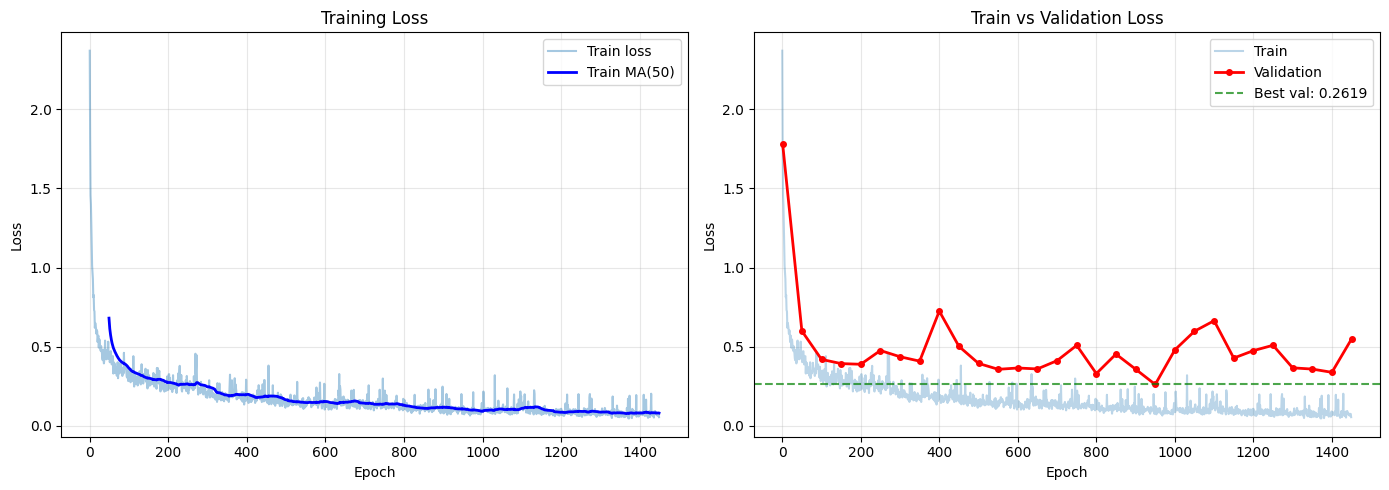


[Overfitting Check]
  Final train loss: 0.055821
  Final val loss:   0.548966
  Gap (val - train): 0.493146


In [116]:
# ===============================================================
# 训练 model_5ch (Flow Matching 5-channel) - 带 Validation
# ===============================================================

import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from pathlib import Path

torch.set_grad_enabled(True)

# ---------------------------------------------------------------
# 1) 加载数据 & 规范化
# ---------------------------------------------------------------
data_path = Path("cache/car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")
if not data_path.exists():
    data_path = Path(r"D:\projects\lab2025\dmpc_fm_cbf\notebooks\cache\car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")

raw = np.load(str(data_path), allow_pickle=True).item()
states   = raw['states']
controls = raw['controls']
goals    = raw.get('goals', None)

N, T, D = states.shape
print(f"[Data] N={N}, T={T}, D={D}")

# 构建 5-channel
traj_5ch = np.stack([
    states[:, :, 0],
    states[:, :, 1],
    states[:, :, 2],
    controls[:, :, 0],
    controls[:, :, 1],
], axis=1)

def canonicalize_batch(trajs, goals_xy=None):
    N2 = trajs.shape[0]
    out = trajs.copy()
    cond_list = []
    for i in range(N2):
        x0, y0 = trajs[i, 0, 0], trajs[i, 1, 0]
        if goals_xy is not None:
            gx, gy = goals_xy[i]
        else:
            gx, gy = trajs[i, 0, -1], trajs[i, 1, -1]
        dx, dy = gx - x0, gy - y0
        dist = float(np.sqrt(dx**2 + dy**2) + 1e-9)
        cos_a, sin_a = dx / dist, dy / dist
        rx = cos_a * (trajs[i, 0] - x0) + sin_a * (trajs[i, 1] - y0)
        ry = -sin_a * (trajs[i, 0] - x0) + cos_a * (trajs[i, 1] - y0)
        out[i, 0] = rx
        out[i, 1] = ry
        angle_off = float(np.arctan2(sin_a, cos_a))
        out[i, 2] = np.array([float((th - angle_off + np.pi) % (2*np.pi) - np.pi) for th in trajs[i, 2]])
        th0_can = float((trajs[i, 2, 0] - angle_off + np.pi) % (2*np.pi) - np.pi)
        cond_list.append([dist, float(states[i, 0, 3]),
                          float(np.cos(th0_can)), float(np.sin(th0_can)),
                          float(states[i, 0, 4])])
    return out, np.array(cond_list, dtype=np.float32)

X1, cond_all = canonicalize_batch(traj_5ch, goals)
print(f"[Canonical] X1: {X1.shape}, cond: {cond_all.shape}")

X1_t = torch.tensor(X1, dtype=torch.float32, device=device)
cond_t = torch.tensor(cond_all, dtype=torch.float32, device=device)

# ---------------------------------------------------------------
# 2) Train/Val Split (80/20)
# ---------------------------------------------------------------
full_ds = TensorDataset(X1_t, cond_t)

train_size = int(0.8 * len(full_ds))
val_size = len(full_ds) - train_size

train_ds, val_ds = random_split(full_ds, [train_size, val_size], 
                                 generator=torch.Generator().manual_seed(42))

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, drop_last=True)
val_dl = DataLoader(val_ds, batch_size=64, shuffle=False, drop_last=False)

print(f"[Split] Train: {len(train_ds)}, Val: {len(val_ds)}")

# ---------------------------------------------------------------
# 3) 模型初始化
# ---------------------------------------------------------------
from fmtorch.models.simple1d_unet import SimpleUNet1D

ckpt_path = Path("cache/model_vel_5ch_canonical_val.pt")

model_5ch = SimpleUNet1D(
    time_emb_dim=128,
    hidden_dim=128,
    cond_dim=5,
    in_channels=5,
    out_channels=5,
).to(device)

model_5ch.train()
global_step = 0
best_val_loss = float('inf')
train_history = []
val_history = []

print(f"[Model] Parameters: {sum(p.numel() for p in model_5ch.parameters()):,}")

LR = 5e-4
GRAD_CLIP = 1.0
optimizer = torch.optim.AdamW(model_5ch.parameters(), lr=LR, weight_decay=1e-5)

# ---------------------------------------------------------------
# 4) Validation 函数
# ---------------------------------------------------------------
@torch.no_grad()
def validate(model, val_dl):
    model.eval()
    total_loss = 0.0
    n_batch = 0
    
    for x_1, cond_b in val_dl:
        B = x_1.shape[0]
        x_0 = torch.randn_like(x_1)
        t = torch.rand(B, device=device)
        t_exp = t.view(B, 1, 1)
        
        x_t = (1 - t_exp) * x_0 + t_exp * x_1
        v_target = x_1 - x_0
        v_pred = model(x_t, t, cond=cond_b)
        loss = F.mse_loss(v_pred, v_target)
        
        total_loss += loss.item()
        n_batch += 1
    
    model.train()
    return total_loss / max(n_batch, 1)

# ---------------------------------------------------------------
# 5) Training loop with validation
# ---------------------------------------------------------------
EPOCHS = 4000
SAVE_EVERY = 500
VAL_EVERY = 50
PATIENCE = 500

no_improve_count = 0

print(f"\n{'='*60}")
print(f"Training: {EPOCHS} epochs, LR={LR}")
print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")
print(f"{'='*60}\n")

for epoch in range(1, EPOCHS + 1):
    # ----- Training -----
    model_5ch.train()
    epoch_loss = 0.0
    n_batch = 0

    for x_1, cond_b in train_dl:
        B = x_1.shape[0]
        x_0 = torch.randn_like(x_1)
        t = torch.rand(B, device=device)
        t_exp = t.view(B, 1, 1)

        x_t = (1 - t_exp) * x_0 + t_exp * x_1
        v_target = x_1 - x_0
        v_pred = model_5ch(x_t, t, cond=cond_b)
        loss = F.mse_loss(v_pred, v_target)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_5ch.parameters(), GRAD_CLIP)
        optimizer.step()

        epoch_loss += loss.item()
        n_batch += 1

    avg_train_loss = epoch_loss / max(n_batch, 1)
    train_history.append(avg_train_loss)
    global_step += 1

    # ----- Validation -----
    if epoch % VAL_EVERY == 0 or epoch == 1:
        val_loss = validate(model_5ch, val_dl)
        val_history.append((epoch, val_loss))
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            no_improve_count = 0
            torch.save({
                'model_state_dict': model_5ch.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'global_step': global_step,
                'best_val_loss': best_val_loss,
                'train_history': train_history,
                'val_history': val_history,
            }, str(ckpt_path))
            print(f"  Epoch {epoch:4d} | train={avg_train_loss:.6f} | val={val_loss:.6f} * (best)")
        else:
            no_improve_count += VAL_EVERY
            print(f"  Epoch {epoch:4d} | train={avg_train_loss:.6f} | val={val_loss:.6f}")
        
        if no_improve_count >= PATIENCE:
            print(f"\n[Early Stop] epoch {epoch}, no improvement for {PATIENCE} epochs")
            break
    
    elif epoch % 100 == 0:
        print(f"  Epoch {epoch:4d} | train={avg_train_loss:.6f}")

print(f"\nDone! Epochs: {global_step}, Best val loss: {best_val_loss:.6f}")

# ---------------------------------------------------------------
# 6) Plot training curves
# ---------------------------------------------------------------
model_5ch.eval()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(train_history, alpha=0.4, label='Train loss')
if len(train_history) > 50:
    window = 50
    smooth = np.convolve(np.array(train_history), np.ones(window)/window, mode='valid')
    ax1.plot(range(window-1, len(train_history)), smooth, 'b-', lw=2, label=f'Train MA({window})')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = axes[1]
val_epochs = [v[0] for v in val_history]
val_losses = [v[1] for v in val_history]
ax2.plot(train_history, alpha=0.3, label='Train')
ax2.plot(val_epochs, val_losses, 'ro-', lw=2, markersize=4, label='Validation')
ax2.axhline(best_val_loss, color='g', ls='--', alpha=0.7, label=f'Best val: {best_val_loss:.4f}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Train vs Validation Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# 7) Overfitting check
# ---------------------------------------------------------------
if len(val_history) >= 2:
    final_train = train_history[-1]
    final_val = val_history[-1][1]
    gap = final_val - final_train
    
    print(f"\n[Overfitting Check]")
    print(f"  Final train loss: {final_train:.6f}")
    print(f"  Final val loss:   {final_val:.6f}")
    print(f"  Gap (val - train): {gap:.6f}")
    
    if gap > 0.01:
        print("  Warning: possible overfitting")
    else:
        print("  OK: no obvious overfitting")

[Data] N=100, T=60, D=5
[Canonical] X1: (100, 5, 60), cond: (100, 5)
[Augmented] X1: (1500, 5, 60), cond: (1500, 5)
[Split] Train: 1200, Val: 300
[Model] Parameters: 731,589 (small model)
[Model] Data/Param ratio: 0.0016

Training: 3000 epochs, LR=0.0003, weight_decay=0.0005
Train: 1200, Val: 300
Input noise: 0.02, Patience: 300

  Epoch    1 | train=1.2492 | val=0.8681 | gap=-0.3810 * (best)
  Epoch   50 | train=0.2278 | val=0.2503 | gap=0.0225 * (best)
  Epoch  100 | train=0.1764 | val=0.1558 | gap=-0.0206 * (best)
  Epoch  150 | train=0.1514 | val=0.1553 | gap=0.0039 * (best)
  Epoch  200 | train=0.1702 | val=0.1342 | gap=-0.0360 * (best)
  Epoch  250 | train=0.1192 | val=0.1194 | gap=0.0002 * (best)
  Epoch  300 | train=0.1103 | val=0.1099 | gap=-0.0003 * (best)
  Epoch  350 | train=0.0951 | val=0.0967 | gap=0.0017 * (best)
  Epoch  400 | train=0.0958 | val=0.0749 | gap=-0.0209 * (best)
  Epoch  450 | train=0.0877 | val=0.0908 | gap=0.0031
  Epoch  500 | train=0.0932 | val=0.0805 |

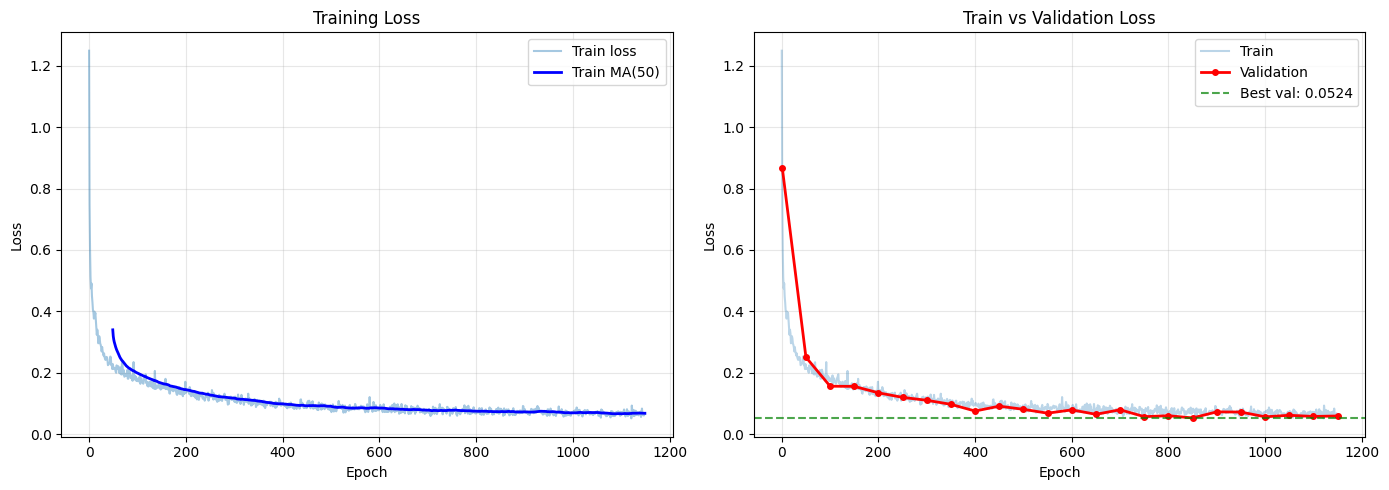


[Overfitting Check]
  Final train loss: 0.064998
  Final val loss:   0.058793
  Gap (val - train): -0.006206
  OK: no obvious overfitting

[Load Best] Loading from cache\model_vel_5ch_small.pt
[Load Best] Done, best_val_loss=0.052434


In [117]:
# ===============================================================
# 训练 model_5ch (Flow Matching 5-channel) - 小模型 + 抗过拟合
# ===============================================================

import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from pathlib import Path

torch.set_grad_enabled(True)

# ---------------------------------------------------------------
# 1) 加载数据 & 规范化
# ---------------------------------------------------------------
data_path = Path("cache/car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")
if not data_path.exists():
    data_path = Path(r"D:\projects\lab2025\dmpc_fm_cbf\notebooks\cache\car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")

raw = np.load(str(data_path), allow_pickle=True).item()
states   = raw['states']
controls = raw['controls']
goals    = raw.get('goals', None)

N, T, D = states.shape
print(f"[Data] N={N}, T={T}, D={D}")

# 构建 5-channel
traj_5ch = np.stack([
    states[:, :, 0],
    states[:, :, 1],
    states[:, :, 2],
    controls[:, :, 0],
    controls[:, :, 1],
], axis=1)

def canonicalize_batch(trajs, goals_xy=None):
    N2 = trajs.shape[0]
    out = trajs.copy()
    cond_list = []
    for i in range(N2):
        x0, y0 = trajs[i, 0, 0], trajs[i, 1, 0]
        if goals_xy is not None:
            gx, gy = goals_xy[i]
        else:
            gx, gy = trajs[i, 0, -1], trajs[i, 1, -1]
        dx, dy = gx - x0, gy - y0
        dist = float(np.sqrt(dx**2 + dy**2) + 1e-9)
        cos_a, sin_a = dx / dist, dy / dist
        rx = cos_a * (trajs[i, 0] - x0) + sin_a * (trajs[i, 1] - y0)
        ry = -sin_a * (trajs[i, 0] - x0) + cos_a * (trajs[i, 1] - y0)
        out[i, 0] = rx
        out[i, 1] = ry
        angle_off = float(np.arctan2(sin_a, cos_a))
        out[i, 2] = np.array([float((th - angle_off + np.pi) % (2*np.pi) - np.pi) for th in trajs[i, 2]])
        th0_can = float((trajs[i, 2, 0] - angle_off + np.pi) % (2*np.pi) - np.pi)
        cond_list.append([dist, float(states[i, 0, 3]),
                          float(np.cos(th0_can)), float(np.sin(th0_can)),
                          float(states[i, 0, 4])])
    return out, np.array(cond_list, dtype=np.float32)

X1, cond_all = canonicalize_batch(traj_5ch, goals)
print(f"[Canonical] X1: {X1.shape}, cond: {cond_all.shape}")

# ---------------------------------------------------------------
# 2) 数据增强 (解决数据量不足)
# ---------------------------------------------------------------
def augment_data(X1, cond_all, aug_factor=10):
    N, C, T = X1.shape
    augmented_X = [X1]
    augmented_cond = [cond_all]
    
    np.random.seed(42)
    
    for i in range(aug_factor - 1):
        # 添加小噪声
        noise_X = X1.copy()
        noise_X[:, 0:2, :] += np.random.randn(N, 2, T) * 0.02
        noise_X[:, 2, :] += np.random.randn(N, T) * 0.03
        noise_X[:, 3:5, :] += np.random.randn(N, 2, T) * 0.01
        
        noise_cond = cond_all.copy()
        noise_cond[:, 0] *= (1 + np.random.randn(N) * 0.02)
        noise_cond[:, 1] += np.random.randn(N) * 0.02
        
        augmented_X.append(noise_X)
        augmented_cond.append(noise_cond)
        
        # Y轴镜像 (每隔一次)
        if i % 2 == 0:
            mirror_X = X1.copy()
            mirror_X[:, 1, :] *= -1
            mirror_X[:, 2, :] *= -1
            mirror_X[:, 1, :] += np.random.randn(N, T) * 0.01
            
            mirror_cond = cond_all.copy()
            mirror_cond[:, 3] *= -1
            
            augmented_X.append(mirror_X)
            augmented_cond.append(mirror_cond)
    
    return (np.concatenate(augmented_X, axis=0).astype(np.float32),
            np.concatenate(augmented_cond, axis=0).astype(np.float32))

X1_aug, cond_aug = augment_data(X1, cond_all, aug_factor=10)
print(f"[Augmented] X1: {X1_aug.shape}, cond: {cond_aug.shape}")

X1_t = torch.tensor(X1_aug, dtype=torch.float32, device=device)
cond_t = torch.tensor(cond_aug, dtype=torch.float32, device=device)

# ---------------------------------------------------------------
# 3) Train/Val Split (80/20)
# ---------------------------------------------------------------
full_ds = TensorDataset(X1_t, cond_t)

train_size = int(0.8 * len(full_ds))
val_size = len(full_ds) - train_size

train_ds, val_ds = random_split(full_ds, [train_size, val_size], 
                                 generator=torch.Generator().manual_seed(42))

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, drop_last=True)
val_dl = DataLoader(val_ds, batch_size=64, shuffle=False, drop_last=False)

print(f"[Split] Train: {len(train_ds)}, Val: {len(val_ds)}")

# ---------------------------------------------------------------
# 4) 小模型初始化 (防止过拟合)
# ---------------------------------------------------------------
from fmtorch.models.simple1d_unet import SimpleUNet1D

ckpt_path = Path("cache/model_vel_5ch_small.pt")

# 小模型: hidden_dim 128 -> 64
model_5ch = SimpleUNet1D(
    time_emb_dim=64,    # 128 -> 64
    hidden_dim=64,      # 128 -> 64
    cond_dim=5,
    in_channels=5,
    out_channels=5,
).to(device)

model_5ch.train()
global_step = 0
best_val_loss = float('inf')
train_history = []
val_history = []

n_params = sum(p.numel() for p in model_5ch.parameters())
print(f"[Model] Parameters: {n_params:,} (small model)")
print(f"[Model] Data/Param ratio: {len(train_ds) / n_params:.4f}")

# 强正则化
LR = 3e-4
WEIGHT_DECAY = 5e-4
GRAD_CLIP = 1.0
optimizer = torch.optim.AdamW(model_5ch.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# ---------------------------------------------------------------
# 5) Validation 函数
# ---------------------------------------------------------------
@torch.no_grad()
def validate(model, val_dl):
    model.eval()
    total_loss = 0.0
    n_batch = 0
    
    for x_1, cond_b in val_dl:
        B = x_1.shape[0]
        x_0 = torch.randn_like(x_1)
        t = torch.rand(B, device=device)
        t_exp = t.view(B, 1, 1)
        
        x_t = (1 - t_exp) * x_0 + t_exp * x_1
        v_target = x_1 - x_0
        v_pred = model(x_t, t, cond=cond_b)
        loss = F.mse_loss(v_pred, v_target)
        
        total_loss += loss.item()
        n_batch += 1
    
    model.train()
    return total_loss / max(n_batch, 1)

# ---------------------------------------------------------------
# 6) Training loop
# ---------------------------------------------------------------
EPOCHS = 3000
VAL_EVERY = 50
PATIENCE = 300
INPUT_NOISE = 0.02

no_improve_count = 0

print(f"\n{'='*60}")
print(f"Training: {EPOCHS} epochs, LR={LR}, weight_decay={WEIGHT_DECAY}")
print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")
print(f"Input noise: {INPUT_NOISE}, Patience: {PATIENCE}")
print(f"{'='*60}\n")

for epoch in range(1, EPOCHS + 1):
    model_5ch.train()
    epoch_loss = 0.0
    n_batch = 0

    for x_1, cond_b in train_dl:
        B = x_1.shape[0]
        
        # 训练时添加输入噪声 (额外正则化)
        x_1_noisy = x_1 + torch.randn_like(x_1) * INPUT_NOISE
        
        x_0 = torch.randn_like(x_1)
        t = torch.rand(B, device=device)
        t_exp = t.view(B, 1, 1)

        x_t = (1 - t_exp) * x_0 + t_exp * x_1_noisy
        v_target = x_1_noisy - x_0
        v_pred = model_5ch(x_t, t, cond=cond_b)
        loss = F.mse_loss(v_pred, v_target)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_5ch.parameters(), GRAD_CLIP)
        optimizer.step()

        epoch_loss += loss.item()
        n_batch += 1

    avg_train_loss = epoch_loss / max(n_batch, 1)
    train_history.append(avg_train_loss)
    global_step += 1

    # Validation
    if epoch % VAL_EVERY == 0 or epoch == 1:
        val_loss = validate(model_5ch, val_dl)
        val_history.append((epoch, val_loss))
        
        gap = val_loss - avg_train_loss
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            no_improve_count = 0
            torch.save({
                'model_state_dict': model_5ch.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'global_step': global_step,
                'best_val_loss': best_val_loss,
                'train_history': train_history,
                'val_history': val_history,
            }, str(ckpt_path))
            print(f"  Epoch {epoch:4d} | train={avg_train_loss:.4f} | val={val_loss:.4f} | gap={gap:.4f} * (best)")
        else:
            no_improve_count += VAL_EVERY
            print(f"  Epoch {epoch:4d} | train={avg_train_loss:.4f} | val={val_loss:.4f} | gap={gap:.4f}")
        
        if no_improve_count >= PATIENCE:
            print(f"\n[Early Stop] epoch {epoch}, no improvement for {PATIENCE} epochs")
            break
    
    elif epoch % 100 == 0:
        print(f"  Epoch {epoch:4d} | train={avg_train_loss:.4f}")

print(f"\nDone! Epochs: {global_step}, Best val loss: {best_val_loss:.6f}")

# ---------------------------------------------------------------
# 7) Plot training curves
# ---------------------------------------------------------------
model_5ch.eval()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(train_history, alpha=0.4, label='Train loss')
if len(train_history) > 50:
    window = 50
    smooth = np.convolve(np.array(train_history), np.ones(window)/window, mode='valid')
    ax1.plot(range(window-1, len(train_history)), smooth, 'b-', lw=2, label=f'Train MA({window})')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = axes[1]
val_epochs = [v[0] for v in val_history]
val_losses = [v[1] for v in val_history]
ax2.plot(train_history, alpha=0.3, label='Train')
ax2.plot(val_epochs, val_losses, 'ro-', lw=2, markersize=4, label='Validation')
ax2.axhline(best_val_loss, color='g', ls='--', alpha=0.7, label=f'Best val: {best_val_loss:.4f}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Train vs Validation Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# 8) Overfitting check
# ---------------------------------------------------------------
if len(val_history) >= 2:
    final_train = train_history[-1]
    final_val = val_history[-1][1]
    gap = final_val - final_train
    
    print(f"\n[Overfitting Check]")
    print(f"  Final train loss: {final_train:.6f}")
    print(f"  Final val loss:   {final_val:.6f}")
    print(f"  Gap (val - train): {gap:.6f}")
    
    if gap > 0.05:
        print("  Warning: still overfitting, consider more data or smaller model")
    elif gap > 0.02:
        print("  Mild overfitting, but acceptable")
    else:
        print("  OK: no obvious overfitting")

# ---------------------------------------------------------------
# 9) 加载最佳模型用于后续使用
# ---------------------------------------------------------------
print(f"\n[Load Best] Loading from {ckpt_path}")
ckpt = torch.load(str(ckpt_path), map_location=device)
model_5ch.load_state_dict(ckpt['model_state_dict'])
model_5ch.eval()
print(f"[Load Best] Done, best_val_loss={ckpt['best_val_loss']:.6f}")

In [5]:
# ===============================================================
# FINAL CELL (SMOOTH) — GPU-friendly version
# Warm-start DMPC (K=1)
# FM ODE with CBF INSIDE (first-step only)
# + EMA smoothing
# + Goal-pull (soft heading correction)
#
# Key speed fix:
#   ✅ remove CPU<->GPU ping-pong inside ODE rhs
#   ✅ canonicalize/uncanonicalize in TORCH (on device)
#   ✅ pre-create tensors used by CBF (no torch.tensor(...) in rhs)
# ===============================================================

import sys
from pathlib import Path

sys.path.insert(0, "..")

import numpy as np
import torch
import torchdiffeq
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------------------------------------------
# Preconditions
# ---------------------------------------------------------------
# NOTE: this notebook runs in a separate kernel from demo.ipynb.
# If you trained in demo, save/load the checkpoint here.
MODEL_CKPT = "cache/model_vel.pt"  # change if you saved elsewhere

# Try a few common locations
ckpt_candidates = [
    Path(MODEL_CKPT),
    Path("..") / "cache" / "model_vel.pt",
    Path.cwd() / "cache" / "model_vel.pt",
    Path.cwd().parent / "cache" / "model_vel.pt",
]
ckpt_path = next((p for p in ckpt_candidates if p.exists()), None)

if "model_vel" not in globals():
    if "trainer" in globals():
        model_vel = trainer.model
    else:
        if ckpt_path is not None:
            from fmtorch.models.simple1d_unet import SimpleUNet1D
            ckpt = torch.load(str(ckpt_path), map_location=device)
            model_vel = SimpleUNet1D(time_emb_dim=128, hidden_dim=128, cond_dim=5).to(device)
            model_vel.load_state_dict(ckpt["model_state_dict"])
            print("Loaded model checkpoint:", ckpt_path)
        else:
            raise RuntimeError(
                "model_vel not found. Train in this notebook or set MODEL_CKPT to a saved model."
            )
if "cbf_project_velocity_world" not in globals():
    import importlib.util
    cbf_path = Path.cwd().parent / "dmpc_fm_cbf" / "cbf.py"
    if cbf_path.exists():
        spec = importlib.util.spec_from_file_location("dmpc_fm_cbf.cbf", str(cbf_path))
        cbf_mod = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(cbf_mod)
        cbf_project_velocity_world = cbf_mod.cbf_project_velocity_world
    else:
        raise RuntimeError(f"cbf.py not found at {cbf_path}")

model_vel = model_vel.to(device).eval()

Loaded model checkpoint: cache\model_vel.pt


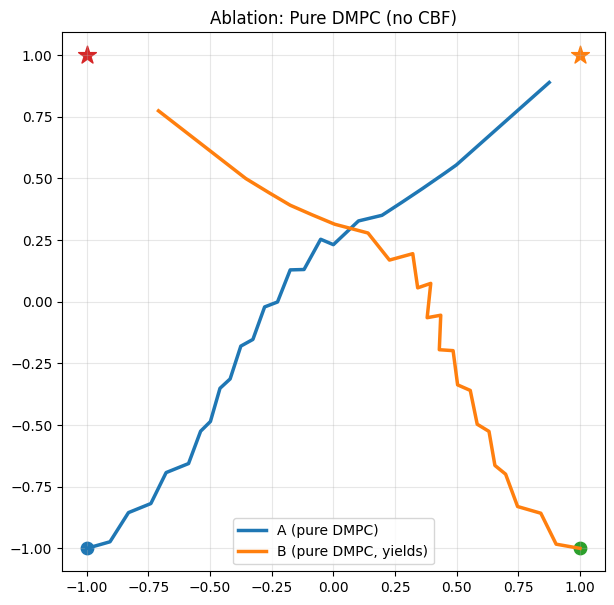

In [ ]:
# ===============================================================
# ABLATION CELL 1: Pure DMPC (dynamics + cost), NO CBF
# - Two agents, point-mass kinematics x_{t+1} = x_t + dt * v
# - DMPC warm-start: each agent plans against the OTHER's last predicted trajectory
# - Candidate actions: heading grid around goal direction + discrete speed scales
# - Cost: goal + smooth(turn) + soft distance violation + speed preference (optional)
# ===============================================================

import numpy as np
import matplotlib.pyplot as plt

def _wrap_pi(a: float) -> float:
    return float((a + np.pi) % (2 * np.pi) - np.pi)

def _unit(v):
    n = float(np.linalg.norm(v) + 1e-9)
    return v / n

def straight_pred(x, g, dt, v_max, s, H):
    d = _unit(g - x)
    traj = [x.copy()]
    xk = x.copy()
    for _ in range(int(H)):
        xk = xk + float(dt) * float(v_max) * float(s) * d
        traj.append(xk.copy())
    return np.asarray(traj, dtype=np.float64)

def rollout_from_action(x0, v_seq, dt):
    x = x0.copy()
    traj = [x.copy()]
    for k in range(v_seq.shape[0]):
        x = x + float(dt) * v_seq[k]
        traj.append(x.copy())
    return np.asarray(traj, dtype=np.float64)

def dmcp_pick_best_action(
    x, g, other_pred,
    *,
    dt, H,
    v_max,
    speed_scales,
    heading_span_deg=140.0,
    heading_samples=25,
    d_safe=1.05,
    # costs
    w_goal=35.0,
    w_dist=100.0,
    w_turn=1.5,
    w_speed=0.2,
    prev_v=None,
):
    # base heading = goal direction
    d_goal = g - x
    base = float(np.arctan2(d_goal[1], d_goal[0]))
    span = np.deg2rad(float(heading_span_deg))
    offs = np.linspace(-span/2.0, span/2.0, int(heading_samples), dtype=np.float64)

    bestJ = float("inf")
    best_v0 = np.zeros(2, dtype=np.float64)
    best_traj = None

    def hinge(z): return max(0.0, float(z))

    for off in offs:
        h = float(base + off)
        dirv = np.array([np.cos(h), np.sin(h)], dtype=np.float64)

        for s in speed_scales:
            s = float(s)
            v0 = float(v_max) * s * dirv

            # build a constant-v sequence for horizon (simple dynamics)
            v_seq = np.repeat(v0[None, :], int(H), axis=0)

            # evaluate cost
            xk = x.copy()
            J = 0.0
            v_prev = prev_v

            for k in range(int(H)):
                xk1 = xk + float(dt) * v_seq[k]

                # distance-to-other uses other_pred[k+1]
                d = float(np.linalg.norm(xk1 - other_pred[k + 1]))
                viol = hinge(float(d_safe) - d)
                J += float(w_dist) * (viol * viol)

                # turn/smooth: penalize deviation from prev_v at first step
                if v_prev is not None and k == 0:
                    dv0 = v_seq[0] - v_prev
                    J += float(w_turn) * float(dv0 @ dv0)

                xk = xk1

            # terminal goal
            J += float(w_goal) * float(np.sum((xk - g) ** 2))
            # speed preference (discourage too slow)
            J += float(w_speed) * float((1.0 - s) ** 2)

            if J < bestJ:
                bestJ = J
                best_v0 = v0.copy()
                best_traj = rollout_from_action(x, v_seq, dt)

    return best_v0, best_traj


def two_car_pure_dmpc(
    xA0, gA, xB0, gB,
    *,
    dt=0.1,
    H=15,
    vA_max=1.4,
    vB_max=1.4,
    max_steps=600,
    goal_tol=0.20,
    # candidate sets
    speed_scales_A=(0.4, 0.7, 1.0),
    speed_scales_B=(0.0, 0.4, 0.7, 1.0),  # B can yield (stop)
    heading_span_deg=140.0,
    heading_samples=25,
    # safety in cost
    d_safe=1.05,
    # costs (asym yield)
    w_goal_A=35.0, w_goal_B=35.0,
    w_dist_A=80.0, w_dist_B=120.0,   # B yields more
    w_turn_A=1.5,  w_turn_B=1.5,
    w_speed_A=0.2, w_speed_B=0.4,
    # best response iters
    n_best_response_iters=1,
):
    xA = np.asarray(xA0, dtype=np.float64).reshape(2).copy()
    xB = np.asarray(xB0, dtype=np.float64).reshape(2).copy()
    gA = np.asarray(gA, dtype=np.float64).reshape(2)
    gB = np.asarray(gB, dtype=np.float64).reshape(2)

    xsA, xsB = [xA.copy()], [xB.copy()]
    prev_vA, prev_vB = None, None

    # warm-start initial guesses: straight to goal
    predA = straight_pred(xA, gA, dt, vA_max, speed_scales_A[-1], H)
    predB = straight_pred(xB, gB, dt, vB_max, speed_scales_B[-1], H)

    for step in range(int(max_steps)):
        doneA = float(np.linalg.norm(xA - gA)) < float(goal_tol)
        doneB = float(np.linalg.norm(xB - gB)) < float(goal_tol)
        if doneA and doneB:
            break

        # shift opponent predictions (warm-start DMPC)
        predA_shift = np.vstack([predA[1:], predA[-1]])
        predB_shift = np.vstack([predB[1:], predB[-1]])

        vA0 = np.zeros(2, dtype=np.float64)
        vB0 = np.zeros(2, dtype=np.float64)

        # best-response loop (optional)
        for _ in range(int(max(1, n_best_response_iters))):
            if not doneA:
                vA0, predA = dmcp_pick_best_action(
                    xA, gA, predB_shift,
                    dt=dt, H=H, v_max=vA_max,
                    speed_scales=speed_scales_A,
                    heading_span_deg=heading_span_deg,
                    heading_samples=heading_samples,
                    d_safe=d_safe,
                    w_goal=w_goal_A, w_dist=w_dist_A, w_turn=w_turn_A, w_speed=w_speed_A,
                    prev_v=prev_vA,
                )

            if not doneB:
                vB0, predB = dmcp_pick_best_action(
                    xB, gB, predA_shift,
                    dt=dt, H=H, v_max=vB_max,
                    speed_scales=speed_scales_B,
                    heading_span_deg=heading_span_deg,
                    heading_samples=heading_samples,
                    d_safe=d_safe,
                    w_goal=w_goal_B, w_dist=w_dist_B, w_turn=w_turn_B, w_speed=w_speed_B,
                    prev_v=prev_vB,
                )

        if doneA: vA0[:] = 0.0
        if doneB: vB0[:] = 0.0

        # execute one step (no CBF)
        xA = xA + float(dt) * vA0
        xB = xB + float(dt) * vB0
        xsA.append(xA.copy()); xsB.append(xB.copy())
        prev_vA, prev_vB = vA0.copy(), vB0.copy()

    return np.asarray(xsA), np.asarray(xsB)


# -------------------------
# Run + Plot (same scenario)
# -------------------------
xA0 = np.array([-1.0, -1.0], dtype=np.float64)
gA  = np.array([+1.0, +1.0], dtype=np.float64)
xB0 = np.array([+1.0, -1.0], dtype=np.float64)
gB  = np.array([-1.0, +1.0], dtype=np.float64)

xsA_pure, xsB_pure = two_car_pure_dmpc(
    xA0, gA, xB0, gB,
    dt=0.1,
    H=15,
    vA_max=1.4, vB_max=1.4,
    goal_tol=0.20,
    n_best_response_iters=1,
)

plt.figure(figsize=(7,7))
plt.plot(xsA_pure[:,0], xsA_pure[:,1], lw=2.5, label="A (pure DMPC)")
plt.plot(xsB_pure[:,0], xsB_pure[:,1], lw=2.5, label="B (pure DMPC, yields)")
plt.scatter([xA0[0]],[xA0[1]], s=80)
plt.scatter([gA[0]],[gA[1]], marker="*", s=180)
plt.scatter([xB0[0]],[xB0[1]], s=80)
plt.scatter([gB[0]],[gB[1]], marker="*", s=180)
plt.axis("equal"); plt.grid(alpha=0.3)
plt.legend()
plt.title("Ablation: Pure DMPC (no CBF)")
plt.show()


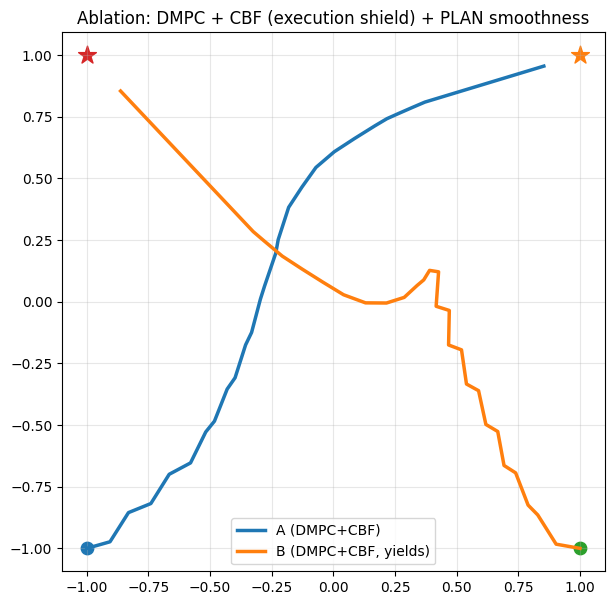

In [48]:
# ===============================================================
# ABLATION CELL 2 (FIXED): DMPC + CBF (execution shield)
# + PLAN-LEVEL SMOOTHNESS (no post-CBF EMA/turn-limit)
#
# Key idea:
#   - Add strong smoothness in the DMPC pick-best step:
#       (1) angle change penalty between v0 and prev_v
#       (2) dv penalty between v0 and prev_v
#   - Execution: ONLY CBF projection (no extra filtering after CBF)
# ===============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

if "cbf_project_velocity_world" not in globals():
    raise RuntimeError("cbf_project_velocity_world not found. Run your CBF cell first.")

# ---------- utils ----------
def wrap_pi(a: float) -> float:
    return float((a + np.pi) % (2*np.pi) - np.pi)

def straight_pred(x, g, dt, v_max, s, H):
    x = np.asarray(x, dtype=np.float64).reshape(2).copy()
    g = np.asarray(g, dtype=np.float64).reshape(2).copy()
    d = g - x
    d = d / (np.linalg.norm(d) + 1e-9)
    traj = [x.copy()]
    for _ in range(int(H)):
        x = x + float(dt) * float(v_max) * float(s) * d
        traj.append(x.copy())
    return np.asarray(traj, dtype=np.float64)

def cbf_step_other_center(
    x_now, v_nom, other_now,
    *,
    agent_safe_radius=0.60,
    gamma_min=6.0,
    w_p=6.0,
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
    extra_margin=0.0,
):
    x_now = np.asarray(x_now, dtype=np.float64).reshape(2)
    v_nom = np.asarray(v_nom, dtype=np.float64).reshape(2)
    other_now = np.asarray(other_now, dtype=np.float64).reshape(2)

    ellipses = [{"center": other_now.copy(), "radius": float(agent_safe_radius)}]
    x_traj = torch.tensor(x_now, dtype=torch.float32).view(1, 2, 1)
    v_traj = torch.tensor(v_nom, dtype=torch.float32).view(1, 2, 1)

    v_safe = cbf_project_velocity_world(
        x_traj,
        v_traj,
        ellipses=ellipses,
        extra_margin=float(extra_margin),
        max_corr_norm=float(max_corr_norm),
        passes=3,
        other_agents_traj=None,
        agent_safe_radius=float(agent_safe_radius),
        gamma_min=float(gamma_min),
        w_p=float(w_p),
        press_k=float(press_k),
        press_n=float(press_n),
    )
    return v_safe[0, :, 0].detach().cpu().numpy().astype(np.float64)

def _hinge(z): 
    return max(0.0, float(z))

def _angle_between(u, v):
    nu = float(np.linalg.norm(u) + 1e-12)
    nv = float(np.linalg.norm(v) + 1e-12)
    uu = u / nu
    vv = v / nv
    c = float(np.clip(np.dot(uu, vv), -1.0, 1.0))
    return float(np.arccos(c))  # [0,pi]

def rollout_pred(x0, v0, dt, H):
    x = np.asarray(x0, dtype=np.float64).reshape(2).copy()
    traj = [x.copy()]
    for _ in range(int(H)):
        x = x + float(dt) * v0
        traj.append(x.copy())
    return np.asarray(traj, dtype=np.float64)

# ---------- smooth DMPC pick-best (single-step action candidates) ----------
def dmcp_pick_best_action_smooth(
    xSelf, gSelf, other_pred,
    *,
    dt, H, v_max,
    speed_scales,
    heading_span_deg=140.0,
    heading_samples=25,
    d_safe=1.05,
    w_goal=35.0,
    w_dist=100.0,
    w_speed=0.3,
    # NEW smoothness
    prev_v=None,
    w_dv=6.0,          # dv penalty (stronger => less jitter)
    w_dtheta=12.0,     # angle change penalty (very effective)
):
    xSelf = np.asarray(xSelf, dtype=np.float64).reshape(2)
    gSelf = np.asarray(gSelf, dtype=np.float64).reshape(2)
    other_pred = np.asarray(other_pred, dtype=np.float64)

    base = float(np.arctan2((gSelf-xSelf)[1], (gSelf-xSelf)[0]))
    span = np.deg2rad(float(heading_span_deg))
    offs = np.linspace(-span/2.0, span/2.0, int(heading_samples))

    bestJ = 1e18
    bestv0 = np.zeros(2, dtype=np.float64)

    for off in offs:
        th = float(base + off)
        dir_vec = np.array([np.cos(th), np.sin(th)], dtype=np.float64)
        for s in speed_scales:
            v0 = float(v_max) * float(s) * dir_vec

            # rollout with constant v0
            x = xSelf.copy()
            J = 0.0
            for k in range(int(H)):
                x = x + float(dt) * v0

                d = float(np.linalg.norm(x - other_pred[k+1]))
                viol = _hinge(float(d_safe) - d)
                J += float(w_dist) * (viol*viol)

            # terminal goal cost
            J += float(w_goal) * float(np.sum((x - gSelf)**2))

            # speed choice penalty
            J += float(w_speed) * float((1.0 - float(s))**2)

            # smoothness vs prev_v
            if prev_v is not None:
                dv = v0 - prev_v
                J += float(w_dv) * float(dv @ dv)
                J += float(w_dtheta) * (_angle_between(v0, prev_v)**2)

            if J < bestJ:
                bestJ = J
                bestv0 = v0.copy()

    pred_self = rollout_pred(xSelf, bestv0, dt, H)  # for the other agent
    return bestv0, pred_self

# ---------- main loop ----------
def two_car_dmpc_with_cbf(
    xA0, gA, xB0, gB,
    *,
    dt=0.1,
    H=15,
    vA_max=1.4,
    vB_max=1.4,
    max_steps=600,
    goal_tol=0.20,
    speed_scales_A=(0.4, 0.7, 1.0),
    speed_scales_B=(0.0, 0.4, 0.7, 1.0),
    heading_span_deg=140.0,
    heading_samples=25,
    d_safe=1.05,
    w_goal_A=35.0, w_goal_B=35.0,
    w_dist_A=80.0, w_dist_B=120.0,
    w_speed_A=0.2, w_speed_B=0.4,
    n_best_response_iters=1,
    # NEW smoothness
    w_dv_A=6.0, w_dtheta_A=12.0,
    w_dv_B=6.0, w_dtheta_B=12.0,
    # CBF params
    agent_safe_radius=0.60,
    gamma_min=6.0,
    w_p=6.0,
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
):
    xA = np.asarray(xA0, dtype=np.float64).reshape(2).copy()
    xB = np.asarray(xB0, dtype=np.float64).reshape(2).copy()
    gA = np.asarray(gA, dtype=np.float64).reshape(2)
    gB = np.asarray(gB, dtype=np.float64).reshape(2)

    xsA, xsB = [xA.copy()], [xB.copy()]
    prev_vA, prev_vB = None, None

    predA = straight_pred(xA, gA, dt, vA_max, speed_scales_A[-1], H)
    predB = straight_pred(xB, gB, dt, vB_max, speed_scales_B[-1], H)

    for step in range(int(max_steps)):
        doneA = float(np.linalg.norm(xA - gA)) < float(goal_tol)
        doneB = float(np.linalg.norm(xB - gB)) < float(goal_tol)
        if doneA and doneB:
            break

        predA_shift = np.vstack([predA[1:], predA[-1]])
        predB_shift = np.vstack([predB[1:], predB[-1]])

        vA0 = np.zeros(2, dtype=np.float64)
        vB0 = np.zeros(2, dtype=np.float64)

        for _ in range(int(max(1, n_best_response_iters))):
            if not doneA:
                vA0, predA = dmcp_pick_best_action_smooth(
                    xA, gA, predB_shift,
                    dt=dt, H=H, v_max=vA_max,
                    speed_scales=speed_scales_A,
                    heading_span_deg=heading_span_deg,
                    heading_samples=heading_samples,
                    d_safe=d_safe,
                    w_goal=w_goal_A, w_dist=w_dist_A, w_speed=w_speed_A,
                    prev_v=prev_vA,
                    w_dv=w_dv_A, w_dtheta=w_dtheta_A,
                )
            if not doneB:
                vB0, predB = dmcp_pick_best_action_smooth(
                    xB, gB, predA_shift,
                    dt=dt, H=H, v_max=vB_max,
                    speed_scales=speed_scales_B,
                    heading_span_deg=heading_span_deg,
                    heading_samples=heading_samples,
                    d_safe=d_safe,
                    w_goal=w_goal_B, w_dist=w_dist_B, w_speed=w_speed_B,
                    prev_v=prev_vB,
                    w_dv=w_dv_B, w_dtheta=w_dtheta_B,
                )

        if doneA: vA0[:] = 0.0
        if doneB: vB0[:] = 0.0

        # ---- execute ONLY through CBF (no post-filter) ----
        vA_exec = cbf_step_other_center(
            xA, vA0, xB,
            agent_safe_radius=agent_safe_radius,
            gamma_min=gamma_min, w_p=w_p,
            press_k=press_k, press_n=press_n,
            max_corr_norm=max_corr_norm,
        )
        vB_exec = cbf_step_other_center(
            xB, vB0, xA,
            agent_safe_radius=agent_safe_radius,
            gamma_min=gamma_min, w_p=w_p,
            press_k=press_k, press_n=press_n,
            max_corr_norm=max_corr_norm,
        )

        xA = xA + float(dt) * vA_exec
        xB = xB + float(dt) * vB_exec
        xsA.append(xA.copy()); xsB.append(xB.copy())

        prev_vA, prev_vB = vA0.copy(), vB0.copy()

    return np.asarray(xsA), np.asarray(xsB)

# -------------------------
# Run + Plot (same scenario)
# -------------------------
xA0 = np.array([-1.0, -1.0], dtype=np.float64)
gA  = np.array([+1.0, +1.0], dtype=np.float64)
xB0 = np.array([+1.0, -1.0], dtype=np.float64)
gB  = np.array([-1.0, +1.0], dtype=np.float64)

xsA_cbf, xsB_cbf = two_car_dmpc_with_cbf(
    xA0, gA, xB0, gB,
    dt=0.1,
    H=15,
    vA_max=1.4, vB_max=1.4,
    goal_tol=0.20,
    n_best_response_iters=1,
    agent_safe_radius=0.60,
    # ⭐如果还尖，继续加大：
    # w_dtheta_A=20, w_dtheta_B=20,
    # w_dv_A=10, w_dv_B=10,
)

plt.figure(figsize=(7,7))
plt.plot(xsA_cbf[:,0], xsA_cbf[:,1], lw=2.5, label="A (DMPC+CBF)")
plt.plot(xsB_cbf[:,0], xsB_cbf[:,1], lw=2.5, label="B (DMPC+CBF, yields)")
plt.scatter([xA0[0]],[xA0[1]], s=80)
plt.scatter([gA[0]],[gA[1]], marker="*", s=180)
plt.scatter([xB0[0]],[xB0[1]], s=80)
plt.scatter([gB[0]],[gB[1]], marker="*", s=180)
plt.axis("equal"); plt.grid(alpha=0.3)
plt.legend()
plt.title("Ablation: DMPC + CBF (execution shield) + PLAN smoothness")
plt.show()


In [7]:
# ===============================================================
# VERIFY CELL — confirm your import chain is clean (module vs function)
# For 2carexperiment.ipynb
# - prints: repo root, sys.path status
# - imports sampler + cbf as MODULES
# - verifies: __file__, callable, and sampler's resolver target
# ===============================================================

import sys
from pathlib import Path
import importlib
import types

# -----------------------
# 0) locate repo root (the folder that contains "dmpc_fm_cbf/")
# -----------------------
def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for _ in range(15):
        if (p / "dmpc_fm_cbf").exists():
            return p
        p = p.parent
    return start.resolve()

CWD = Path.cwd().resolve()
REPO_ROOT = find_repo_root(CWD)
print("[CWD      ]", CWD)
print("[REPO_ROOT ]", REPO_ROOT)

# ensure REPO_ROOT in sys.path so `import dmpc_fm_cbf...` works
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print("[sys.path0]", sys.path[0])

# -----------------------
# 1) hard clean possible name collisions in notebook namespace
#    (common mistake: cbfmod = cbf_project_velocity_sgfm function)
# -----------------------
for name in ["cbfmod", "cbf_mod", "sampler_5h", "sampler_mod"]:
    if name in globals():
        print(f"[cleanup ] deleting globals()['{name}'] (was {type(globals()[name])})")
        del globals()[name]

# also remove from sys.modules if they were loaded under a bad alias
for modname in [
    "dmpc_fm_cbf.cbf_project_velocity_sgfm",
    "dmpc_fm_cbf.sampler_5h",
]:
    if modname in sys.modules:
        print(f"[cleanup ] deleting sys.modules['{modname}']")
        del sys.modules[modname]

# -----------------------
# 2) import as MODULES (the safe way)
# -----------------------
import dmpc_fm_cbf.sampler_5h as sampler_mod
import dmpc_fm_cbf.cbf_project_velocity_sgfm as cbf_mod

# optional reload (safe now, because they are in sys.modules correctly)
sampler_mod = importlib.reload(sampler_mod)
cbf_mod     = importlib.reload(cbf_mod)

print("[OK sampler file]", sampler_mod.__file__)
print("[OK cbf file    ]", cbf_mod.__file__)

# -----------------------
# 3) verify types + required symbols
# -----------------------
assert isinstance(sampler_mod, types.ModuleType), "sampler_mod is not a module (namespace collision?)"
assert isinstance(cbf_mod, types.ModuleType), "cbf_mod is not a module (namespace collision?)"

need_sampler = ["piecewise_sample_fm_5ch_with_cbf", "split_and_denormalize_5ch", "_resolve_cbf_projector"]
for k in need_sampler:
    assert hasattr(sampler_mod, k), f"sampler_5h.py missing attribute: {k}"

assert hasattr(cbf_mod, "cbf_project_velocity_sgfm"), "cbf_project_velocity_sgfm.py missing cbf_project_velocity_sgfm"
assert callable(cbf_mod.cbf_project_velocity_sgfm), "cbf_project_velocity_sgfm exists but is not callable"

print("[OK] sampler exports:",
      "piecewise_sample_fm_5ch_with_cbf =", callable(sampler_mod.piecewise_sample_fm_5ch_with_cbf),
      "| split_and_denormalize_5ch =", callable(sampler_mod.split_and_denormalize_5ch))

print("[OK] cbf fn:", cbf_mod.cbf_project_velocity_sgfm)

# -----------------------
# 4) check sampler's resolver returns callable
# -----------------------
try:
    fn = sampler_mod._resolve_cbf_projector()
    print("[OK] sampler _resolve_cbf_projector() ->", fn)
    print("     callable?", callable(fn))
except Exception as e:
    print("[WARN] sampler _resolve_cbf_projector() raised:", repr(e))

print("✅ Import chain verified. If you see module files above, you're clean.")


[CWD      ] D:\projects\lab2025\dmpc_fm_cbf\notebooks
[REPO_ROOT ] D:\projects\lab2025\dmpc_fm_cbf
[sys.path0] D:\projects\lab2025\dmpc_fm_cbf
[cleanup ] deleting globals()['cbf_mod'] (was <class 'function'>)
[cleanup ] deleting globals()['sampler_mod'] (was <class 'module'>)
[cleanup ] deleting sys.modules['dmpc_fm_cbf.cbf_project_velocity_sgfm']
[cleanup ] deleting sys.modules['dmpc_fm_cbf.sampler_5h']
[OK sampler file] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[OK cbf file    ] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\cbf_project_velocity_sgfm.py
[OK] sampler exports: piecewise_sample_fm_5ch_with_cbf = True | split_and_denormalize_5ch = True
[OK] cbf fn: <function cbf_project_velocity_sgfm at 0x000001D079509C60>
[OK] sampler _resolve_cbf_projector() -> <function cbf_project_velocity_sgfm at 0x000001D079509C60>
     callable? True
✅ Import chain verified. If you see module files above, you're clean.


In [8]:
import sys, importlib.util
from pathlib import Path

def find_file_upwards(filename: str, start: Path, max_up: int = 12):
    """
    Search 'filename' by walking upwards; at each level, also try a few common subpaths.
    Returns Path or None.
    """
    p = start.resolve()

    common_subs = [
        Path("."),  # current
        Path("dmpc_fm_cbf"),
        Path("dmpc_fm_cbf") / "dmpc_fm_cbf",
        Path("src"),
        Path("src") / "dmpc_fm_cbf",
    ]

    for _ in range(max_up):
        # quick checks on common layouts
        for sub in common_subs:
            cand = (p / sub / filename).resolve()
            if cand.exists():
                return cand

        # fallback: shallow recursive search (limited)
        try:
            hits = list(p.rglob(filename))
            if len(hits) > 0:
                # prefer the one inside ".../dmpc_fm_cbf/..." if multiple
                hits_sorted = sorted(hits, key=lambda x: ("dmpc_fm_cbf" not in str(x), len(str(x))))
                return hits_sorted[0].resolve()
        except Exception:
            pass

        p = p.parent

    return None

def load_module_from_abs_path(mod_name: str, abs_path: Path):
    abs_path = abs_path.resolve()
    assert abs_path.exists(), f"Missing file: {abs_path}"
    spec = importlib.util.spec_from_file_location(mod_name, str(abs_path))
    mod = importlib.util.module_from_spec(spec)
    sys.modules[mod_name] = mod
    spec.loader.exec_module(mod)  # type: ignore
    return mod

# ---- locate files robustly ----
here = Path.cwd()
sampler_path = find_file_upwards("sampler_5h.py", here)
cbf_path     = find_file_upwards("cbf_project_velocity_sgfm.py", here)

print("[cwd]", here.resolve())
print("[sampler_path]", sampler_path)
print("[cbf_path    ]", cbf_path)

assert sampler_path is not None, "Cannot find sampler_5h.py from current notebook location."
assert cbf_path is not None, "Cannot find cbf_project_velocity_sgfm.py from current notebook location."

sampler_mod = load_module_from_abs_path("sampler_5h_abs", sampler_path)
cbf_mod     = load_module_from_abs_path("cbf_sgfm_abs",  cbf_path)

piecewise_sample_fm_5ch_with_cbf = sampler_mod.piecewise_sample_fm_5ch_with_cbf

print("[USING sampler]", sampler_mod.__file__)
print("[USING cbf    ]", cbf_mod.__file__)


[cwd] D:\projects\lab2025\dmpc_fm_cbf\notebooks
[sampler_path] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[cbf_path    ] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\cbf_project_velocity_sgfm.py
[USING sampler] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[USING cbf    ] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\cbf_project_velocity_sgfm.py


In [9]:
# Force-reload sampler_5h with cond-support, then rebind global function
import inspect
import importlib
import dmpc_fm_cbf.sampler_5h as sampler_mod

sampler_mod = importlib.reload(sampler_mod)
piecewise_sample_fm_5ch_with_cbf = sampler_mod.piecewise_sample_fm_5ch_with_cbf

sig = inspect.signature(piecewise_sample_fm_5ch_with_cbf)
print("[sampler file]", sampler_mod.__file__)
print("[sampler sig ]", sig)

required = ["cond", "start_xy_norm", "goal_xy_norm", "goal_guidance_weight", "lock_start"]
missing = [k for k in required if k not in sig.parameters]
assert len(missing) == 0, f"Loaded sampler still missing params: {missing}"

print("✅ sampler function rebound with cond/start-goal guidance support")


[sampler file] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[sampler sig ] (*, model_5ch, T_steps: 'int', device: 'str' = 'cuda', total_time: 'float' = 1.0, num_segments: 'int' = 20, ode_method: 'str' = 'dopri5', atol: 'float' = 1e-05, rtol: 'float' = 1e-05, noise_scale: 'float' = 1.0, x0_noise: 'torch.Tensor | None' = None, cond=None, start_xy=None, start_xy_norm=None, start_guidance_weight: 'float' = 0.0, lock_start: 'bool' = False, goal_xy=None, goal_xy_norm=None, goal_guidance_weight: 'float' = 0.0, goal_guidance_mode: 'str' = 'endpoint', use_cbf: 'bool' = True, scaler=None, ellipses=None, tau0_hf: 'float' = 0.7, p_hf: 'float' = 2.0, lf_on: 'float' = 1.0, hf_max: 'float' = 1.0, cbf_kwargs: 'dict | None' = None)
✅ sampler function rebound with cond/start-goal guidance support


In [10]:
# ===============================================================
# 1) Load model_5ch automatically (5-channel FM model)
# ===============================================================

if "model_5ch" not in globals():

    # try to find checkpoint automatically
    ckpt_candidates = list(Path.cwd().rglob("model_vel_5ch*.pt"))
    if len(ckpt_candidates) == 0:
        raise RuntimeError("Cannot find 5ch checkpoint (model_vel_5ch*.pt)")
    
    ckpt_path = ckpt_candidates[0]
    print("[Found checkpoint]", ckpt_path)

    # ensure repo root in sys.path
    repo_root = sampler_path.parents[2]
    if str(repo_root) not in sys.path:
        sys.path.insert(0, str(repo_root))

    from fmtorch.models.simple1d_unet import SimpleUNet1D

    model_5ch = SimpleUNet1D(
        time_emb_dim=128,
        hidden_dim=128,
        cond_dim=5,
        in_channels=5,
        out_channels=5,
    ).to(device)

    ckpt = torch.load(str(ckpt_path), map_location=device)

    if "model_state_dict" in ckpt:
        model_5ch.load_state_dict(ckpt["model_state_dict"])
    else:
        model_5ch.load_state_dict(ckpt)

    model_5ch.eval()
    print("✅ model_5ch loaded successfully.")


[Found checkpoint] d:\projects\lab2025\dmpc_fm_cbf\notebooks\cache\model_vel_5ch_canonical_r.pt
✅ model_5ch loaded successfully.


[device] cuda
[USING sampler] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[done] step 75
[stats] FM calls=45 | proposal-CBF used=38


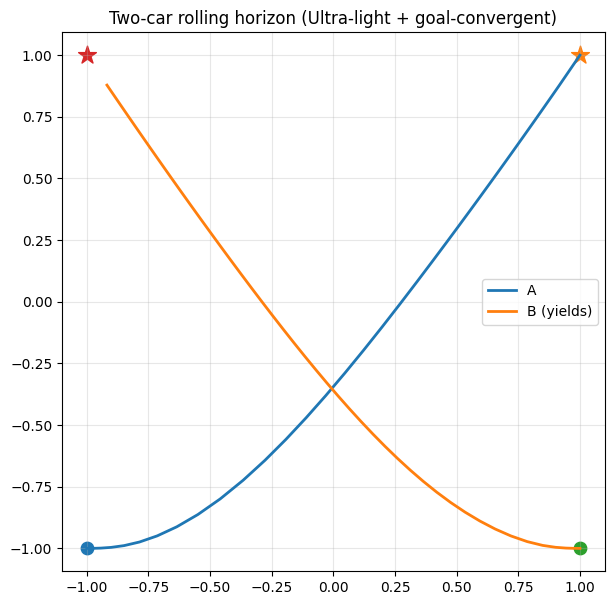

[A final] pos [1. 1.] dist 0.0
[B final] pos [-0.9180957  0.878699 ] dist 0.14636339247226715


In [ ]:
# ===============================================================
# TWO-CAR Rolling Horizon (ULTRA-LIGHT + GOAL-CONVERGENT) — FULL CELL
# - Far: FM only (no proposal CBF)
# - Mid: light proposal CBF
# - Near: strong proposal CBF
# - Adaptive replan cadence (far slow, near fast)
# - Execute u0 = [a0, delta_rate0] from FM 5ch tokens (ch3,ch4 at token0)
# - Bicycle dynamics in WORLD: state=[x,y,theta,v,delta]
# - NO execution-layer CBF (only proposal CBF inside sampler)
#
# KEY FIXES (stop "circles"):
#   (1) Mix FM controls with Pure-Pursuit tracking (stabilizes heading)
#   (2) Scale FM control (important if you forgot denorm)
#   (3) Stuck detector: if not approaching goal -> increase tracking weight
#   (4) Near-goal: strong brake + reduce turning authority
# ===============================================================

import sys, math
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("[device]", device)

# ===============================================================
# 0) Robust sampler loader (pick nearest sampler_5h.py)
# ===============================================================
def find_nearest_file(filename: str, start: Path, max_up=12):
    start = start.resolve()
    candidates = []
    p = start
    for _ in range(max_up):
        candidates += list(p.rglob(filename))
        p = p.parent
    if not candidates:
        raise FileNotFoundError(f"{filename} not found from {start}")
    # choose shortest string path as "nearest"
    candidates = sorted(candidates, key=lambda x: len(str(x)))
    return candidates[0]

sampler_path = find_nearest_file("sampler_5h.py", Path.cwd())
print("[USING sampler]", sampler_path)

import importlib.util
spec = importlib.util.spec_from_file_location("sampler_mod", sampler_path)
sampler_mod = importlib.util.module_from_spec(spec)
sys.modules["sampler_mod"] = sampler_mod
spec.loader.exec_module(sampler_mod)

piecewise_sample_fm_5ch_with_cbf = sampler_mod.piecewise_sample_fm_5ch_with_cbf

# ===============================================================
# 1) Model must already be loaded
# ===============================================================
if "model_5ch" not in globals():
    raise RuntimeError("model_5ch must be loaded before this cell (load ckpt in previous cell).")
model_5ch = model_5ch.to(device).eval()

# ===============================================================
# 2) Hyperparams (FAST + stable)
# ===============================================================
dt_exec = 0.10

T_steps      = 30          # 🔥 faster
num_segments = 4           # 🔥 faster
total_time   = 1.0

MAX_STEPS = 260
goal_tol  = 0.15

# adaptive replan
REPLAN_FAR  = 10
REPLAN_MID  = 5
REPLAN_NEAR = 1

# vehicle
L = 0.35
v_max_A = 1.2
v_max_B = 0.7
v_floor = 0.06

delta_max = np.deg2rad(30.0)
a_max     = 1.2            # 🔥 smaller accel
r_max     = np.deg2rad(55) # 🔥 smaller steer-rate

ema_beta_u = 0.90

# IMPORTANT: FM control scaling (if controls are normalized, this saves you)
FM_A_SCALE = 0.25
FM_R_SCALE = 0.20

# ===============================================================
# 3) Adaptive distance thresholds for proposal CBF
# ===============================================================
SAFE_DIST_FAR  = 1.6
SAFE_DIST_NEAR = 0.9

BASE_CBF = dict(
    MASK_GATE=1.0,
    SUPPRESS_FRAC=0.0,
    RAMP_FRAC=0.10,
    max_corr_norm=3.0,
)

CBF_LIGHT  = dict(passes=1, extra_margin=0.05, alpha=8.0)
CBF_STRONG = dict(passes=5, extra_margin=0.12, alpha=18.0)

# ===============================================================
# 4) Canonical transform (world->canonical for other agent + goal)
# ===============================================================
def build_can_tf(x0, g):
    x0 = np.asarray(x0, np.float32).reshape(2)
    g  = np.asarray(g,  np.float32).reshape(2)
    gvec = g - x0
    dist = float(np.linalg.norm(gvec) + 1e-9)

    ex = (gvec / dist).reshape(2,1)
    ey = np.array([[-ex[1,0]],[ex[0,0]]], np.float32)
    R_cw = np.concatenate([ex, ey], axis=1)
    R_wc = R_cw.T

    def world_to_can(xy):
        xy = np.asarray(xy, np.float32).reshape(-1,2)
        return ((R_wc @ (xy - x0).T).T).astype(np.float32)

    start_can = np.array([0.0, 0.0], np.float32)
    goal_can  = np.array([dist, 0.0], np.float32)
    return world_to_can, start_can, goal_can

# ===============================================================
# 5) Noise init
# ===============================================================
def make_x0_noise_can(T, seed):
    g = torch.Generator(device=device)
    g.manual_seed(int(seed))
    x0 = torch.randn((1,5,T), device=device, generator=g) * 0.02
    x0[:,:,0] = 0.0
    return x0

# ===============================================================
# 6) Extract u0=[a0, r0] from FM tokens (and scale)
# ===============================================================
def extract_u0(x_can):
    a0 = float(x_can[3,0]) * FM_A_SCALE
    r0 = float(x_can[4,0]) * FM_R_SCALE
    a0 = float(np.clip(a0, -a_max, a_max))
    r0 = float(np.clip(r0, -r_max, r_max))
    return np.array([a0, r0], np.float32)

# ===============================================================
# 7) Bicycle dynamics
# ===============================================================
def wrap_pi(th):
    return (th + np.pi)%(2*np.pi)-np.pi

def bicycle_step(state, u, v_max):
    x,y,th,v,delta = state
    a,r = float(u[0]), float(u[1])

    v2 = float(np.clip(v + dt_exec*a, 0.0, v_max))
    if v2 < v_floor and abs(a) > 1e-4:
        v2 = v_floor

    delta2 = float(np.clip(delta + dt_exec*r, -delta_max, delta_max))

    th2 = float(wrap_pi(th + dt_exec*(v2/L)*math.tan(delta2)))
    x2  = float(x + dt_exec*v2*math.cos(th2))
    y2  = float(y + dt_exec*v2*math.sin(th2))
    return np.array([x2,y2,th2,v2,delta2], np.float32)

# ===============================================================
# 8) Pure-Pursuit tracking delta_des, and mix FM with tracking
# ===============================================================
def pure_pursuit_delta_des(state, goal, lookahead=0.9):
    x,y,th,v,delta = state
    gx,gy = float(goal[0]), float(goal[1])
    dx,dy = gx-x, gy-y
    d = float(math.hypot(dx,dy) + 1e-9)
    Ld = float(np.clip(d, 0.35, lookahead))
    alpha = wrap_pi(math.atan2(dy,dx) - th)
    kappa = 2.0 * math.sin(alpha) / max(1e-6, Ld)
    delta_des = math.atan(L * kappa)
    return float(np.clip(delta_des, -delta_max, delta_max))

def mix_fm_with_tracking(u_fm, state, goal, *, w_track):
    # tracking r makes delta -> delta_des
    delta_des = pure_pursuit_delta_des(state, goal, lookahead=0.9)
    r_track = (delta_des - float(state[4])) / dt_exec
    r_track = float(np.clip(r_track, -r_max, r_max))

    # tracking accel: set v_des proportional to distance
    d = float(np.linalg.norm(np.asarray(goal, np.float32) - np.asarray(state[:2], np.float32)))
    v_des = float(np.clip(0.9*d, 0.0, v_max_A))
    a_track = (v_des - float(state[3])) / dt_exec
    a_track = float(np.clip(a_track, -a_max, a_max))

    a = (1.0-w_track)*float(u_fm[0]) + w_track*a_track
    r = (1.0-w_track)*float(u_fm[1]) + w_track*r_track

    # near goal: brake + reduce turning
    if d < 0.45:
        a = min(a, -0.8)
        r *= 0.5

    return np.array([np.clip(a, -a_max, a_max), np.clip(r, -r_max, r_max)], np.float32)

# ===============================================================
# 9) Adaptive FM planner (proposal-level CBF only)
# ===============================================================
def fm_plan_one_step(state, goal, other_xy, seed, dist_AB):
    x_self = state[:2]
    world_to_can, start_can, goal_can = build_can_tf(x_self, goal)

    other_can = world_to_can(np.asarray(other_xy, np.float32).reshape(1,2))[0]
    ellipses = [{"center": other_can, "radius":0.45}]

    x0_noise = make_x0_noise_can(T_steps, seed)
    cond_vec = np.array([1,0,1,0,0], np.float32)

    if dist_AB > SAFE_DIST_FAR:
        use_cbf = False
        cbf_kwargs = None
    elif dist_AB > SAFE_DIST_NEAR:
        use_cbf = True
        cbf_kwargs = {**BASE_CBF, **CBF_LIGHT}
    else:
        use_cbf = True
        cbf_kwargs = {**BASE_CBF, **CBF_STRONG}

    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch,
        T_steps=T_steps,
        device=str(device),
        total_time=total_time,
        num_segments=num_segments,
        ode_method="euler",
        atol=1e-5,
        rtol=1e-5,
        x0_noise=x0_noise,
        cond=cond_vec,
        start_xy_norm=start_can,
        goal_xy_norm=goal_can,
        ellipses=ellipses,
        cbf_kwargs=cbf_kwargs,
        use_cbf=use_cbf,

        goal_guidance_weight=0.65,
        goal_guidance_mode="tail",
    )

    return extract_u0(x_can), use_cbf

# ===============================================================
# 10) Rolling horizon helpers
# ===============================================================
def ema(u_new, u_prev):
    if u_prev is None:
        return u_new
    return (ema_beta_u*u_prev + (1-ema_beta_u)*u_new).astype(np.float32)

def choose_replan_every(dist_AB):
    if dist_AB > SAFE_DIST_FAR:
        return REPLAN_FAR
    elif dist_AB > SAFE_DIST_NEAR:
        return REPLAN_MID
    else:
        return REPLAN_NEAR

# ===============================================================
# 11) Run scenario
# ===============================================================
xA0 = np.array([-1,-1],np.float32); gA = np.array([ 1, 1],np.float32)
xB0 = np.array([ 1,-1],np.float32); gB = np.array([-1, 1],np.float32)

sA = np.array([xA0[0],xA0[1],0.0,   0.0,0.0], np.float32)
sB = np.array([xB0[0],xB0[1],math.pi,0.0,0.0], np.float32)

trajA=[sA.copy()]
trajB=[sB.copy()]

prev_uA=None
prev_uB=None
uA_cached = np.zeros(2, np.float32)
uB_cached = np.zeros(2, np.float32)

cbf_used_count = 0
fm_call_count  = 0

# "stuck" detector
last_dA = float(np.linalg.norm(sA[:2]-gA))
last_dB = float(np.linalg.norm(sB[:2]-gB))
stuckA = 0
stuckB = 0

for step in range(MAX_STEPS):
    dA = float(np.linalg.norm(sA[:2]-gA))
    dB = float(np.linalg.norm(sB[:2]-gB))
    doneA = (dA < goal_tol)
    doneB = (dB < goal_tol)
    if doneA and doneB:
        print("[done] step", step)
        break

    dist_AB = float(np.linalg.norm(sA[:2] - sB[:2]))
    REPLAN_EVERY = choose_replan_every(dist_AB)

    if step % REPLAN_EVERY == 0:
        if not doneA:
            uA_cached, use_cbf_A = fm_plan_one_step(sA, gA, sB[:2], 1000+step, dist_AB)
            fm_call_count += 1
            cbf_used_count += int(use_cbf_A)
        else:
            uA_cached = np.zeros(2, np.float32)

        if not doneB:
            uB_cached, use_cbf_B = fm_plan_one_step(sB, gB, sA[:2], 2000+step, dist_AB)
            fm_call_count += 1
            cbf_used_count += int(use_cbf_B)
        else:
            uB_cached = np.zeros(2, np.float32)

    # EMA
    uA_fm = ema(uA_cached, prev_uA)
    uB_fm = ema(uB_cached, prev_uB)

    # stuck update (if not approaching goal)
    stuckA = stuckA + 1 if dA > last_dA - 1e-3 else 0
    stuckB = stuckB + 1 if dB > last_dB - 1e-3 else 0
    last_dA, last_dB = dA, dB

    # tracking weight: default 0.70, if stuck -> 0.90 (force convergence)
    wA = 0.70 if stuckA < 8 else 0.90
    wB = 0.70 if stuckB < 8 else 0.90

    uA = mix_fm_with_tracking(uA_fm, sA, gA, w_track=wA)
    uB = mix_fm_with_tracking(uB_fm, sB, gB, w_track=wB)

    # execute
    if not doneA:
        sA = bicycle_step(sA, uA, v_max_A)
    else:
        sA[:2] = gA

    if not doneB:
        sB = bicycle_step(sB, uB, v_max_B)
    else:
        sB[:2] = gB

    trajA.append(sA.copy())
    trajB.append(sB.copy())
    prev_uA = uA.copy()
    prev_uB = uB.copy()

trajA = np.array(trajA)
trajB = np.array(trajB)

print(f"[stats] FM calls={fm_call_count} | proposal-CBF used={cbf_used_count}")

# ===============================================================
# 12) Plot
# ===============================================================
plt.figure(figsize=(7,7))
plt.plot(trajA[:,0],trajA[:,1],lw=2,label="A")
plt.plot(trajB[:,0],trajB[:,1],lw=2,label="B (yields)")
plt.scatter([xA0[0]],[xA0[1]],s=80)
plt.scatter([gA[0]],[gA[1]],marker="*",s=180)
plt.scatter([xB0[0]],[xB0[1]],s=80)
plt.scatter([gB[0]],[gB[1]],marker="*",s=180)
plt.axis("equal")
plt.grid(alpha=0.3)
plt.legend()
plt.title("Two-car rolling horizon (Ultra-light + goal-convergent)")
plt.show()

print("[A final] pos", trajA[-1,:2], "dist", float(np.linalg.norm(trajA[-1,:2]-gA)))
print("[B final] pos", trajB[-1,:2], "dist", float(np.linalg.norm(trajB[-1,:2]-gB)))


[device] cuda
[sampler] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[sampler sig] (*, model_5ch, T_steps: 'int', device: 'str' = 'cuda', total_time: 'float' = 1.0, num_segments: 'int' = 20, ode_method: 'str' = 'dopri5', atol: 'float' = 1e-05, rtol: 'float' = 1e-05, noise_scale: 'float' = 1.0, x0_noise: 'torch.Tensor | None' = None, cond=None, start_xy=None, start_xy_norm=None, start_guidance_weight: 'float' = 0.0, lock_start: 'bool' = False, goal_xy=None, goal_xy_norm=None, goal_guidance_weight: 'float' = 0.0, goal_guidance_mode: 'str' = 'endpoint', use_cbf: 'bool' = True, scaler=None, ellipses=None, tau0_hf: 'float' = 0.7, p_hf: 'float' = 2.0, lf_on: 'float' = 1.0, hf_max: 'float' = 1.0, cbf_kwargs: 'dict | None' = None)
[model] loaded
FM-MPC Simulation: Two-Agent Collision Avoidance
Agent A: [-1. -1.] -> [1. 1.], v_max=1.0
Agent B: [ 1. -1.] -> [-1.  1.], v_max=0.6
H=12, K=8, dt=0.1, T_steps=40
[step   0] dA=2.828 dB=2.828 dist_AB=2.000 uA=[+0.96,-0.24] uB=[+0.18,-0.23]

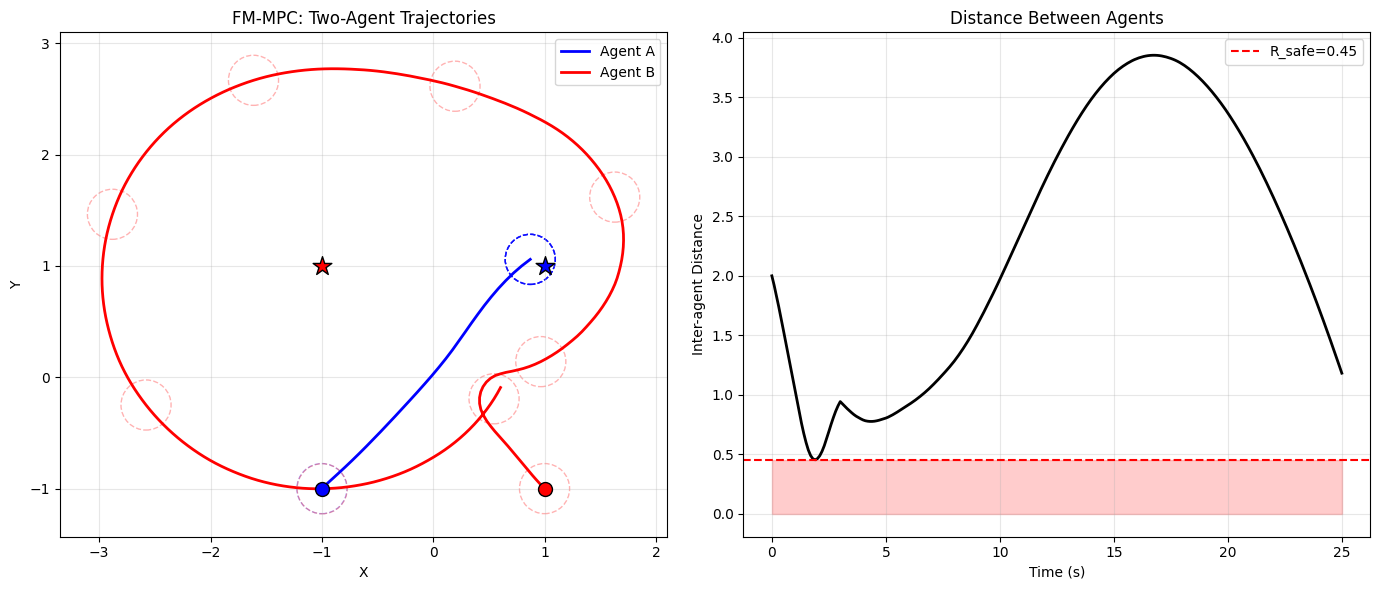

In [88]:
# ===============================================================
# FM-MPC: Two-Agent Collision Avoidance with Unicycle Dynamics
# 
# FM model outputs: [x, y, theta, a, delta_rate]
# - Channels 0,1: XY position (用于 path reference)
# - Channels 3,4: a (acceleration), delta_rate (转向率)
#
# 策略：
#   1. 每次 replan 调用 sampler_5h 生成新的轨迹
#   2. 用 FM 的 XY 轨迹做 path tracking -> unicycle controls
#   3. 只执行第一步 u0，下次 replan 重新采样
#   4. CBF 在 sampler 内部处理避障
# ===============================================================

import sys, math
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[device] {device}")

# ===============================================================
# 0) Load sampler_5h
# ===============================================================
# Prefer repo-local sampler; avoid accidentally loading D:\\projects\\sampler_5h.py
repo_sampler = (Path.cwd().parent / "dmpc_fm_cbf" / "sampler_5h.py").resolve()
if repo_sampler.exists():
    sampler_path = repo_sampler
else:
    def find_nearest_file(filename: str, start: Path, max_up=12):
        start = start.resolve()
        candidates = []
        p = start
        for _ in range(max_up):
            candidates += list(p.rglob(filename))
            p = p.parent
        if not candidates:
            raise FileNotFoundError(f"{filename} not found from {start}")
        return sorted(candidates, key=lambda x: len(str(x)))[0]
    sampler_path = find_nearest_file("sampler_5h.py", Path.cwd())

print(f"[sampler] {sampler_path}")

import importlib.util, inspect
spec = importlib.util.spec_from_file_location("sampler_5h", sampler_path)
sampler_mod = importlib.util.module_from_spec(spec)
sys.modules["sampler_5h"] = sampler_mod
spec.loader.exec_module(sampler_mod)

piecewise_sample_fm_5ch_with_cbf = sampler_mod.piecewise_sample_fm_5ch_with_cbf
sampler_sig = inspect.signature(piecewise_sample_fm_5ch_with_cbf)
print("[sampler sig]", sampler_sig)
assert "cond" in sampler_sig.parameters, "Loaded sampler has no cond; wrong sampler file loaded."

# ===============================================================
# 1) Model check - model_5ch 必须已经加载
# ===============================================================
if "model_5ch" not in dir():
    try:
        model_5ch = globals()["model_5ch"]
    except KeyError:
        raise RuntimeError("model_5ch must be loaded before running this cell!")

model_5ch = model_5ch.to(device).eval()
print("[model] loaded")

# ===============================================================
# 2) Parameters
# ===============================================================
# Execution
dt_exec = 0.10

# FM sampler
T_steps      = 40
num_segments = 10
total_time   = 1.0
ode_method   = "euler"
noise_scale  = 0.08

# MPC
H = 12              # horizon for tracking
K = 8               # candidates per replan
REPLAN_EVERY = 2
MAX_STEPS = 250
goal_tol = 0.15

# ===============================================================
# 3) Unicycle dynamics
# ===============================================================
v_max_A   = 1.0
v_max_B   = 0.6
v_min     = 0.0
v_floor   = 0.08
a_max     = 1.5
omega_max = np.deg2rad(120)

def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def unicycle_step(s, u, *, dt, v_max):
    """
    s = [x, y, theta, v]
    u = [a, omega]
    """
    x, y, th, v = s
    a   = float(np.clip(u[0], -a_max, a_max))
    omg = float(np.clip(u[1], -omega_max, omega_max))
    
    v2 = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.01:
        v2 = v_floor
    
    th2 = wrap_pi(th + dt * omg)
    x2  = x + dt * v2 * math.cos(th2)
    y2  = y + dt * v2 * math.sin(th2)
    
    return np.array([x2, y2, th2, v2], dtype=np.float32)

def rollout_unicycle(s0, U, *, dt, v_max):
    """Rollout controls U (H,2) from s0, return positions (H+1,2) and states (H+1,4)"""
    Hh = U.shape[0]
    states = np.zeros((Hh+1, 4), dtype=np.float32)
    states[0] = s0
    for i in range(Hh):
        states[i+1] = unicycle_step(states[i], U[i], dt=dt, v_max=v_max)
    return states[:, :2], states

# ===============================================================
# 4) Canonical frame (SE2)
# ===============================================================
def build_canonical_frame(start_xy, goal_xy):
    """
    Build SE2 transform: canonical frame has start at origin, goal on +x axis.
    Returns: world_to_can, can_to_world, start_can, goal_can, dist
    """
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy, np.float32).reshape(2)
    
    d = goal - start
    dist = float(np.linalg.norm(d) + 1e-9)
    
    cos_th = d[0] / dist
    sin_th = d[1] / dist
    
    # World -> Canonical rotation matrix
    R_wc = np.array([[cos_th, sin_th],
                     [-sin_th, cos_th]], dtype=np.float32)
    R_cw = R_wc.T  # Canonical -> World
    
    def world_to_can(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return ((xy - start) @ R_wc.T).astype(np.float32)
    
    def can_to_world(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return (xy @ R_cw.T + start).astype(np.float32)
    
    def world_to_can_angle(th_world):
        """Transform heading from world to canonical"""
        return wrap_pi(th_world - math.atan2(sin_th, cos_th))
    
    def can_to_world_angle(th_can):
        """Transform heading from canonical to world"""
        return wrap_pi(th_can + math.atan2(sin_th, cos_th))
    
    start_can = np.array([0.0, 0.0], np.float32)
    goal_can  = np.array([dist, 0.0], np.float32)
    
    return {
        'w2c': world_to_can,
        'c2w': can_to_world,
        'w2c_angle': world_to_can_angle,
        'c2w_angle': can_to_world_angle,
        'start_can': start_can,
        'goal_can': goal_can,
        'dist': dist,
        'R_wc': R_wc,
        'R_cw': R_cw,
    }

# ===============================================================
# 5) CBF settings
# ===============================================================
SAFE_DIST_FAR  = 2.0
SAFE_DIST_NEAR = 1.0

BASE_CBF = dict(MASK_GATE=1.0, SUPPRESS_FRAC=0.0, RAMP_FRAC=0.15, max_corr_norm=3.0)
CBF_LIGHT  = dict(passes=3, extra_margin=0.08, alpha=10.0)
CBF_STRONG = dict(passes=10, extra_margin=0.20, alpha=25.0)

def get_cbf_config(dist_AB):
    if dist_AB > SAFE_DIST_FAR:
        return False, None
    elif dist_AB > SAFE_DIST_NEAR:
        return True, {**BASE_CBF, **CBF_LIGHT}
    else:
        return True, {**BASE_CBF, **CBF_STRONG}

# ===============================================================
# 6) FM trajectory sampling
# ===============================================================
def make_x0_noise(T, seed):
    g = torch.Generator(device=device)
    g.manual_seed(int(seed))
    x0 = torch.randn((1, 5, T), device=device, generator=g) * noise_scale
    x0[:, :, 0] = 0.0  # anchor start point
    return x0

def sample_fm_trajectory(*, self_state, goal_xy, other_xy, seed):
    """
    Sample one FM trajectory.
    Returns: xy_world (T,2), theta_can (T,), used_cbf
    """
    self_xy = self_state[:2]
    
    # Build canonical frame
    tf = build_canonical_frame(self_xy, goal_xy)
    
    # Other agent in canonical frame
    other_can = tf['w2c'](other_xy.reshape(1, 2))[0]
    ellipses = [{"center": other_can.copy(), "radius": 0.55}]
    
    # CBF config based on distance
    dist_AB = float(np.linalg.norm(self_xy - other_xy))
    use_cbf, cbf_kwargs = get_cbf_config(dist_AB)
    
    # Initial noise
    x0_noise = make_x0_noise(T_steps, seed)
    
    # Conditioning vector (adjust based on your training)
    # cond_vec = np.array([1, 0, 1, 0, 0], dtype=np.float32)
    v0 = float(self_state[3])
    th_world = float(self_state[2])
    th_can = tf['w2c_angle'](th_world)
    delta0 = float(self_state[4]) if len(self_state) >= 5 else 0.0

    cond_vec = np.array([
        tf['dist'],
        v0,
        np.cos(th_can),
        np.sin(th_can),
        delta0,
    ], dtype=np.float32)
    
    # Sample
    x_can, states_norm, controls_norm = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch,
        T_steps=T_steps,
        device=str(device),
        total_time=total_time,
        num_segments=num_segments,
        ode_method=ode_method,
        atol=1e-4,
        rtol=1e-4,
        noise_scale=noise_scale,
        x0_noise=x0_noise,
        cond=cond_vec,
        start_xy_norm=tf['start_can'],
        goal_xy_norm=tf['goal_can'],
        start_guidance_weight=0.4,
        goal_guidance_weight=0.8,
        goal_guidance_mode="tail",
        lock_start=True,
        use_cbf=use_cbf,
        scaler=None,
        ellipses=ellipses,
        cbf_kwargs=cbf_kwargs,
    )
    
    # x_can: (5, T) -> extract XY path in canonical frame
    xy_can = x_can[0:2, :].T.astype(np.float32)  # (T, 2) x_can从fm sampler模型中来的
    theta_can = x_can[2, :].astype(np.float32)    # (T,)
    
    # Transform to world frame
    xy_world = tf['c2w'](xy_can)  # (T, 2)
    
    return xy_world, theta_can, use_cbf, tf

# ===============================================================
# 7) Path tracking -> Unicycle controls from pure pursuit
# ===============================================================
def path_to_controls(s0, path_xy, *, H, dt, v_max, 
                     lookahead_ratio=0.15, k_omega=3.0, k_accel=2.0):
    """
    Pure-pursuit style tracking: path (T,2) -> controls (H,2)
    """
    T_path = path_xy.shape[0]
    
    # Resample path to H+1 points uniformly
    if T_path >= H + 1:
        indices = np.linspace(0, T_path - 1, H + 1).astype(int)
        ref = path_xy[indices]
    else:
        ref = np.zeros((H + 1, 2), dtype=np.float32)
        ref[:T_path] = path_xy
        ref[T_path:] = path_xy[-1]
    
    s = s0.copy()
    U = np.zeros((H, 2), dtype=np.float32)
    
    for i in range(H):
        x, y, th, v = s
        
        # Lookahead target
        look_idx = min(i + 1 + int(lookahead_ratio * H), H)
        target = ref[look_idx]
        
        dx = target[0] - x
        dy = target[1] - y
        dist = math.hypot(dx, dy)
        
        # Desired heading
        th_des = math.atan2(dy, dx)
        e_th = wrap_pi(th_des - th)
        
        # Omega (proportional to heading error)
        omega = float(np.clip(k_omega * e_th, -omega_max, omega_max))
        
        # Desired speed
        v_des = min(k_accel * dist / dt, v_max)
        
        # Slow down when turning sharply
        turn_penalty = max(0.25, 1.0 - 0.7 * abs(e_th) / np.pi)
        v_des *= turn_penalty
        
        # Acceleration
        a = float(np.clip(k_accel * (v_des - v), -a_max, a_max))
        
        U[i] = np.array([a, omega], dtype=np.float32)
        s = unicycle_step(s, U[i], dt=dt, v_max=v_max)
    
    return U, ref

# ===============================================================
# 8) Cost function
# ===============================================================
R_SAFE = 0.45

W_GOAL_END  = 12.0
W_GOAL_PATH = 1.0
W_COLL      = 250.0
W_SMOOTH    = 0.2
W_SPEED     = 0.05

def compute_cost(pos_self, states_self, pos_other_pred, goal_xy, U, v_pref):
    """Evaluate trajectory cost"""
    # Goal distance
    d_end  = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path = float(np.mean(np.linalg.norm(pos_self - goal_xy, axis=1)))
    
    # Collision penalty
    d_inter = np.linalg.norm(pos_self - pos_other_pred, axis=1)
    violations = np.clip(R_SAFE - d_inter, 0.0, None)
    coll_cost = float(np.sum(violations ** 2))
    
    # Smoothness
    dU = np.diff(U, axis=0, prepend=U[0:1])
    smooth_cost = float(np.mean(dU[:, 0]**2 + 0.5 * dU[:, 1]**2))
    
    # Speed preference
    v_mean = float(np.mean(states_self[:, 3]))
    speed_cost = float((v_pref - v_mean) ** 2)
    
    return (W_GOAL_END * d_end + 
            W_GOAL_PATH * d_path + 
            W_COLL * coll_cost + 
            W_SMOOTH * smooth_cost + 
            W_SPEED * speed_cost)

# ===============================================================
# 9) Predict other agent (simple: use cached path or hold)
# ===============================================================
def predict_other_path(other_state, other_path_cache, *, H):
    """Predict other agent's future positions"""
    if other_path_cache is not None and len(other_path_cache) >= 2:
        T_path = other_path_cache.shape[0]
        if T_path >= H + 1:
            indices = np.linspace(0, T_path - 1, H + 1).astype(int)
            return other_path_cache[indices].astype(np.float32)
        else:
            pred = np.zeros((H + 1, 2), dtype=np.float32)
            pred[:T_path] = other_path_cache
            pred[T_path:] = other_path_cache[-1]
            return pred
    
    # Fallback: hold position
    return np.tile(other_state[:2], (H + 1, 1)).astype(np.float32)

# ===============================================================
# 10) MPC: sample K trajectories, pick best u0
# ===============================================================
def mpc_replan(*, self_state, goal_xy, other_state, other_path_cache,
               v_max_self, v_pref, seed_base):
    """
    Sample K FM trajectories, track each, evaluate cost, return best u0 and path.
    """
    pos_other_pred = predict_other_path(other_state, other_path_cache, H=H)
    
    best = None  # (cost, u0, path_xy, cbf_used)
    cbf_count = 0
    
    for k in range(K):
        seed = int(seed_base + 137 * k + 7919)
        
        try:
            path_xy, _, used_cbf, _ = sample_fm_trajectory(
                self_state=self_state,
                goal_xy=goal_xy,
                other_xy=other_state[:2],
                seed=seed,
            )
        except Exception as e:
            print(f"  [WARN] FM sample failed: {e}")
            continue
        
        cbf_count += int(used_cbf)
        
        # Track path to get controls
        U, ref = path_to_controls(
            self_state, path_xy,
            H=H, dt=dt_exec, v_max=v_max_self,
            lookahead_ratio=0.12, k_omega=2.8, k_accel=2.0
        )
        
        # Rollout
        pos_self, states_self = rollout_unicycle(self_state, U, dt=dt_exec, v_max=v_max_self)
        
        # Evaluate
        J = compute_cost(pos_self, states_self, pos_other_pred, goal_xy, U, v_pref)
        
        u0 = U[0].copy()
        
        if best is None or J < best[0]:
            best = (J, u0, path_xy.copy(), used_cbf)
    
    if best is None:
        return np.zeros(2, dtype=np.float32), float('inf'), None, 0
    
    return best[1], best[0], best[2], cbf_count

# ===============================================================
# 11) Scenario setup
# ===============================================================
# Cross scenario
xA0 = np.array([-1.0, -1.0], dtype=np.float32)
gA  = np.array([ 1.0, 1.0], dtype=np.float32)
xB0 = np.array([ 1.0, -1.0], dtype=np.float32)
gB  = np.array([-1.0,  1.0], dtype=np.float32)

# Initial heading toward goal
thA0 = float(math.atan2(gA[1] - xA0[1], gA[0] - xA0[0]))
thB0 = float(math.atan2(gB[1] - xB0[1], gB[0] - xB0[0]))

# Initial states [x, y, theta, v]
# 给初速度，避免 v=0 时原地旋转（omega 改变航向但 v≈0 不前进）
sA = np.array([xA0[0], xA0[1], thA0, 0.5], dtype=np.float32)
sB = np.array([xB0[0], xB0[1], thB0, 0.5], dtype=np.float32)

# Trajectory history
trajA = [sA.copy()]
trajB = [sB.copy()]

# Last controls
uA = np.zeros(2, dtype=np.float32)
uB = np.zeros(2, dtype=np.float32)

# Cached paths for prediction
pathA_cache = None
pathB_cache = None

# Statistics
cbf_total = 0
replan_count = 0

print("=" * 60)
print("FM-MPC Simulation: Two-Agent Collision Avoidance")
print("=" * 60)
print(f"Agent A: {xA0} -> {gA}, v_max={v_max_A}")
print(f"Agent B: {xB0} -> {gB}, v_max={v_max_B}")
print(f"H={H}, K={K}, dt={dt_exec}, T_steps={T_steps}")
print("=" * 60)

# ===============================================================
# 12) Main loop
# ===============================================================
for step in range(MAX_STEPS):
    dA = float(np.linalg.norm(sA[:2] - gA))
    dB = float(np.linalg.norm(sB[:2] - gB))
    doneA = dA < goal_tol
    doneB = dB < goal_tol
    
    if doneA and doneB:
        print(f"\n[DONE] Both agents reached goals at step {step}")
        break
    
    # Replan every REPLAN_EVERY steps
    if step % REPLAN_EVERY == 0:
        replan_count += 1
        
        # Agent A
        if not doneA:
            uA, JA, pathA_cache, cbfA = mpc_replan(
                self_state=sA,
                goal_xy=gA,
                other_state=sB,
                other_path_cache=pathB_cache,
                v_max_self=v_max_A,
                v_pref=0.6,
                seed_base=1000 + step * 31,
            )
            cbf_total += cbfA
        else:
            uA = np.zeros(2, dtype=np.float32)
            pathA_cache = None
        
        # Agent B
        if not doneB:
            uB, JB, pathB_cache, cbfB = mpc_replan(
                self_state=sB,
                goal_xy=gB,
                other_state=sA,
                other_path_cache=pathA_cache,
                v_max_self=v_max_B,
                v_pref=0.4,
                seed_base=2000 + step * 37,
            )
            cbf_total += cbfB
        else:
            uB = np.zeros(2, dtype=np.float32)
            pathB_cache = None
        
        # Debug print
        if step < 20 or step % 20 == 0:
            dist_AB = float(np.linalg.norm(sA[:2] - sB[:2]))
            print(f"[step {step:3d}] dA={dA:.3f} dB={dB:.3f} dist_AB={dist_AB:.3f} "
                  f"uA=[{uA[0]:+.2f},{uA[1]:+.2f}] uB=[{uB[0]:+.2f},{uB[1]:+.2f}]")
    
    # Execute one step
    if not doneA:
        sA = unicycle_step(sA, uA, dt=dt_exec, v_max=v_max_A)
    if not doneB:
        sB = unicycle_step(sB, uB, dt=dt_exec, v_max=v_max_B)
    
    trajA.append(sA.copy())
    trajB.append(sB.copy())

trajA = np.array(trajA, dtype=np.float32)
trajB = np.array(trajB, dtype=np.float32)

print(f"\n[stats] replans={replan_count} | FM samples={replan_count * K * 2} | CBF used={cbf_total}")

# ===============================================================
# 13) Collision analysis
# ===============================================================
dist_AB = np.linalg.norm(trajA[:, :2] - trajB[:, :2], axis=1)
coll_mask = dist_AB < R_SAFE
coll_steps = np.where(coll_mask)[0]

print(f"[collision] min_dist={dist_AB.min():.4f} | collision_steps={len(coll_steps)}")
print(f"[A final] pos={trajA[-1,:2]} | dist_to_goal={float(np.linalg.norm(trajA[-1,:2]-gA)):.4f}")
print(f"[B final] pos={trajB[-1,:2]} | dist_to_goal={float(np.linalg.norm(trajB[-1,:2]-gB)):.4f}")

# ===============================================================
# 14) Visualization
# ===============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Trajectories
ax = axes[0]
ax.plot(trajA[:, 0], trajA[:, 1], 'b-', lw=2, label='Agent A')
ax.plot(trajB[:, 0], trajB[:, 1], 'r-', lw=2, label='Agent B')

# Start/Goal markers
ax.scatter([xA0[0]], [xA0[1]], c='blue', s=100, marker='o', edgecolors='black', zorder=5)
ax.scatter([gA[0]], [gA[1]], c='blue', s=200, marker='*', edgecolors='black', zorder=5)
ax.scatter([xB0[0]], [xB0[1]], c='red', s=100, marker='o', edgecolors='black', zorder=5)
ax.scatter([gB[0]], [gB[1]], c='red', s=200, marker='*', edgecolors='black', zorder=5)

# Collision markers
if len(coll_steps) > 0:
    ax.scatter(trajA[coll_steps, 0], trajA[coll_steps, 1], 
               c='black', s=40, marker='x', label='Collision')

# Safety circles at a few time steps
for t in range(0, len(trajA), max(1, len(trajA)//8)):
    circle = plt.Circle(trajA[t, :2], R_SAFE/2, fill=False, color='blue', alpha=0.3, ls='--')
    ax.add_patch(circle)
    circle = plt.Circle(trajB[t, :2], R_SAFE/2, fill=False, color='red', alpha=0.3, ls='--')
    ax.add_patch(circle)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.legend()
ax.set_title('FM-MPC: Two-Agent Trajectories')

# Right: Inter-agent distance over time
ax2 = axes[1]
time_axis = np.arange(len(dist_AB)) * dt_exec
ax2.plot(time_axis, dist_AB, 'k-', lw=2)
ax2.axhline(R_SAFE, color='r', ls='--', label=f'R_safe={R_SAFE}')
ax2.fill_between(time_axis, 0, R_SAFE, alpha=0.2, color='red')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Inter-agent Distance')
ax2.set_title('Distance Between Agents')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [105]:
# ============================================================
# FM-MPC Bicycle + Early CBF (SAFE_DIST_FAR=3.0, r_obs=0.55/0.50)
# ============================================================
import numpy as np, torch, math, sys, matplotlib.pyplot as plt
from pathlib import Path

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[device] {device}")

# ===============================================================
# 0) Load sampler_5h
# ===============================================================
repo_sampler = (Path.cwd().parent / "dmpc_fm_cbf" / "sampler_5h.py").resolve()
if repo_sampler.exists():
    sampler_path = repo_sampler
else:
    def find_nearest_file(filename, start, max_up=12):
        start = start.resolve()
        candidates = []
        p = start
        for _ in range(max_up):
            candidates += list(p.rglob(filename))
            p = p.parent
        if not candidates:
            raise FileNotFoundError(f"{filename} not found from {start}")
        return sorted(candidates, key=lambda x: len(str(x)))[0]
    sampler_path = find_nearest_file("sampler_5h.py", Path.cwd())

print(f"[sampler] {sampler_path}")

import importlib.util, inspect
spec = importlib.util.spec_from_file_location("sampler_5h", sampler_path)
sampler_mod = importlib.util.module_from_spec(spec)
sys.modules["sampler_5h"] = sampler_mod
spec.loader.exec_module(sampler_mod)

piecewise_sample_fm_5ch_with_cbf = sampler_mod.piecewise_sample_fm_5ch_with_cbf
sampler_sig = inspect.signature(piecewise_sample_fm_5ch_with_cbf)
print("[sampler sig]", sampler_sig)
assert "cond" in sampler_sig.parameters

# ===============================================================
# 1) Model check
# ===============================================================
if "model_5ch" not in dir():
    try:
        model_5ch = globals()["model_5ch"]
    except KeyError:
        raise RuntimeError("model_5ch must be loaded before running this cell!")

model_5ch = model_5ch.to(device).eval()
print("[model] loaded")

# ===============================================================
# 2) Parameters
# ===============================================================
dt_exec = 0.10

T_steps      = 40
num_segments = 10
total_time   = 1.0
ode_method   = "euler"
noise_scale  = 0.08

H = 12
K = 8
REPLAN_EVERY = 1
MAX_STEPS = 300
goal_tol = 0.25    # bicycle 转向慢，放宽到达判定

# ===============================================================
# 3) Bicycle dynamics  (state = [x, y, theta, v, delta])
# ===============================================================
v_max_A   = 1.0
v_max_B   = 1.0
v_min     = 0.0
v_floor   = 0.08
a_max     = 1.5
L         = 0.3                       # wheelbase
delta_max = np.deg2rad(35)            # max steering angle
delta_rate_max = np.deg2rad(120)      # max steering rate

def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, *, dt, v_max):
    """s=[x,y,theta,v,delta], u=[a, delta_rate]"""
    x, y, th, v, delta = s
    a   = float(np.clip(u[0], -a_max, a_max))
    dr  = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.01:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, *, dt, v_max):
    Hh = U.shape[0]
    states = np.zeros((Hh+1, 5), dtype=np.float32)
    states[0] = s0
    for i in range(Hh):
        states[i+1] = bicycle_step(states[i], U[i], dt=dt, v_max=v_max)
    return states[:, :2], states

# ===============================================================
# 4) Canonical frame (SE2)
# ===============================================================
def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy, np.float32).reshape(2)
    d = goal - start
    dist = float(np.linalg.norm(d) + 1e-9)
    cos_th = d[0] / dist
    sin_th = d[1] / dist
    R_wc = np.array([[cos_th, sin_th], [-sin_th, cos_th]], dtype=np.float32)
    R_cw = R_wc.T

    def world_to_can(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return ((xy - start) @ R_wc.T).astype(np.float32)

    def can_to_world(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return (xy @ R_cw.T + start).astype(np.float32)

    def world_to_can_angle(th_world):
        return wrap_pi(th_world - math.atan2(sin_th, cos_th))

    def can_to_world_angle(th_can):
        return wrap_pi(th_can + math.atan2(sin_th, cos_th))

    start_can = np.array([0.0, 0.0], np.float32)
    goal_can  = np.array([dist, 0.0], np.float32)

    return {
        'w2c': world_to_can, 'c2w': can_to_world,
        'w2c_angle': world_to_can_angle, 'c2w_angle': can_to_world_angle,
        'start_can': start_can, 'goal_can': goal_can, 'dist': dist,
        'R_wc': R_wc, 'R_cw': R_cw,
    }

# ===============================================================
# 5) CBF settings  【更早开启 CBF】
# ===============================================================
SAFE_DIST_FAR  = 2.5   # 比 unicycle(2.0) 稍早，但不会一开始就触发
SAFE_DIST_NEAR = 1.2   # 比 unicycle(0.8) 稍早

BASE_CBF = dict(MASK_GATE=1.0, SUPPRESS_FRAC=0.0, RAMP_FRAC=0.15, max_corr_norm=3.0)
CBF_LIGHT  = dict(passes=4,  extra_margin=0.10, alpha=12.0)
CBF_STRONG = dict(passes=12, extra_margin=0.25, alpha=30.0)

def get_cbf_config(dist_AB):
    if dist_AB > SAFE_DIST_FAR:
        return False, None
    elif dist_AB > SAFE_DIST_NEAR:
        return True, {**BASE_CBF, **CBF_LIGHT}
    else:
        return True, {**BASE_CBF, **CBF_STRONG}

# ===============================================================
# 6) FM trajectory sampling
# ===============================================================
def make_x0_noise(T, seed):
    g = torch.Generator(device=device)
    g.manual_seed(int(seed))
    x0 = torch.randn((1, 5, T), device=device, generator=g) * noise_scale
    x0[:, :, 0] = 0.0
    return x0

def sample_fm_trajectory(*, self_state, goal_xy, other_xy, seed):
    self_xy = self_state[:2]
    tf = build_canonical_frame(self_xy, goal_xy)
    other_can = tf['w2c'](other_xy.reshape(1, 2))[0]
    dist_AB = float(np.linalg.norm(self_xy - other_xy))
    # bicycle 比 unicycle 需要稍大的 r_obs (unicycle 用 0.42)
    r_obs = 0.65 if dist_AB < 1.5 else 0.55
    ellipses = [{"center": other_can.copy(), "radius": r_obs}]
    use_cbf, cbf_kwargs = get_cbf_config(dist_AB)
    x0_noise = make_x0_noise(T_steps, seed)
    # cond_vec = np.array([1, 0, 1, 0, 0], dtype=np.float32)
    v0 = float(self_state[3])
    th_world = float(self_state[2])
    th_can = tf['w2c_angle'](th_world)
    delta0 = float(self_state[4]) if len(self_state) >= 5 else 0.0

    cond_vec = np.array([
        tf['dist'],
        v0,
        np.cos(th_can),
        np.sin(th_can),
        delta0,
    ], dtype=np.float32)

    x_can, states_norm, controls_norm = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch,
        T_steps=T_steps,
        device=str(device),
        total_time=total_time,
        num_segments=num_segments,
        ode_method=ode_method,
        atol=1e-4, rtol=1e-4,
        noise_scale=noise_scale,
        x0_noise=x0_noise,
        cond=cond_vec,
        start_xy_norm=tf['start_can'],
        goal_xy_norm=tf['goal_can'],
        start_guidance_weight=0.4,
        goal_guidance_weight=0.8,
        goal_guidance_mode="tail",
        lock_start=True,
        use_cbf=use_cbf,
        scaler=None,
        ellipses=ellipses,
        cbf_kwargs=cbf_kwargs,
    )

    xy_can = x_can[0:2, :].T.astype(np.float32)
    theta_can = x_can[2, :].astype(np.float32)
    xy_world = tf['c2w'](xy_can)
    return xy_world, theta_can, use_cbf, tf

# ===============================================================
# 7) Path tracking -> Bicycle controls (pure pursuit)
#    output u = [a, delta_rate]
# ===============================================================
def path_to_controls(s0, path_xy, *, H, dt, v_max, goal_xy=None,
                     lookahead_ratio=0.15, k_omega=3.0, k_accel=2.0):
    T_path = path_xy.shape[0]
    if T_path >= H + 1:
        indices = np.linspace(0, T_path - 1, H + 1).astype(int)
        ref = path_xy[indices]
    else:
        ref = np.zeros((H + 1, 2), dtype=np.float32)
        ref[:T_path] = path_xy
        ref[T_path:] = path_xy[-1]

    s = s0.copy()
    U = np.zeros((H, 2), dtype=np.float32)

    for i in range(H):
        x, y, th, v, delta = s
        look_idx = min(i + 1 + int(lookahead_ratio * H), H)
        target = ref[look_idx]
        dx = target[0] - x
        dy = target[1] - y
        dist = math.hypot(dx, dy)

        # Desired heading & heading error
        th_des = math.atan2(dy, dx)
        e_th = wrap_pi(th_des - th)

        # Desired omega -> desired steering angle
        omega_des = float(np.clip(k_omega * e_th, -delta_rate_max, delta_rate_max))
        v_eff = max(abs(v), 0.15)  # avoid division by zero
        delta_des = float(np.clip(math.atan(L * omega_des / v_eff), -delta_max, delta_max))

        # Steering rate
        dr = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))

        # Speed control
        v_des = min(k_accel * dist / dt, v_max)
        turn_penalty = max(0.25, 1.0 - 0.7 * abs(e_th) / np.pi)
        v_des *= turn_penalty

        # Goal-proximity braking: slow down when close to goal
        if goal_xy is not None:
            d_goal = math.hypot(x - goal_xy[0], y - goal_xy[1])
            BRAKE_RADIUS = 1.0   # start braking within this distance
            if d_goal < BRAKE_RADIUS:
                # v_brake ramps linearly: 0 at goal -> v_max at BRAKE_RADIUS
                v_brake = v_max * (d_goal / BRAKE_RADIUS)
                v_des = min(v_des, max(0.05, v_brake))

        a = float(np.clip(k_accel * (v_des - v), -a_max, a_max))

        U[i] = np.array([a, dr], dtype=np.float32)
        s = bicycle_step(s, U[i], dt=dt, v_max=v_max)

    return U, ref

# ===============================================================
# 8) Cost function
# ===============================================================
R_SAFE = 0.55

W_GOAL_END  = 12.0
W_GOAL_PATH = 1.0
W_COLL      = 250.0
W_SMOOTH    = 0.2
W_SPEED     = 0.05

def compute_cost(pos_self, states_self, pos_other_pred, goal_xy, U, v_pref):
    d_end  = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path = float(np.mean(np.linalg.norm(pos_self - goal_xy, axis=1)))
    d_inter = np.linalg.norm(pos_self - pos_other_pred, axis=1)
    violations = np.clip(R_SAFE - d_inter, 0.0, None)
    coll_cost = float(np.sum(violations ** 2))
    dU = np.diff(U, axis=0, prepend=U[0:1])
    smooth_cost = float(np.mean(dU[:, 0]**2 + 0.5 * dU[:, 1]**2))
    v_mean = float(np.mean(states_self[:, 3]))
    speed_cost = float((v_pref - v_mean) ** 2)
    return (W_GOAL_END * d_end + W_GOAL_PATH * d_path +
            W_COLL * coll_cost + W_SMOOTH * smooth_cost + W_SPEED * speed_cost)

# ===============================================================
# 9) Predict other agent
# ===============================================================
def predict_other_path(other_state, other_path_cache, *, H):
    if other_path_cache is not None and len(other_path_cache) >= 2:
        T_path = other_path_cache.shape[0]
        if T_path >= H + 1:
            indices = np.linspace(0, T_path - 1, H + 1).astype(int)
            return other_path_cache[indices].astype(np.float32)
        else:
            pred = np.zeros((H + 1, 2), dtype=np.float32)
            pred[:T_path] = other_path_cache
            pred[T_path:] = other_path_cache[-1]
            return pred
    return np.tile(other_state[:2], (H + 1, 1)).astype(np.float32)

# ===============================================================
# 10) MPC: sample K trajectories, pick best u0
# ===============================================================
def mpc_replan(*, self_state, goal_xy, other_state, other_path_cache,
               v_max_self, v_pref, seed_base):
    pos_other_pred = predict_other_path(other_state, other_path_cache, H=H)
    best = None
    cbf_count = 0
    for k in range(K):
        seed = int(seed_base + 137 * k + 7919)
        try:
            path_xy, _, used_cbf, _ = sample_fm_trajectory(
                self_state=self_state, goal_xy=goal_xy,
                other_xy=other_state[:2], seed=seed,
            )
        except Exception as e:
            print(f"  [WARN] FM sample failed: {e}")
            continue
        cbf_count += int(used_cbf)
        U, ref = path_to_controls(
            self_state, path_xy,
            H=H, dt=dt_exec, v_max=v_max_self, goal_xy=goal_xy,
            lookahead_ratio=0.12, k_omega=2.8, k_accel=2.0
        )
        pos_self, states_self = rollout_bicycle(self_state, U, dt=dt_exec, v_max=v_max_self)
        J = compute_cost(pos_self, states_self, pos_other_pred, goal_xy, U, v_pref)
        u0 = U[0].copy()
        if best is None or J < best[0]:
            best = (J, u0, path_xy.copy(), used_cbf)
    if best is None:
        return np.zeros(2, dtype=np.float32), float('inf'), None, 0
    return best[1], best[0], best[2], cbf_count

# ===============================================================
# 11) Scenario setup  【原版起点 [-1.2,-1.2], v=0.0】
# ===============================================================
xA0 = np.array([-1.2, -1.2], dtype=np.float32)
gA  = np.array([ 1.2,  1.2], dtype=np.float32)
xB0 = np.array([ 1.2, -1.2], dtype=np.float32)
gB  = np.array([-1.2,  1.2], dtype=np.float32)

thA0 = float(math.atan2(gA[1] - xA0[1], gA[0] - xA0[0]))
thB0 = float(math.atan2(gB[1] - xB0[1], gB[0] - xB0[0]))

# Bicycle state: [x, y, theta, v, delta]
sA = np.array([xA0[0], xA0[1], thA0, 0.0, 0.0], dtype=np.float32)
sB = np.array([xB0[0], xB0[1], thB0, 0.0, 0.0], dtype=np.float32)

trajA = [sA.copy()]
trajB = [sB.copy()]
uA = np.zeros(2, dtype=np.float32)
uB = np.zeros(2, dtype=np.float32)
pathA_cache = None
pathB_cache = None
cbf_total = 0
replan_count = 0

print("=" * 60)
print("FM-MPC (Bicycle+CBF): Two-Agent Collision Avoidance")
print("=" * 60)
print(f"Agent A: {xA0} -> {gA}, v_max={v_max_A}")
print(f"Agent B: {xB0} -> {gB}, v_max={v_max_B}")
print(f"H={H}, K={K}, dt={dt_exec}, T_steps={T_steps}")
print("=" * 60)

# ===============================================================
# 12) Main loop
# ===============================================================
for step in range(MAX_STEPS):
    dA = float(np.linalg.norm(sA[:2] - gA))
    dB = float(np.linalg.norm(sB[:2] - gB))
    doneA = dA < goal_tol
    doneB = dB < goal_tol

    if doneA and doneB:
        print(f"\n[DONE] Both agents reached goals at step {step}")
        break

    if step % REPLAN_EVERY == 0:
        replan_count += 1
        if not doneA:
            uA, JA, pathA_cache, cbfA = mpc_replan(
                self_state=sA, goal_xy=gA, other_state=sB,
                other_path_cache=pathB_cache,
                v_max_self=v_max_A, v_pref=0.6,
                seed_base=1000 + step * 31,
            )
            cbf_total += cbfA
        else:
            uA = np.zeros(2, dtype=np.float32)
            pathA_cache = None
        if not doneB:
            uB, JB, pathB_cache, cbfB = mpc_replan(
                self_state=sB, goal_xy=gB, other_state=sA,
                other_path_cache=pathA_cache,
                v_max_self=v_max_B, v_pref=0.4,
                seed_base=2000 + step * 37,
            )
            cbf_total += cbfB
        else:
            uB = np.zeros(2, dtype=np.float32)
            pathB_cache = None
        if step < 20 or step % 20 == 0:
            dist_AB = float(np.linalg.norm(sA[:2] - sB[:2]))
            print(f"[step {step:3d}] dA={dA:.3f} dB={dB:.3f} dist_AB={dist_AB:.3f} "
                  f"vA={sA[3]:.2f} vB={sB[3]:.2f}")

    # Goal-proximity braking override: force deceleration near goal
    if not doneA:
        d_goal_A = float(np.linalg.norm(sA[:2] - gA))
        if d_goal_A < 0.5:
            # Strong braking: override acceleration to decelerate
            brake_a = float(np.clip(-sA[3] * 3.0, -a_max, 0))
            uA = np.array([brake_a, uA[1]], dtype=np.float32)
        sA = bicycle_step(sA, uA, dt=dt_exec, v_max=v_max_A)
    if not doneB:
        d_goal_B = float(np.linalg.norm(sB[:2] - gB))
        if d_goal_B < 0.5:
            brake_a = float(np.clip(-sB[3] * 3.0, -a_max, 0))
            uB = np.array([brake_a, uB[1]], dtype=np.float32)
        sB = bicycle_step(sB, uB, dt=dt_exec, v_max=v_max_B)
    trajA.append(sA.copy())
    trajB.append(sB.copy())

trajA = np.array(trajA, dtype=np.float32)
trajB = np.array(trajB, dtype=np.float32)

print(f"\n[stats] replans={replan_count} | FM samples={replan_count * K * 2} | CBF used={cbf_total}")

# ===============================================================
# 13) Collision analysis & Visualization
# ===============================================================
dist_AB = np.linalg.norm(trajA[:, :2] - trajB[:, :2], axis=1)
coll_mask = dist_AB < R_SAFE
coll_steps = np.where(coll_mask)[0]

print(f"[collision] min_dist={dist_AB.min():.4f} | collision_steps={len(coll_steps)}")
print(f"[A final] pos={trajA[-1,:2]} | dist_to_goal={float(np.linalg.norm(trajA[-1,:2]-gA)):.4f} | v={trajA[-1,3]:.3f}")
print(f"[B final] pos={trajB[-1,:2]} | dist_to_goal={float(np.linalg.norm(trajB[-1,:2]-gB)):.4f} | v={trajB[-1,3]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.plot(trajA[:, 0], trajA[:, 1], 'b-', lw=2, label='Agent A')
ax.plot(trajB[:, 0], trajB[:, 1], 'r-', lw=2, label='Agent B')
ax.scatter([xA0[0]], [xA0[1]], c='blue', s=100, marker='o', edgecolors='black', zorder=5)
ax.scatter([gA[0]], [gA[1]], c='blue', s=200, marker='*', edgecolors='black', zorder=5)
ax.scatter([xB0[0]], [xB0[1]], c='red', s=100, marker='o', edgecolors='black', zorder=5)
ax.scatter([gB[0]], [gB[1]], c='red', s=200, marker='*', edgecolors='black', zorder=5)
if len(coll_steps) > 0:
    ax.scatter(trajA[coll_steps, 0], trajA[coll_steps, 1],
               c='black', s=40, marker='x', label='Collision')
for t in range(0, len(trajA), max(1, len(trajA)//8)):
    ax.add_patch(plt.Circle(trajA[t, :2], R_SAFE/2, fill=False, color='blue', alpha=0.3, ls='--'))
    ax.add_patch(plt.Circle(trajB[t, :2], R_SAFE/2, fill=False, color='red', alpha=0.3, ls='--'))
ax.set_xlabel('X'); ax.set_ylabel('Y')
ax.set_aspect('equal'); ax.grid(alpha=0.3); ax.legend()
ax.set_title('FM-MPC (Bicycle+CBF): Two-Agent Trajectories')

ax2 = axes[1]
time_axis = np.arange(len(dist_AB)) * dt_exec
ax2.plot(time_axis, dist_AB, 'k-', lw=2)
ax2.axhline(R_SAFE, color='r', ls='--', label=f'R_safe={R_SAFE}')
ax2.fill_between(time_axis, 0, R_SAFE, alpha=0.2, color='red')
ax2.set_xlabel('Time (s)'); ax2.set_ylabel('Inter-agent Distance')
ax2.set_title('Distance Between Agents')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


[device] cuda
[sampler] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[sampler sig] (*, model_5ch, T_steps: 'int', device: 'str' = 'cuda', total_time: 'float' = 1.0, num_segments: 'int' = 20, ode_method: 'str' = 'dopri5', atol: 'float' = 1e-05, rtol: 'float' = 1e-05, noise_scale: 'float' = 1.0, x0_noise: 'torch.Tensor | None' = None, cond=None, start_xy=None, start_xy_norm=None, start_guidance_weight: 'float' = 0.0, lock_start: 'bool' = False, goal_xy=None, goal_xy_norm=None, goal_guidance_weight: 'float' = 0.0, goal_guidance_mode: 'str' = 'endpoint', use_cbf: 'bool' = True, scaler=None, ellipses=None, tau0_hf: 'float' = 0.7, p_hf: 'float' = 2.0, lf_on: 'float' = 1.0, hf_max: 'float' = 1.0, cbf_kwargs: 'dict | None' = None)
[model] loaded
FM-MPC (Bicycle+CBF): Two-Agent Collision Avoidance
Agent A: [-1.2 -1.2] -> [1.2 1.2], v_max=1.0
Agent B: [ 1.2 -1.2] -> [-1.2  1.2], v_max=1.0
H=12, K=8, dt=0.1, T_steps=40
[step   0] dA=3.394 dB=3.394 dist_AB=2.400 vA=0.00 vB=0.00
[step 

KeyboardInterrupt: 

[device] cuda
[sampler] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[model] loaded
FM-MPC Bicycle V2: Two-Agent Collision Avoidance
Agent A: [-1.2 -1.2] -> [1.2 1.2], v_max=1.0
Agent B: [ 1.2 -1.2] -> [-1.2  1.2], v_max=1.0
H=12, K=8, dt=0.1, T_steps=40
[step   0] dA=3.394 dB=3.394 dist_AB=2.400 vA=0.00 vB=0.00
[step   1] dA=3.379 dB=3.379 dist_AB=2.379 vA=0.15 vB=0.15
[step   2] dA=3.349 dB=3.349 dist_AB=2.337 vA=0.30 vB=0.30
[step   3] dA=3.307 dB=3.307 dist_AB=2.277 vA=0.42 vB=0.42
[step   4] dA=3.255 dB=3.255 dist_AB=2.204 vA=0.52 vB=0.52
[step   5] dA=3.195 dB=3.195 dist_AB=2.118 vA=0.61 vB=0.61
[step   6] dA=3.127 dB=3.127 dist_AB=2.023 vA=0.68 vB=0.68
[step   7] dA=3.054 dB=3.054 dist_AB=1.920 vA=0.73 vB=0.73
[step   8] dA=2.976 dB=2.976 dist_AB=1.811 vA=0.78 vB=0.78
[step   9] dA=2.895 dB=2.895 dist_AB=1.702 vA=0.81 vB=0.82
[step  10] dA=2.810 dB=2.810 dist_AB=1.590 vA=0.84 vB=0.85
[step  11] dA=2.724 dB=2.725 dist_AB=1.472 vA=0.87 vB=0.86
[step  12] dA=2.638 dB=2

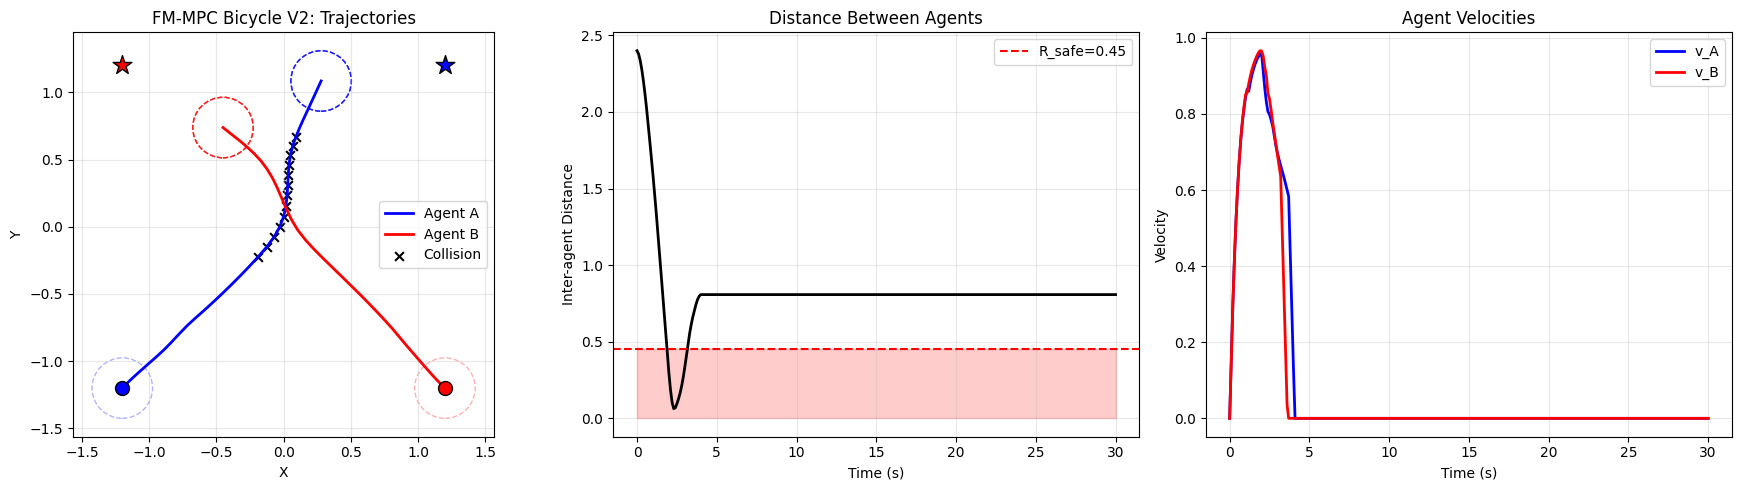

In [106]:
# ============================================================
# FM-MPC Bicycle - 修复版 V2
# 修复内容：
#   1. 预测对方轨迹作为多个障碍物（而非单点）
#   2. 改进 CBF 参数和时机
#   3. 添加停车逻辑
#   4. 修复 cond_vec
# ============================================================
import numpy as np, torch, math, sys, matplotlib.pyplot as plt
from pathlib import Path

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[device] {device}")

# ===============================================================
# 0) Load sampler_5h
# ===============================================================
repo_sampler = (Path.cwd().parent / "dmpc_fm_cbf" / "sampler_5h.py").resolve()
if repo_sampler.exists():
    sampler_path = repo_sampler
else:
    def find_nearest_file(filename, start, max_up=12):
        start = start.resolve()
        candidates = []
        p = start
        for _ in range(max_up):
            candidates += list(p.rglob(filename))
            p = p.parent
        if not candidates:
            raise FileNotFoundError(f"{filename} not found from {start}")
        return sorted(candidates, key=lambda x: len(str(x)))[0]
    sampler_path = find_nearest_file("sampler_5h.py", Path.cwd())

print(f"[sampler] {sampler_path}")

import importlib.util, inspect
spec = importlib.util.spec_from_file_location("sampler_5h", sampler_path)
sampler_mod = importlib.util.module_from_spec(spec)
sys.modules["sampler_5h"] = sampler_mod
spec.loader.exec_module(sampler_mod)

piecewise_sample_fm_5ch_with_cbf = sampler_mod.piecewise_sample_fm_5ch_with_cbf

# ===============================================================
# 1) Model check
# ===============================================================
if "model_5ch" not in dir():
    try:
        model_5ch = globals()["model_5ch"]
    except KeyError:
        raise RuntimeError("model_5ch must be loaded before running this cell!")

model_5ch = model_5ch.to(device).eval()
print("[model] loaded")

# ===============================================================
# 2) Parameters
# ===============================================================
dt_exec = 0.10

T_steps      = 40
num_segments = 10
total_time   = 1.0
ode_method   = "euler"
noise_scale  = 0.08

H = 12
K = 8
REPLAN_EVERY = 1
MAX_STEPS = 300
goal_tol = 0.25        # bicycle 精度有限，放宽判定
goal_stop_tol = 1.0    # 距离 < 1.0 就切换到停车控制

# ===============================================================
# 3) Bicycle dynamics
# ===============================================================
v_max_A   = 1.0
v_max_B   = 1.0
v_min     = 0.0
v_floor   = 0.05
a_max     = 1.5
L         = 0.3
delta_max = np.deg2rad(35)
delta_rate_max = np.deg2rad(90)

def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, *, dt, v_max):
    x, y, th, v, delta = s
    a  = float(np.clip(u[0], -a_max, a_max))
    dr = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    
    v2 = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.01:
        v2 = v_floor
    
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    omega  = v2 * math.tan(delta2) / L
    th2    = wrap_pi(th + dt * omega)
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, *, dt, v_max):
    Hh = U.shape[0]
    states = np.zeros((Hh+1, 5), dtype=np.float32)
    states[0] = s0
    for i in range(Hh):
        states[i+1] = bicycle_step(states[i], U[i], dt=dt, v_max=v_max)
    return states[:, :2], states

# ===============================================================
# 4) Canonical frame
# ===============================================================
def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy, np.float32).reshape(2)
    d = goal - start
    dist = float(np.linalg.norm(d) + 1e-9)
    cos_th = d[0] / dist
    sin_th = d[1] / dist
    R_wc = np.array([[cos_th, sin_th], [-sin_th, cos_th]], dtype=np.float32)
    R_cw = R_wc.T

    def world_to_can(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return ((xy - start) @ R_wc.T).astype(np.float32)

    def can_to_world(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return (xy @ R_cw.T + start).astype(np.float32)

    def world_to_can_angle(th_world):
        return wrap_pi(th_world - math.atan2(sin_th, cos_th))

    return {
        'w2c': world_to_can, 'c2w': can_to_world,
        'w2c_angle': world_to_can_angle,
        'start_can': np.array([0.0, 0.0], np.float32),
        'goal_can': np.array([dist, 0.0], np.float32),
        'dist': dist,
    }

# ===============================================================
# 5) CBF settings - 靠近才开启
# ===============================================================
SAFE_DIST_FAR  = 2.0   # 距离 > 2.0: CBF 关闭
SAFE_DIST_NEAR = 1.0   # 距离 < 1.0: 强 CBF

CBF_LIGHT  = dict(passes=4, extra_margin=0.12, alpha=12.0, max_corr_norm=3.0)
CBF_STRONG = dict(passes=10, extra_margin=0.22, alpha=25.0, max_corr_norm=4.0)

def get_cbf_config(dist_AB):
    """靠近才开启 CBF"""
    if dist_AB > SAFE_DIST_FAR:
        # 远距离：CBF 关闭
        return False, None
    elif dist_AB > SAFE_DIST_NEAR:
        # 中距离：轻量 CBF
        return True, CBF_LIGHT
    else:
        # 近距离：强 CBF
        return True, CBF_STRONG

# ===============================================================
# 6) FM trajectory sampling - 支持多障碍物
# ===============================================================
def make_x0_noise(T, seed):
    g = torch.Generator(device=device)
    g.manual_seed(int(seed))
    x0 = torch.randn((1, 5, T), device=device, generator=g) * noise_scale
    x0[:, :, 0] = 0.0
    return x0

def sample_fm_trajectory(*, self_state, goal_xy, other_pred_path, seed):
    """
    采样 FM 轨迹
    
    Args:
        self_state: 自己的状态 [x, y, theta, v, delta]
        goal_xy: 目标点 (2,)
        other_pred_path: 对方预测轨迹 (N, 2)，用于构建多个障碍物
        seed: 随机种子
    """
    self_xy = self_state[:2]
    tf = build_canonical_frame(self_xy, goal_xy)
    
    # 计算到对方当前位置的距离
    other_current = other_pred_path[0] if len(other_pred_path) > 0 else self_xy
    dist_AB = float(np.linalg.norm(self_xy - other_current))
    
    # 构建多个障碍物：沿对方预测轨迹采样几个点
    ellipses = []
    n_obs_points = min(5, len(other_pred_path))  # 最多 5 个障碍物点
    if n_obs_points > 0:
        indices = np.linspace(0, len(other_pred_path)-1, n_obs_points).astype(int)
        for idx in indices:
            other_xy = other_pred_path[idx]
            other_can = tf['w2c'](other_xy.reshape(1, 2))[0]
            # 距离越近，障碍物半径越大
            r_obs = 0.50 if dist_AB < 1.2 else 0.40
            ellipses.append({"center": other_can.copy(), "radius": r_obs})
    
    use_cbf, cbf_kwargs = get_cbf_config(dist_AB)
    x0_noise = make_x0_noise(T_steps, seed)
    
    # 正确的 cond_vec
    v0 = float(self_state[3])
    th_world = float(self_state[2])
    th_can = tf['w2c_angle'](th_world)
    delta0 = float(self_state[4]) if len(self_state) >= 5 else 0.0

    cond_vec = np.array([
        tf['dist'],
        v0,
        np.cos(th_can),
        np.sin(th_can),
        delta0,
    ], dtype=np.float32)

    x_can, states_norm, controls_norm = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch,
        T_steps=T_steps,
        device=str(device),
        total_time=total_time,
        num_segments=num_segments,
        ode_method=ode_method,
        atol=1e-4, rtol=1e-4,
        noise_scale=noise_scale,
        x0_noise=x0_noise,
        cond=cond_vec,
        start_xy_norm=tf['start_can'],
        goal_xy_norm=tf['goal_can'],
        start_guidance_weight=0.5,
        goal_guidance_weight=1.0,  # 增强 goal guidance
        goal_guidance_mode="tail",
        lock_start=True,
        use_cbf=use_cbf,
        scaler=None,
        ellipses=ellipses,
        cbf_kwargs=cbf_kwargs,
    )

    xy_can = x_can[0:2, :].T.astype(np.float32)
    theta_can = x_can[2, :].astype(np.float32)
    xy_world = tf['c2w'](xy_can)
    
    return xy_world, theta_can, use_cbf, tf

# ===============================================================
# 7) Path tracking -> Bicycle controls
# ===============================================================
def path_to_controls(s0, path_xy, goal_xy, *, H, dt, v_max,
                     lookahead_ratio=0.15, k_omega=2.5, k_accel=1.8):
    """
    Pure pursuit tracking，增加了靠近目标减速的逻辑
    """
    T_path = path_xy.shape[0]
    if T_path >= H + 1:
        indices = np.linspace(0, T_path - 1, H + 1).astype(int)
        ref = path_xy[indices]
    else:
        ref = np.zeros((H + 1, 2), dtype=np.float32)
        ref[:T_path] = path_xy
        ref[T_path:] = path_xy[-1]

    s = s0.copy()
    U = np.zeros((H, 2), dtype=np.float32)

    for i in range(H):
        x, y, th, v, delta = s
        
        # 到目标的距离
        dist_to_goal = float(np.linalg.norm(s[:2] - goal_xy))
        
        # Lookahead target
        look_idx = min(i + 1 + int(lookahead_ratio * H), H)
        target = ref[look_idx]
        dx = target[0] - x
        dy = target[1] - y
        dist = math.hypot(dx, dy)

        # Desired heading
        if dist > 0.01:
            th_des = math.atan2(dy, dx)
        else:
            th_des = th
        e_th = wrap_pi(th_des - th)

        # Steering control
        v_eff = max(abs(v), 0.1)
        omega_des = float(np.clip(k_omega * e_th, -delta_rate_max, delta_rate_max))
        delta_des = float(np.clip(math.atan(L * omega_des / v_eff), -delta_max, delta_max))
        dr = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))

        # Speed control - 靠近目标时尽早减速
        v_des = min(k_accel * dist / dt, v_max)
        BRAKE_RADIUS = 2.0   # 距离 < 2.0 就开始减速
        if dist_to_goal < BRAKE_RADIUS:
            # v_brake 线性下降: 0 at goal, v_max at BRAKE_RADIUS
            v_brake = v_max * (dist_to_goal / BRAKE_RADIUS)
            v_des = min(v_des, max(0.05, v_brake))
        
        # Turn penalty
        turn_penalty = max(0.3, 1.0 - 0.5 * abs(e_th) / np.pi)
        v_des *= turn_penalty
        
        a = float(np.clip(k_accel * (v_des - v), -a_max, a_max))

        U[i] = np.array([a, dr], dtype=np.float32)
        s = bicycle_step(s, U[i], dt=dt, v_max=v_max)

    return U, ref

# ===============================================================
# 8) Cost function
# ===============================================================
R_SAFE = 0.45

W_GOAL_END  = 15.0
W_GOAL_PATH = 2.0
W_COLL      = 300.0
W_SMOOTH    = 0.3
W_SPEED     = 0.05

def compute_cost(pos_self, states_self, pos_other_pred, goal_xy, U, v_pref):
    d_end  = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path = float(np.mean(np.linalg.norm(pos_self - goal_xy, axis=1)))
    
    # Collision cost - 检查与预测轨迹的所有点
    min_dist = float('inf')
    for i in range(len(pos_self)):
        j = min(i, len(pos_other_pred) - 1)
        d = float(np.linalg.norm(pos_self[i] - pos_other_pred[j]))
        min_dist = min(min_dist, d)
    
    violations = np.clip(R_SAFE - min_dist, 0.0, None)
    coll_cost = float(violations ** 2)
    
    dU = np.diff(U, axis=0, prepend=U[0:1])
    smooth_cost = float(np.mean(dU[:, 0]**2 + 0.5 * dU[:, 1]**2))
    v_mean = float(np.mean(states_self[:, 3]))
    speed_cost = float((v_pref - v_mean) ** 2)
    
    return (W_GOAL_END * d_end + W_GOAL_PATH * d_path +
            W_COLL * coll_cost + W_SMOOTH * smooth_cost + W_SPEED * speed_cost)

# ===============================================================
# 9) Predict other agent - 简单线性预测
# ===============================================================
def predict_other_path(other_state, other_path_cache, *, H, dt):
    """
    预测对方轨迹：
    1. 如果有缓存的路径，使用缓存
    2. 否则用简单的恒速直线预测
    """
    if other_path_cache is not None and len(other_path_cache) >= 2:
        T_path = other_path_cache.shape[0]
        if T_path >= H + 1:
            indices = np.linspace(0, T_path - 1, H + 1).astype(int)
            return other_path_cache[indices].astype(np.float32)
        else:
            pred = np.zeros((H + 1, 2), dtype=np.float32)
            pred[:T_path] = other_path_cache
            pred[T_path:] = other_path_cache[-1]
            return pred
    
    # 简单线性预测：假设对方保持当前速度和方向
    x, y, th, v = other_state[:4]
    pred = np.zeros((H + 1, 2), dtype=np.float32)
    for i in range(H + 1):
        pred[i, 0] = x + i * dt * v * math.cos(th)
        pred[i, 1] = y + i * dt * v * math.sin(th)
    return pred

# ===============================================================
# 10) MPC replan
# ===============================================================
def mpc_replan(*, self_state, goal_xy, other_state, other_path_cache,
               v_max_self, v_pref, seed_base):
    
    # 预测对方轨迹
    other_pred_path = predict_other_path(other_state, other_path_cache, H=H, dt=dt_exec)
    
    best = None
    cbf_count = 0
    
    for k in range(K):
        seed = int(seed_base + 137 * k + 7919)
        try:
            path_xy, _, used_cbf, _ = sample_fm_trajectory(
                self_state=self_state,
                goal_xy=goal_xy,
                other_pred_path=other_pred_path,  # 传入预测轨迹
                seed=seed,
            )
        except Exception as e:
            print(f"  [WARN] FM sample failed: {e}")
            continue
        
        cbf_count += int(used_cbf)
        
        U, ref = path_to_controls(
            self_state, path_xy, goal_xy,
            H=H, dt=dt_exec, v_max=v_max_self,
            lookahead_ratio=0.12, k_omega=2.5, k_accel=1.8
        )
        
        pos_self, states_self = rollout_bicycle(self_state, U, dt=dt_exec, v_max=v_max_self)
        J = compute_cost(pos_self, states_self, other_pred_path, goal_xy, U, v_pref)
        u0 = U[0].copy()
        
        if best is None or J < best[0]:
            best = (J, u0, path_xy.copy(), used_cbf)
    
    if best is None:
        return np.zeros(2, dtype=np.float32), float('inf'), None, 0
    
    return best[1], best[0], best[2], cbf_count

# ===============================================================
# 11) 停车控制
# ===============================================================
def stopping_control(self_state, goal_xy, *, dt, v_max):
    """
    当接近目标时的停车控制
    """
    x, y, th, v, delta = self_state
    dist_to_goal = float(np.linalg.norm(self_state[:2] - goal_xy))
    
    # 减速停车
    if v > 0.01:
        a = -min(a_max, v / dt)  # 刹车
    else:
        a = 0.0
    
    # 转向角归零
    if abs(delta) > 0.01:
        dr = -np.sign(delta) * min(delta_rate_max, abs(delta) / dt)
    else:
        dr = 0.0
    
    return np.array([a, dr], dtype=np.float32)

# ===============================================================
# 12) Scenario setup
# ===============================================================
xA0 = np.array([-1.2, -1.2], dtype=np.float32)
gA  = np.array([ 1.2,  1.2], dtype=np.float32)
xB0 = np.array([ 1.2, -1.2], dtype=np.float32)
gB  = np.array([-1.2,  1.2], dtype=np.float32)

thA0 = float(math.atan2(gA[1] - xA0[1], gA[0] - xA0[0]))
thB0 = float(math.atan2(gB[1] - xB0[1], gB[0] - xB0[0]))

sA = np.array([xA0[0], xA0[1], thA0, 0.0, 0.0], dtype=np.float32)
sB = np.array([xB0[0], xB0[1], thB0, 0.0, 0.0], dtype=np.float32)

trajA = [sA.copy()]
trajB = [sB.copy()]
uA = np.zeros(2, dtype=np.float32)
uB = np.zeros(2, dtype=np.float32)
pathA_cache = None
pathB_cache = None
cbf_total = 0
replan_count = 0

print("=" * 60)
print("FM-MPC Bicycle V2: Two-Agent Collision Avoidance")
print("=" * 60)
print(f"Agent A: {xA0} -> {gA}, v_max={v_max_A}")
print(f"Agent B: {xB0} -> {gB}, v_max={v_max_B}")
print(f"H={H}, K={K}, dt={dt_exec}, T_steps={T_steps}")
print("=" * 60)

# ===============================================================
# 13) Main loop
# ===============================================================
for step in range(MAX_STEPS):
    dA = float(np.linalg.norm(sA[:2] - gA))
    dB = float(np.linalg.norm(sB[:2] - gB))
    
    # 停车判定：到达目标即可（刹车逻辑已保证会减速）
    doneA = dA < goal_tol
    doneB = dB < goal_tol
    
    if doneA and doneB:
        print(f"\n[DONE] Both agents reached goals at step {step}")
        break

    if step % REPLAN_EVERY == 0:
        replan_count += 1
        
        # Agent A
        if dA < goal_stop_tol:
            # 接近目标，使用停车控制
            uA = stopping_control(sA, gA, dt=dt_exec, v_max=v_max_A)
            pathA_cache = None
        elif not doneA:
            uA, JA, pathA_cache, cbfA = mpc_replan(
                self_state=sA, goal_xy=gA, other_state=sB,
                other_path_cache=pathB_cache,
                v_max_self=v_max_A, v_pref=0.5,
                seed_base=1000 + step * 31,
            )
            cbf_total += cbfA
        else:
            uA = np.zeros(2, dtype=np.float32)
            pathA_cache = None
        
        # Agent B
        if dB < goal_stop_tol:
            uB = stopping_control(sB, gB, dt=dt_exec, v_max=v_max_B)
            pathB_cache = None
        elif not doneB:
            uB, JB, pathB_cache, cbfB = mpc_replan(
                self_state=sB, goal_xy=gB, other_state=sA,
                other_path_cache=pathA_cache,
                v_max_self=v_max_B, v_pref=0.4,
                seed_base=2000 + step * 37,
            )
            cbf_total += cbfB
        else:
            uB = np.zeros(2, dtype=np.float32)
            pathB_cache = None
        
        if step < 20 or step % 20 == 0:
            dist_AB = float(np.linalg.norm(sA[:2] - sB[:2]))
            print(f"[step {step:3d}] dA={dA:.3f} dB={dB:.3f} dist_AB={dist_AB:.3f} "
                  f"vA={sA[3]:.2f} vB={sB[3]:.2f}")

    # Execute - with goal-proximity brake override
    if not doneA:
        if dA < 0.8 and sA[3] > 0.1:
            brake_a = float(np.clip(-sA[3] * 3.0, -a_max, 0))
            uA = np.array([brake_a, uA[1]], dtype=np.float32)
        sA = bicycle_step(sA, uA, dt=dt_exec, v_max=v_max_A)
    if not doneB:
        if dB < 0.8 and sB[3] > 0.1:
            brake_a = float(np.clip(-sB[3] * 3.0, -a_max, 0))
            uB = np.array([brake_a, uB[1]], dtype=np.float32)
        sB = bicycle_step(sB, uB, dt=dt_exec, v_max=v_max_B)
    
    trajA.append(sA.copy())
    trajB.append(sB.copy())

trajA = np.array(trajA, dtype=np.float32)
trajB = np.array(trajB, dtype=np.float32)

print(f"\n[stats] replans={replan_count} | FM samples={replan_count * K * 2} | CBF used={cbf_total}")

# ===============================================================
# 14) Analysis & Visualization
# ===============================================================
dist_AB = np.linalg.norm(trajA[:, :2] - trajB[:, :2], axis=1)
coll_mask = dist_AB < R_SAFE
coll_steps = np.where(coll_mask)[0]

print(f"[collision] min_dist={dist_AB.min():.4f} | collision_steps={len(coll_steps)}")
print(f"[A final] pos={trajA[-1,:2]} | dist_to_goal={float(np.linalg.norm(trajA[-1,:2]-gA)):.4f} | v={trajA[-1,3]:.3f}")
print(f"[B final] pos={trajB[-1,:2]} | dist_to_goal={float(np.linalg.norm(trajB[-1,:2]-gB)):.4f} | v={trajB[-1,3]:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Trajectories
ax = axes[0]
ax.plot(trajA[:, 0], trajA[:, 1], 'b-', lw=2, label='Agent A')
ax.plot(trajB[:, 0], trajB[:, 1], 'r-', lw=2, label='Agent B')
ax.scatter([xA0[0]], [xA0[1]], c='blue', s=100, marker='o', edgecolors='black', zorder=5)
ax.scatter([gA[0]], [gA[1]], c='blue', s=200, marker='*', edgecolors='black', zorder=5)
ax.scatter([xB0[0]], [xB0[1]], c='red', s=100, marker='o', edgecolors='black', zorder=5)
ax.scatter([gB[0]], [gB[1]], c='red', s=200, marker='*', edgecolors='black', zorder=5)
if len(coll_steps) > 0:
    ax.scatter(trajA[coll_steps, 0], trajA[coll_steps, 1], c='black', s=40, marker='x', label='Collision')
for t in range(0, len(trajA), max(1, len(trajA)//6)):
    ax.add_patch(plt.Circle(trajA[t, :2], R_SAFE/2, fill=False, color='blue', alpha=0.3, ls='--'))
    ax.add_patch(plt.Circle(trajB[t, :2], R_SAFE/2, fill=False, color='red', alpha=0.3, ls='--'))
ax.set_xlabel('X'); ax.set_ylabel('Y')
ax.set_aspect('equal'); ax.grid(alpha=0.3); ax.legend()
ax.set_title('FM-MPC Bicycle V2: Trajectories')

# Distance
ax2 = axes[1]
time_axis = np.arange(len(dist_AB)) * dt_exec
ax2.plot(time_axis, dist_AB, 'k-', lw=2)
ax2.axhline(R_SAFE, color='r', ls='--', label=f'R_safe={R_SAFE}')
ax2.fill_between(time_axis, 0, R_SAFE, alpha=0.2, color='red')
ax2.set_xlabel('Time (s)'); ax2.set_ylabel('Inter-agent Distance')
ax2.set_title('Distance Between Agents')
ax2.legend(); ax2.grid(alpha=0.3)

# Velocities
ax3 = axes[2]
ax3.plot(time_axis[:len(trajA)], trajA[:, 3], 'b-', lw=2, label='v_A')
ax3.plot(time_axis[:len(trajB)], trajB[:, 3], 'r-', lw=2, label='v_B')
ax3.set_xlabel('Time (s)'); ax3.set_ylabel('Velocity')
ax3.set_title('Agent Velocities')
ax3.legend(); ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

[device] cuda
[sampler] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[sampler sig] (*, model_5ch, T_steps: 'int', device: 'str' = 'cuda', total_time: 'float' = 1.0, num_segments: 'int' = 20, ode_method: 'str' = 'dopri5', atol: 'float' = 1e-05, rtol: 'float' = 1e-05, noise_scale: 'float' = 1.0, x0_noise: 'torch.Tensor | None' = None, cond=None, start_xy=None, start_xy_norm=None, start_guidance_weight: 'float' = 0.0, lock_start: 'bool' = False, goal_xy=None, goal_xy_norm=None, goal_guidance_weight: 'float' = 0.0, goal_guidance_mode: 'str' = 'endpoint', use_cbf: 'bool' = True, scaler=None, ellipses=None, tau0_hf: 'float' = 0.7, p_hf: 'float' = 2.0, lf_on: 'float' = 1.0, hf_max: 'float' = 1.0, cbf_kwargs: 'dict | None' = None)
[model] loaded
FM-MPC Bicycle (Pure Pursuit STANDARD + Time-Expanded Prediction)
H=12, K=5, dt=0.1, T_steps=40
goal_tol=0.25, creep_radius=0.9, stop_radius=0.35, v_creep=0.12
[step   0] dA=3.394 dB=3.394 dist_AB=2.400 vA=0.00 vB=0.00 uA=[+1.50,+0.33] uB=

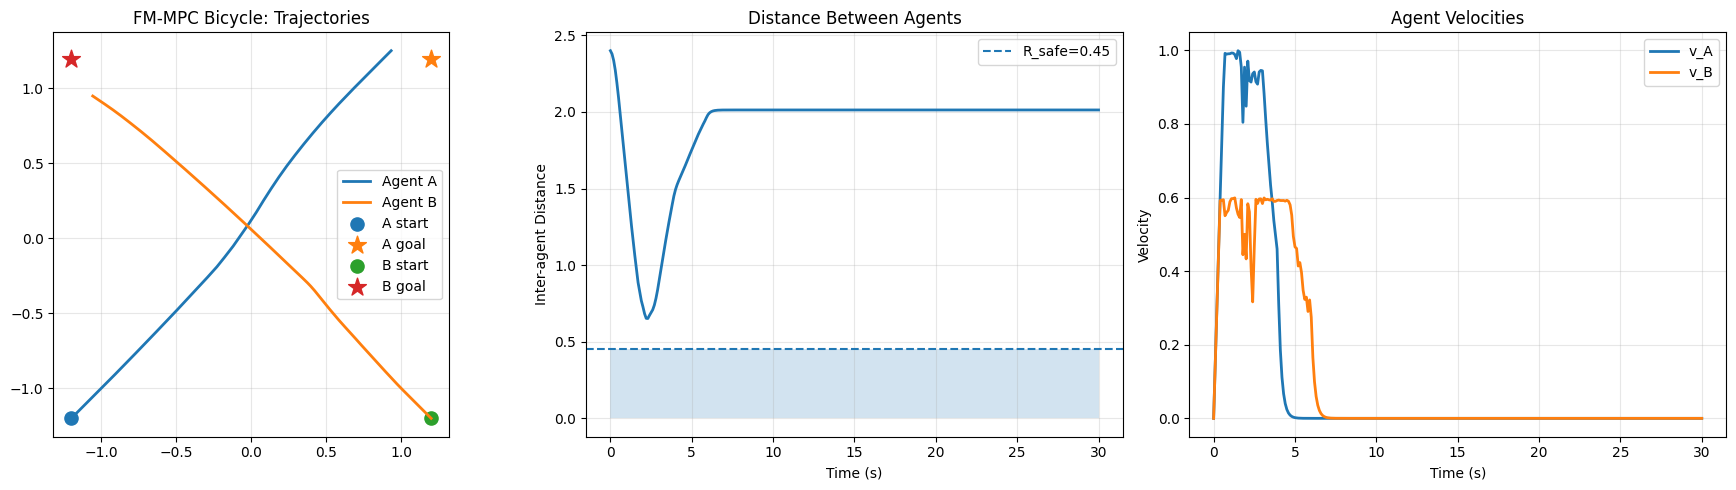

In [109]:
# ============================================================
# FM-MPC Bicycle (Pure Pursuit STANDARD + Time-Expanded Prediction + Stop-at-Goal)
# - FM sampler outputs x_can (5,T): [x, y, theta, ?, ?]  (we mainly use XY path)
# - Control executed on bicycle: u = [a, delta_rate]
# Fixes:
#   1) Standard pure pursuit curvature -> delta_des (no unit-mixing)
#   2) Predict other agent by rolling out its last control (cheap + dynamic)
#   3) Use multiple predicted points as obstacles (time-expanded ellipses)
#   4) Smaller obstacle radius + mild inflation near
#   5) Proper goal speed profile + creep + full stop near goal
# ============================================================

import numpy as np, torch, math, sys, matplotlib.pyplot as plt
from pathlib import Path

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[device] {device}")

# ===============================================================
# 0) Load sampler_5h
# ===============================================================
repo_sampler = (Path.cwd().parent / "dmpc_fm_cbf" / "sampler_5h.py").resolve()
if repo_sampler.exists():
    sampler_path = repo_sampler
else:
    def find_nearest_file(filename, start, max_up=12):
        start = start.resolve()
        candidates = []
        p = start
        for _ in range(max_up):
            candidates += list(p.rglob(filename))
            p = p.parent
        if not candidates:
            raise FileNotFoundError(f"{filename} not found from {start}")
        return sorted(candidates, key=lambda x: len(str(x)))[0]
    sampler_path = find_nearest_file("sampler_5h.py", Path.cwd())

print(f"[sampler] {sampler_path}")

import importlib.util, inspect
spec = importlib.util.spec_from_file_location("sampler_5h", sampler_path)
sampler_mod = importlib.util.module_from_spec(spec)
sys.modules["sampler_5h"] = sampler_mod
spec.loader.exec_module(sampler_mod)

piecewise_sample_fm_5ch_with_cbf = sampler_mod.piecewise_sample_fm_5ch_with_cbf
sampler_sig = inspect.signature(piecewise_sample_fm_5ch_with_cbf)
print("[sampler sig]", sampler_sig)
assert "cond" in sampler_sig.parameters, "Loaded sampler has no cond; wrong sampler file?"

# ===============================================================
# 1) Model check
# ===============================================================
if "model_5ch" not in dir():
    try:
        model_5ch = globals()["model_5ch"]
    except KeyError:
        raise RuntimeError("model_5ch must be loaded before running this cell!")

model_5ch = model_5ch.to(device).eval()
print("[model] loaded")

# ===============================================================
# 2) Parameters
# ===============================================================
dt_exec = 0.10

# FM
T_steps      = 40
num_segments = 5
total_time   = 1.0
ode_method   = "euler"
noise_scale  = 0.08

# MPC
H = 12
K = 5
REPLAN_EVERY = 1
MAX_STEPS = 300

# Goal / stopping
goal_tol      = 0.25     # reach condition
stop_radius   = 0.35     # start braking hard and align
creep_radius  = 0.90     # start slowing down
v_creep       = 0.12     # crawl speed

# Safety
R_SAFE = 0.45

# ===============================================================
# 3) Bicycle dynamics  (state = [x, y, theta, v, delta])
# ===============================================================
v_max_A   = 1.0
v_max_B   = 0.6
v_min     = 0.0
a_max     = 1.5
L         = 0.30
delta_max = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_floor   = 0.05  # small positive to avoid deadlock at start

def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, *, dt, v_max):
    x, y, th, v, delta = s
    a  = float(np.clip(u[0], -a_max, a_max))
    dr = float(np.clip(u[1], -delta_rate_max, delta_rate_max))

    v2 = float(np.clip(v + dt * a, v_min, v_max))
    # if accelerating and too small, lift to floor to escape zero-speed singularity
    if v2 < v_floor and a > 0.02:
        v2 = v_floor

    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2 = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))

    x2 = x + dt * v2 * math.cos(th2)
    y2 = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, *, dt, v_max):
    Hh = U.shape[0]
    st = np.zeros((Hh+1, 5), dtype=np.float32)
    st[0] = s0
    for i in range(Hh):
        st[i+1] = bicycle_step(st[i], U[i], dt=dt, v_max=v_max)
    return st[:, :2], st

# ===============================================================
# 4) Canonical frame (SE2: start->origin, goal->+x)
# ===============================================================
def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy, np.float32).reshape(2)
    d = goal - start
    dist = float(np.linalg.norm(d) + 1e-9)
    c = float(d[0] / dist)
    s = float(d[1] / dist)

    R_wc = np.array([[c, s], [-s, c]], dtype=np.float32)  # world->can
    R_cw = R_wc.T

    def w2c(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return ((xy - start) @ R_wc.T).astype(np.float32)

    def c2w(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return (xy @ R_cw.T + start).astype(np.float32)

    def w2c_angle(th_w):
        # subtract canonical heading offset
        return wrap_pi(th_w - math.atan2(s, c))

    return {
        "w2c": w2c, "c2w": c2w,
        "w2c_angle": w2c_angle,
        "start_can": np.array([0.0, 0.0], np.float32),
        "goal_can":  np.array([dist, 0.0], np.float32),
        "dist": dist,
    }

# ===============================================================
# 5) CBF settings (time-expanded obstacles)
# ===============================================================
# Smaller radii (you asked to reduce)
r_obs_far  = 0.32
r_obs_near = 0.38

SAFE_DIST_FAR  = 2.0
SAFE_DIST_NEAR = 1.0

CBF_LIGHT  = dict(passes=2,  extra_margin=0.08, alpha=12.0, max_corr_norm=3.0)
CBF_STRONG = dict(passes=5, extra_margin=0.16, alpha=25.0, max_corr_norm=4.0)

def get_cbf_config(dist_AB):
    if dist_AB > SAFE_DIST_FAR:
        return False, None
    elif dist_AB > SAFE_DIST_NEAR:
        return True, CBF_LIGHT
    else:
        return True, CBF_STRONG

# ===============================================================
# 6) Other-agent prediction (cheap rollout with last control)
# ===============================================================
def predict_other_traj(other_state, other_u_last, *, H, dt, v_max):
    """
    Cheap dynamic prediction:
    - roll out bicycle using last executed control (constant over horizon)
    """
    if other_u_last is None:
        other_u_last = np.zeros(2, np.float32)
    U = np.tile(np.asarray(other_u_last, np.float32).reshape(1,2), (H,1))
    pos, st = rollout_bicycle(other_state, U, dt=dt, v_max=v_max)
    return pos, st

def build_time_expanded_ellipses(tf, other_pred_pos, dist_AB):
    """
    Create multiple obstacle circles along predicted other trajectory.
    Put more weight on early times.
    """
    if other_pred_pos is None or len(other_pred_pos) < 2:
        return []

    # choose indices biased toward early horizon
    idxs = [0, 1, 2, 4, 6, 8, 10, len(other_pred_pos)-1]
    idxs = [i for i in idxs if 0 <= i < len(other_pred_pos)]
    idxs = sorted(list(dict.fromkeys(idxs)))  # unique

    r = (r_obs_near if dist_AB < 1.2 else r_obs_far)
    ellipses = []
    for i in idxs:
        c_can = tf["w2c"](other_pred_pos[i].reshape(1,2))[0]
        ellipses.append({"center": c_can.copy(), "radius": float(r)})
    return ellipses

# ===============================================================
# 7) FM sampling (uses predicted other trajectory as time-expanded obstacles)
# ===============================================================
def make_x0_noise(T, seed):
    g = torch.Generator(device=device)
    g.manual_seed(int(seed))
    x0 = torch.randn((1, 5, T), device=device, generator=g) * float(noise_scale)
    x0[:, :, 0] = 0.0
    return x0

def sample_fm_path(*, self_state, goal_xy, other_pred_pos, seed):
    self_xy = self_state[:2]
    tf = build_canonical_frame(self_xy, goal_xy)

    # distance to other's current predicted position
    if other_pred_pos is None or len(other_pred_pos) == 0:
        other_now = self_xy
    else:
        other_now = other_pred_pos[0]
    dist_AB = float(np.linalg.norm(self_xy - other_now))

    use_cbf, cbf_kwargs = get_cbf_config(dist_AB)
    ellipses = build_time_expanded_ellipses(tf, other_pred_pos, dist_AB) if use_cbf else []

    x0_noise = make_x0_noise(T_steps, seed)

    # cond_vec: keep consistent with your training (dist, v0, cos(th_can), sin(th_can), delta0)
    v0 = float(self_state[3])
    th_can = tf["w2c_angle"](float(self_state[2]))
    delta0 = float(self_state[4])
    cond_vec = np.array([tf["dist"], v0, np.cos(th_can), np.sin(th_can), delta0], dtype=np.float32)

    x_can, states_norm, controls_norm = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch,
        T_steps=T_steps,
        device=str(device),
        total_time=total_time,
        num_segments=num_segments,
        ode_method=ode_method,
        atol=1e-4, rtol=1e-4,
        noise_scale=noise_scale,
        x0_noise=x0_noise,
        cond=cond_vec,
        start_xy_norm=tf["start_can"],
        goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.45,
        goal_guidance_weight=0.90,
        goal_guidance_mode="tail",
        lock_start=True,
        use_cbf=bool(use_cbf),
        scaler=None,
        ellipses=ellipses,
        cbf_kwargs=cbf_kwargs,
    )

    # use XY path only
    xy_can = x_can[0:2, :].T.astype(np.float32)     # (T,2)
    path_xy = tf["c2w"](xy_can).astype(np.float32)  # (T,2)
    return path_xy, bool(use_cbf), dist_AB

# ===============================================================
# 8) Standard Pure Pursuit -> bicycle controls
# ===============================================================
def _closest_index(path_xy, pos_xy):
    d = np.linalg.norm(path_xy - pos_xy.reshape(1,2), axis=1)
    return int(np.argmin(d))

def _lookahead_point(path_xy, pos_xy, *, Ld, start_idx=0):
    """
    Find first point whose distance to pos >= Ld, scanning forward.
    If not found, return last point.
    """
    for i in range(start_idx, len(path_xy)):
        if float(np.linalg.norm(path_xy[i] - pos_xy)) >= Ld:
            return path_xy[i], i
    return path_xy[-1], len(path_xy)-1

def pure_pursuit_controls(s0, path_xy, goal_xy, *, H, dt, v_max):
    """
    Standard pure pursuit for bicycle:
      alpha = angle(target - pos) - theta
      kappa = 2*sin(alpha)/Ld
      delta_des = atan(L*kappa)
      delta_rate = (delta_des - delta)/dt clipped
    Speed profile:
      far: approach v_max
      within creep_radius: scale down to v_creep
      within stop_radius: brake to stop
    """
    s = s0.copy()
    U = np.zeros((H, 2), dtype=np.float32)

    # tune
    Ld_min = 0.35
    Ld_max = 1.10
    k_v    = 1.2      # speed gain from goal distance
    k_brake = 4.0     # braking gain near stop

    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)

    last_path_idx = 0

    for i in range(H):
        x, y, th, v, delta = s
        pos = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))

        # --- goal stop logic ---
        if d_goal <= stop_radius:
            # brake and straighten wheels
            a = float(np.clip(-k_brake * v, -a_max, 0.0))
            delta_des = 0.0
            dr = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))
            U[i] = np.array([a, dr], dtype=np.float32)
            s = bicycle_step(s, U[i], dt=dt, v_max=v_max)
            continue

        # --- lookahead distance (bigger when faster) ---
        Ld = float(np.clip(0.55 + 0.65 * v, Ld_min, Ld_max))

        # find nearest on path then lookahead
        near_idx = _closest_index(path_xy, pos)
        near_idx = max(near_idx, last_path_idx)  # do not go backward
        target, last_path_idx = _lookahead_point(path_xy, pos, Ld=Ld, start_idx=near_idx)

        # bearing to target
        dx = float(target[0] - x)
        dy = float(target[1] - y)
        ang = float(math.atan2(dy, dx))
        alpha = float(wrap_pi(ang - th))

        # curvature & steering
        kappa = 2.0 * math.sin(alpha) / max(1e-3, Ld)
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))

        # speed profile (approach goal)
        v_des = float(np.clip(k_v * d_goal, v_creep, v_max))
        if d_goal < creep_radius:
            # linearly go to creep speed
            v_des = float(np.clip(v_creep + (v_max - v_creep) * (d_goal / creep_radius), v_creep, v_max))

        # turn penalty: slow down if steering large
        turn_pen = max(0.35, 1.0 - 0.55 * abs(delta_des) / delta_max)
        v_des *= turn_pen

        a = float(np.clip((v_des - v) / dt, -a_max, a_max))

        U[i] = np.array([a, dr], dtype=np.float32)
        s = bicycle_step(s, U[i], dt=dt, v_max=v_max)

    return U

# ===============================================================
# 9) Cost (optional but kept for K candidates selection)
#    If you want "NO COST", set K=1 and just take first sample.
# ===============================================================
W_END   = 18.0
W_PATH  = 1.5
W_COLL  = 450.0
W_SMOOTH = 0.25

def compute_cost(pos_self, pos_other_pred, goal_xy, U):
    goal_xy = np.asarray(goal_xy, np.float32)
    d_end = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path = float(np.mean(np.linalg.norm(pos_self - goal_xy.reshape(1,2), axis=1)))

    # time-aligned distance
    M = min(len(pos_self), len(pos_other_pred))
    if M <= 1:
        min_d = float("inf")
    else:
        d = np.linalg.norm(pos_self[:M] - pos_other_pred[:M], axis=1)
        min_d = float(d.min())

    viol = max(0.0, R_SAFE - min_d)
    coll = float(viol * viol)

    dU = np.diff(U, axis=0, prepend=U[0:1])
    smooth = float(np.mean(dU[:,0]**2 + 0.4*dU[:,1]**2))

    return W_END*d_end + W_PATH*d_path + W_COLL*coll + W_SMOOTH*smooth

# ===============================================================
# 10) MPC replan
# ===============================================================
def mpc_replan(self_state, goal_xy, other_state, other_u_last, *, v_max_self, v_max_other, seed_base):
    other_pred_pos, _ = predict_other_traj(other_state, other_u_last, H=H, dt=dt_exec, v_max=v_max_other)

    best = None  # (J, u0, path_cache, used_cbf)
    cbf_count = 0

    for k in range(K):
        seed = int(seed_base + 137*k + 7919)
        try:
            path_xy, used_cbf, distAB = sample_fm_path(
                self_state=self_state, goal_xy=goal_xy, other_pred_pos=other_pred_pos, seed=seed
            )
        except Exception as e:
            print(f"  [WARN] FM sample failed: {e}")
            continue

        cbf_count += int(used_cbf)

        U = pure_pursuit_controls(self_state, path_xy, goal_xy, H=H, dt=dt_exec, v_max=v_max_self)
        pos_self, st_self = rollout_bicycle(self_state, U, dt=dt_exec, v_max=v_max_self)

        J = compute_cost(pos_self, other_pred_pos, goal_xy, U)
        u0 = U[0].copy()

        if best is None or J < best[0]:
            best = (J, u0, path_xy.copy(), used_cbf)

    if best is None:
        return np.zeros(2, np.float32), float("inf"), None, 0

    return best[1], best[0], best[2], cbf_count

# ===============================================================
# 11) Scenario setup
# ===============================================================
xA0 = np.array([-1.2, -1.2], dtype=np.float32); gA = np.array([ 1.2,  1.2], dtype=np.float32)
xB0 = np.array([ 1.2, -1.2], dtype=np.float32); gB = np.array([-1.2,  1.2], dtype=np.float32)

thA0 = float(math.atan2(gA[1] - xA0[1], gA[0] - xA0[0]))
thB0 = float(math.atan2(gB[1] - xB0[1], gB[0] - xB0[0]))

# [x, y, theta, v, delta]
sA = np.array([xA0[0], xA0[1], thA0, 0.0, 0.0], dtype=np.float32)
sB = np.array([xB0[0], xB0[1], thB0, 0.0, 0.0], dtype=np.float32)

trajA = [sA.copy()]
trajB = [sB.copy()]
uA = np.zeros(2, np.float32)
uB = np.zeros(2, np.float32)

pathA_cache = None
pathB_cache = None

cbf_total = 0
replan_count = 0

print("="*60)
print("FM-MPC Bicycle (Pure Pursuit STANDARD + Time-Expanded Prediction)")
print("="*60)
print(f"H={H}, K={K}, dt={dt_exec}, T_steps={T_steps}")
print(f"goal_tol={goal_tol}, creep_radius={creep_radius}, stop_radius={stop_radius}, v_creep={v_creep}")
print("="*60)

# ===============================================================
# 12) Main loop
# ===============================================================
for step in range(MAX_STEPS):
    dA = float(np.linalg.norm(sA[:2] - gA))
    dB = float(np.linalg.norm(sB[:2] - gB))
    doneA = (dA < goal_tol and sA[3] < 0.08)
    doneB = (dB < goal_tol and sB[3] < 0.08)

    if doneA and doneB:
        print(f"\n[DONE] both reached goals at step {step}")
        break

    if step % REPLAN_EVERY == 0:
        replan_count += 1

        if not doneA:
            uA, JA, pathA_cache, cbfA = mpc_replan(
                sA, gA, sB, uB, v_max_self=v_max_A, v_max_other=v_max_B, seed_base=1000 + step*31
            )
            cbf_total += cbfA
        else:
            uA = np.zeros(2, np.float32)
            pathA_cache = None

        if not doneB:
            uB, JB, pathB_cache, cbfB = mpc_replan(
                sB, gB, sA, uA, v_max_self=v_max_B, v_max_other=v_max_A, seed_base=2000 + step*37
            )
            cbf_total += cbfB
        else:
            uB = np.zeros(2, np.float32)
            pathB_cache = None

        if step < 15 or step % 20 == 0:
            dist_AB = float(np.linalg.norm(sA[:2] - sB[:2]))
            print(f"[step {step:3d}] dA={dA:.3f} dB={dB:.3f} dist_AB={dist_AB:.3f} "
                  f"vA={sA[3]:.2f} vB={sB[3]:.2f} uA=[{uA[0]:+.2f},{uA[1]:+.2f}] uB=[{uB[0]:+.2f},{uB[1]:+.2f}]")

    # execute one step
    if not doneA:
        sA = bicycle_step(sA, uA, dt=dt_exec, v_max=v_max_A)
    if not doneB:
        sB = bicycle_step(sB, uB, dt=dt_exec, v_max=v_max_B)

    trajA.append(sA.copy())
    trajB.append(sB.copy())

trajA = np.asarray(trajA, np.float32)
trajB = np.asarray(trajB, np.float32)

print(f"\n[stats] replans={replan_count} | FM samples={replan_count * K * 2} | CBF used={cbf_total}")

# ===============================================================
# 13) Analysis & plots
# ===============================================================
dist_AB = np.linalg.norm(trajA[:, :2] - trajB[:, :2], axis=1)
coll_steps = np.where(dist_AB < R_SAFE)[0]
print(f"[collision] min_dist={float(dist_AB.min()):.4f} | collision_steps={len(coll_steps)}")
print(f"[A final] pos={trajA[-1,:2]} | dist_to_goal={float(np.linalg.norm(trajA[-1,:2]-gA)):.4f} | v={trajA[-1,3]:.3f}")
print(f"[B final] pos={trajB[-1,:2]} | dist_to_goal={float(np.linalg.norm(trajB[-1,:2]-gB)):.4f} | v={trajB[-1,3]:.3f}")

t = np.arange(len(trajA)) * dt_exec

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(trajA[:,0], trajA[:,1], lw=2, label="Agent A")
ax.plot(trajB[:,0], trajB[:,1], lw=2, label="Agent B")
ax.scatter([xA0[0]], [xA0[1]], s=90, marker="o", label="A start")
ax.scatter([gA[0]],  [gA[1]],  s=180, marker="*", label="A goal")
ax.scatter([xB0[0]], [xB0[1]], s=90, marker="o", label="B start")
ax.scatter([gB[0]],  [gB[1]],  s=180, marker="*", label="B goal")
if len(coll_steps) > 0:
    ax.scatter(trajA[coll_steps,0], trajA[coll_steps,1], s=40, marker="x", label="Collision(A)")
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("FM-MPC Bicycle: Trajectories")

ax2 = axes[1]
ax2.plot(t, dist_AB, lw=2)
ax2.axhline(R_SAFE, ls="--", label=f"R_safe={R_SAFE}")
ax2.fill_between(t, 0, R_SAFE, alpha=0.2)
ax2.grid(alpha=0.3); ax2.legend()
ax2.set_title("Distance Between Agents")
ax2.set_xlabel("Time (s)"); ax2.set_ylabel("Inter-agent Distance")

ax3 = axes[2]
ax3.plot(t, trajA[:,3], lw=2, label="v_A")
ax3.plot(t, trajB[:,3], lw=2, label="v_B")
ax3.grid(alpha=0.3); ax3.legend()
ax3.set_title("Agent Velocities")
ax3.set_xlabel("Time (s)"); ax3.set_ylabel("Velocity")

plt.tight_layout()
plt.show()


=== 诊断 FM 采样 ===
tf['dist']: 3.394
tf['goal_can']: [3.3941126 0.       ]

Path shape: (40, 2)
Path start: [-1.2 -1.2]
Path end:   [1.2224953 1.2460911]
Goal:       [1.2 1.2]
Distance path_end to goal: 0.051


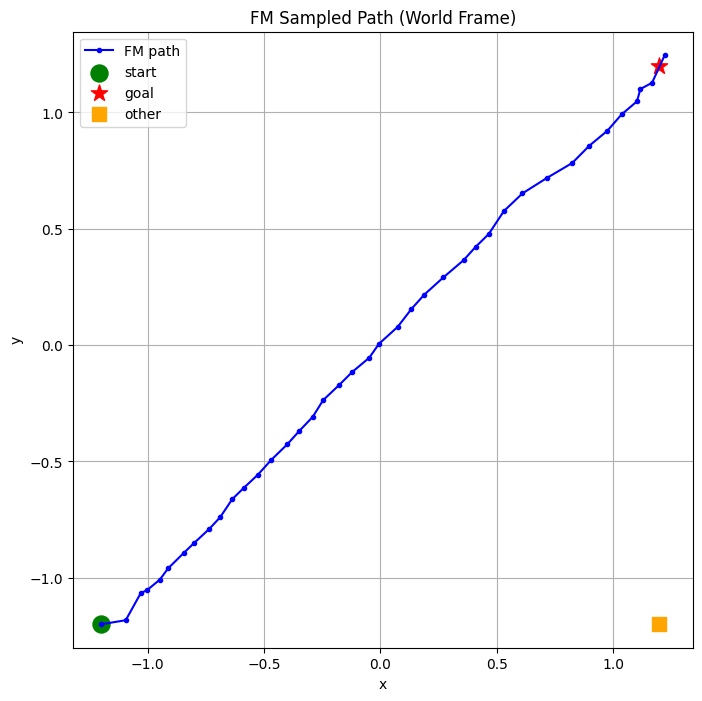


=== Canonical Frame 检查 ===
Path_can start: [0. 0.]
Path_can end:   [3.4426107  0.01668479]
Goal_can:       [3.3941126 0.       ]


In [98]:
# 请运行这个诊断代码
print("=== 诊断 FM 采样 ===")

# 模拟 Agent A 的状态
test_state = np.array([-1.2, -1.2, np.pi/4, 0.5, 0.0], dtype=np.float32)
test_goal = np.array([1.2, 1.2], dtype=np.float32)
test_other = np.array([[1.2, -1.2]], dtype=np.float32)  # B 的位置

# 采样
path_xy, theta_can, used_cbf, tf = sample_fm_trajectory(
    self_state=test_state,
    goal_xy=test_goal,
    other_pred_path=test_other,
    seed=12345,
)

print(f"tf['dist']: {tf['dist']:.3f}")
print(f"tf['goal_can']: {tf['goal_can']}")
print(f"\nPath shape: {path_xy.shape}")
print(f"Path start: {path_xy[0]}")
print(f"Path end:   {path_xy[-1]}")
print(f"Goal:       {test_goal}")
print(f"Distance path_end to goal: {np.linalg.norm(path_xy[-1] - test_goal):.3f}")

# 可视化
plt.figure(figsize=(8, 8))
plt.plot(path_xy[:, 0], path_xy[:, 1], 'b.-', label='FM path')
plt.scatter([test_state[0]], [test_state[1]], c='green', s=150, marker='o', label='start')
plt.scatter([test_goal[0]], [test_goal[1]], c='red', s=150, marker='*', label='goal')
plt.scatter([test_other[0, 0]], [test_other[0, 1]], c='orange', s=100, marker='s', label='other')
plt.xlabel('x'); plt.ylabel('y')
plt.axis('equal'); plt.grid(True); plt.legend()
plt.title('FM Sampled Path (World Frame)')
plt.show()

# 检查 canonical frame 的轨迹
print("\n=== Canonical Frame 检查 ===")
path_can = tf['w2c'](path_xy)
print(f"Path_can start: {path_can[0]}")
print(f"Path_can end:   {path_can[-1]}")
print(f"Goal_can:       {tf['goal_can']}")

=== 诊断 Path Tracking ===
Controls U shape: (12, 2)
U[0] (first control): a=0.879, dr=-1.095
U mean: a=0.376, dr=0.007

Rollout:
  Start: [-1.2 -1.2]
  End:   [-0.49371642 -0.50645375]
  Goal:  [1.2 1.2]
  Dist to goal: 2.404


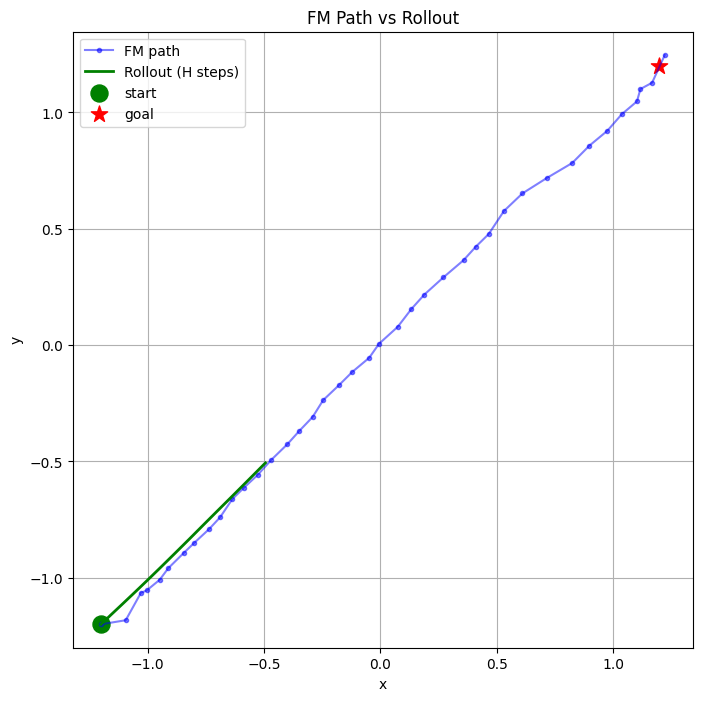


=== 模拟多次 Replan ===
Step 0: pos=[-1.1575239 -1.1593629], dist=3.335, v=0.59
Step 1: pos=[-1.1092349 -1.1142519], dist=3.269, v=0.66
Step 2: pos=[-1.0562735 -1.0652788], dist=3.197, v=0.72
Step 3: pos=[-0.99983567 -1.0127318 ], dist=3.120, v=0.77
Step 4: pos=[-0.9408878 -0.9569659], dist=3.039, v=0.81
Step 5: pos=[-0.88011813 -0.8983488 ], dist=2.955, v=0.84
Step 6: pos=[-0.8180112  -0.83724606], dist=2.868, v=0.87
Step 7: pos=[-0.75495267 -0.7739697 ], dist=2.778, v=0.89
Step 8: pos=[-0.69115543 -0.70885766], dist=2.687, v=0.91
Step 9: pos=[-0.6268144 -0.6421749], dist=2.594, v=0.93
Step 10: pos=[-0.5619895  -0.57421595], dist=2.500, v=0.94
Step 20: pos=[0.09901869 0.14256379], dist=1.527, v=0.99


In [99]:
# 诊断 tracking controller
print("=== 诊断 Path Tracking ===")

# 用刚才的 path 测试 tracking
test_state = np.array([-1.2, -1.2, np.pi/4, 0.5, 0.0], dtype=np.float32)
test_goal = np.array([1.2, 1.2], dtype=np.float32)

U, ref = path_to_controls(
    test_state, path_xy, test_goal,
    H=H, dt=dt_exec, v_max=v_max_A,
    lookahead_ratio=0.12, k_omega=2.5, k_accel=1.8
)

print(f"Controls U shape: {U.shape}")
print(f"U[0] (first control): a={U[0,0]:.3f}, dr={U[0,1]:.3f}")
print(f"U mean: a={U[:,0].mean():.3f}, dr={U[:,1].mean():.3f}")

# Rollout 看看轨迹
pos_rollout, states_rollout = rollout_bicycle(test_state, U, dt=dt_exec, v_max=v_max_A)
print(f"\nRollout:")
print(f"  Start: {states_rollout[0, :2]}")
print(f"  End:   {states_rollout[-1, :2]}")
print(f"  Goal:  {test_goal}")
print(f"  Dist to goal: {np.linalg.norm(states_rollout[-1, :2] - test_goal):.3f}")

# 可视化
plt.figure(figsize=(8, 8))
plt.plot(path_xy[:, 0], path_xy[:, 1], 'b.-', alpha=0.5, label='FM path')
plt.plot(pos_rollout[:, 0], pos_rollout[:, 1], 'g-', lw=2, label='Rollout (H steps)')
plt.scatter([test_state[0]], [test_state[1]], c='green', s=150, marker='o', label='start')
plt.scatter([test_goal[0]], [test_goal[1]], c='red', s=150, marker='*', label='goal')
plt.xlabel('x'); plt.ylabel('y')
plt.axis('equal'); plt.grid(True); plt.legend()
plt.title('FM Path vs Rollout')
plt.show()

# 检查多次 replan 的效果
print("\n=== 模拟多次 Replan ===")
s = test_state.copy()
for step in range(30):
    # 采样新轨迹
    other_pred = np.tile(np.array([1.2, -1.2]), (H+1, 1))  # B 静止
    path_xy, _, _, tf = sample_fm_trajectory(
        self_state=s,
        goal_xy=test_goal,
        other_pred_path=other_pred,
        seed=1000 + step * 31,
    )
    
    # Tracking
    U, ref = path_to_controls(s, path_xy, test_goal, H=H, dt=dt_exec, v_max=v_max_A)
    
    # 只执行第一步
    u0 = U[0]
    s = bicycle_step(s, u0, dt=dt_exec, v_max=v_max_A)
    
    d = np.linalg.norm(s[:2] - test_goal)
    if step < 10 or step % 10 == 0:
        print(f"Step {step}: pos={s[:2]}, dist={d:.3f}, v={s[3]:.2f}")
    
    if d < 0.15:
        print(f"Reached goal at step {step}!")
        break

In [100]:
# 检查多次 replan 的效果
print("\n=== 模拟多次 Replan ===")
s = test_state.copy()
for step in range(30):
    # 采样新轨迹
    other_pred = np.tile(np.array([1.2, -1.2]), (H+1, 1))  # B 静止
    path_xy, _, _, tf = sample_fm_trajectory(
        self_state=s,
        goal_xy=test_goal,
        other_pred_path=other_pred,
        seed=1000 + step * 31,
    )
    
    # Tracking
    U, ref = path_to_controls(s, path_xy, test_goal, H=H, dt=dt_exec, v_max=v_max_A)
    
    # 只执行第一步
    u0 = U[0]
    s = bicycle_step(s, u0, dt=dt_exec, v_max=v_max_A)
    
    d = np.linalg.norm(s[:2] - test_goal)
    if step < 10 or step % 10 == 0:
        print(f"Step {step}: pos={s[:2]}, dist={d:.3f}, v={s[3]:.2f}")
    
    if d < 0.15:
        print(f"Reached goal at step {step}!")
        break

print(f"\nFinal: pos={s[:2]}, dist to goal={np.linalg.norm(s[:2] - test_goal):.3f}")


=== 模拟多次 Replan ===
Step 0: pos=[-1.1575239 -1.1593629], dist=3.335, v=0.59
Step 1: pos=[-1.1092349 -1.1142519], dist=3.269, v=0.66
Step 2: pos=[-1.0562735 -1.0652788], dist=3.197, v=0.72
Step 3: pos=[-0.99983567 -1.0127318 ], dist=3.120, v=0.77
Step 4: pos=[-0.9408878 -0.9569659], dist=3.039, v=0.81
Step 5: pos=[-0.88011813 -0.8983488 ], dist=2.955, v=0.84
Step 6: pos=[-0.8180112  -0.83724606], dist=2.868, v=0.87
Step 7: pos=[-0.75495267 -0.7739697 ], dist=2.778, v=0.89
Step 8: pos=[-0.69115543 -0.70885766], dist=2.687, v=0.91
Step 9: pos=[-0.6268144 -0.6421749], dist=2.594, v=0.93
Step 10: pos=[-0.5619895  -0.57421595], dist=2.500, v=0.94
Step 20: pos=[0.09901869 0.14256379], dist=1.527, v=0.99

Final: pos=[0.7029867  0.79205996], dist to goal=0.643


=== 模拟 100 步 Replan ===
Step  0: pos=[-1.19, -1.19], dist=3.394, v=0.15
Step  1: pos=[-1.17, -1.17], dist=3.379, v=0.30
Step  2: pos=[-1.14, -1.14], dist=3.349, v=0.42
Step  3: pos=[-1.10, -1.10], dist=3.308, v=0.52
Step  4: pos=[-1.05, -1.06], dist=3.255, v=0.60
Step  5: pos=[-1.00, -1.02], dist=3.195, v=0.67
Step  6: pos=[-0.95, -0.97], dist=3.128, v=0.73
Step  7: pos=[-0.89, -0.92], dist=3.055, v=0.78
Step  8: pos=[-0.83, -0.87], dist=2.977, v=0.82
Step  9: pos=[-0.77, -0.81], dist=2.895, v=0.85
Step 10: pos=[-0.70, -0.75], dist=2.810, v=0.88
Step 20: pos=[-0.05, -0.06], dist=1.874, v=0.98
Step 30: pos=[+0.61, +0.68], dist=0.886, v=1.00
Step 40: pos=[+1.04, +1.15], dist=0.187, v=0.28
Step 50: pos=[+1.05, +1.16], dist=0.152, v=0.00
Step 60: pos=[+1.05, +1.16], dist=0.152, v=0.00
Step 70: pos=[+1.05, +1.16], dist=0.152, v=0.00
Step 80: pos=[+1.05, +1.16], dist=0.152, v=0.00
Step 90: pos=[+1.05, +1.16], dist=0.152, v=0.00

Final: pos=[1.052427  1.1642741], dist=0.152, v=0.000


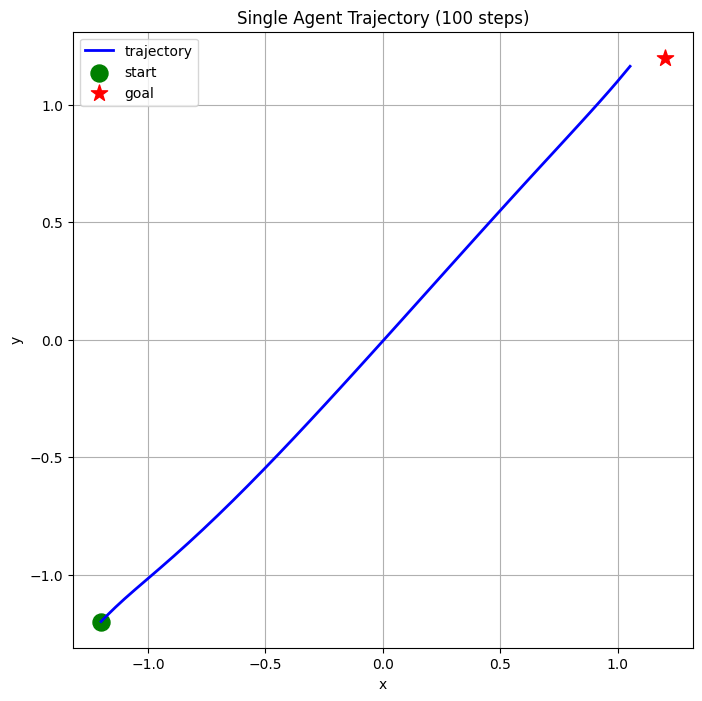

In [101]:
# 延长测试到 100 步
print("=== 模拟 100 步 Replan ===")
test_state = np.array([-1.2, -1.2, np.pi/4, 0.0, 0.0], dtype=np.float32)  # 初始速度为 0
test_goal = np.array([1.2, 1.2], dtype=np.float32)

s = test_state.copy()
traj = [s.copy()]

for step in range(100):
    other_pred = np.tile(np.array([1.2, -1.2]), (H+1, 1))
    
    d = np.linalg.norm(s[:2] - test_goal)
    
    # 检查是否到达
    if d < goal_tol and abs(s[3]) < 0.05:
        print(f"✅ Reached goal at step {step}!")
        break
    
    # 停车逻辑
    if d < goal_stop_tol:
        u0 = stopping_control(s, test_goal, dt=dt_exec, v_max=v_max_A)
    else:
        path_xy, _, _, tf = sample_fm_trajectory(
            self_state=s,
            goal_xy=test_goal,
            other_pred_path=other_pred,
            seed=1000 + step * 31,
        )
        U, ref = path_to_controls(s, path_xy, test_goal, H=H, dt=dt_exec, v_max=v_max_A)
        u0 = U[0]
    
    s = bicycle_step(s, u0, dt=dt_exec, v_max=v_max_A)
    traj.append(s.copy())
    
    if step < 10 or step % 10 == 0:
        print(f"Step {step:2d}: pos=[{s[0]:+.2f}, {s[1]:+.2f}], dist={d:.3f}, v={s[3]:.2f}")

traj = np.array(traj)
print(f"\nFinal: pos={s[:2]}, dist={np.linalg.norm(s[:2] - test_goal):.3f}, v={s[3]:.3f}")

# 可视化
plt.figure(figsize=(8, 8))
plt.plot(traj[:, 0], traj[:, 1], 'b-', lw=2, label='trajectory')
plt.scatter([test_state[0]], [test_state[1]], c='green', s=150, marker='o', label='start')
plt.scatter([test_goal[0]], [test_goal[1]], c='red', s=150, marker='*', label='goal')
plt.xlabel('x'); plt.ylabel('y')
plt.axis('equal'); plt.grid(True); plt.legend()
plt.title('Single Agent Trajectory (100 steps)')
plt.show()

In [56]:
# 测试 cond 对模型输出的影响
print("=== 检查 cond 影响 ===")

x_test = torch.randn(1, 5, 40, device=device)
t_test = torch.tensor([0.5], device=device)

with torch.no_grad():
    # 不用 cond
    v_no_cond = model_5ch(x_test, t_test, cond=None)
    
    # 用 dummy cond
    cond1 = torch.tensor([[1, 0, 1, 0, 0]], device=device, dtype=torch.float32)
    v_cond1 = model_5ch(x_test, t_test, cond=cond1)
    
    # 用不同的 cond
    cond2 = torch.tensor([[0, 1, 0, 1, 1]], device=device, dtype=torch.float32)
    v_cond2 = model_5ch(x_test, t_test, cond=cond2)

print(f"v (no cond):   mean={v_no_cond.mean().item():.4f}, std={v_no_cond.std().item():.4f}")
print(f"v (cond1):     mean={v_cond1.mean().item():.4f}, std={v_cond1.std().item():.4f}")
print(f"v (cond2):     mean={v_cond2.mean().item():.4f}, std={v_cond2.std().item():.4f}")

# 检查差异
diff_1 = (v_cond1 - v_no_cond).abs().mean().item()
diff_2 = (v_cond2 - v_cond1).abs().mean().item()
print(f"\n|v_cond1 - v_no_cond|: {diff_1:.4f}")
print(f"|v_cond2 - v_cond1|:   {diff_2:.4f}")

if diff_1 < 0.01 and diff_2 < 0.01:
    print("\n✅ cond 对模型输出影响很小，可能模型没有使用 conditioning")
else:
    print("\n⚠️ cond 对模型输出有影响！需要确认正确的 cond 值")

=== 检查 cond 影响 ===
v (no cond):   mean=0.2787, std=1.8193
v (cond1):     mean=0.3553, std=1.7052
v (cond2):     mean=0.2590, std=1.2983

|v_cond1 - v_no_cond|: 0.7342
|v_cond2 - v_cond1|:   1.0764

⚠️ cond 对模型输出有影响！需要确认正确的 cond 值


1. 检查 cond 对模型输出的影响
v (no cond):   mean=0.2419, std=1.9940
v (cond1):     mean=0.2489, std=1.6835
v (cond2):     mean=0.5926, std=1.7728

|v_cond1 - v_no_cond|: 0.4564
|v_cond2 - v_cond1|:   0.8258

⚠️ cond 对模型输出有影响！

2. 检查 cond 各维度的统计 (训练数据)

维度                 mean        std        min        max
-------------------------------------------------------
dist             3.0000     0.0000     3.0000     3.0000
v0               0.3755     0.1307     0.1597     0.5966
cos(th0)         0.0220     0.7065    -0.9999     1.0000
sin(th0)        -0.0443     0.7060    -1.0000     0.9999
delta0           0.0000     0.0000     0.0000     0.0000

3. 测试不同 cond 对采样轨迹的影响


C:\Users\ROG\AppData\Local\Temp\ipykernel_35212\2169106066.py:137: UserWarning: Glyph 30701 (\N{CJK UNIFIED IDEOGRAPH-77ED}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_35212\2169106066.py:137: UserWarning: Glyph 36317 (\N{CJK UNIFIED IDEOGRAPH-8DDD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_35212\2169106066.py:137: UserWarning: Glyph 31163 (\N{CJK UNIFIED IDEOGRAPH-79BB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_35212\2169106066.py:137: UserWarning: Glyph 38745 (\N{CJK UNIFIED IDEOGRAPH-9759}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_35212\2169106066.py:137: UserWarning: Glyph 27490 (\N{CJK UNIFIED IDEOGRAPH-6B62}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_35212\2169106066.py:137: UserWarning: Glyph 26397 (\N{CJK 

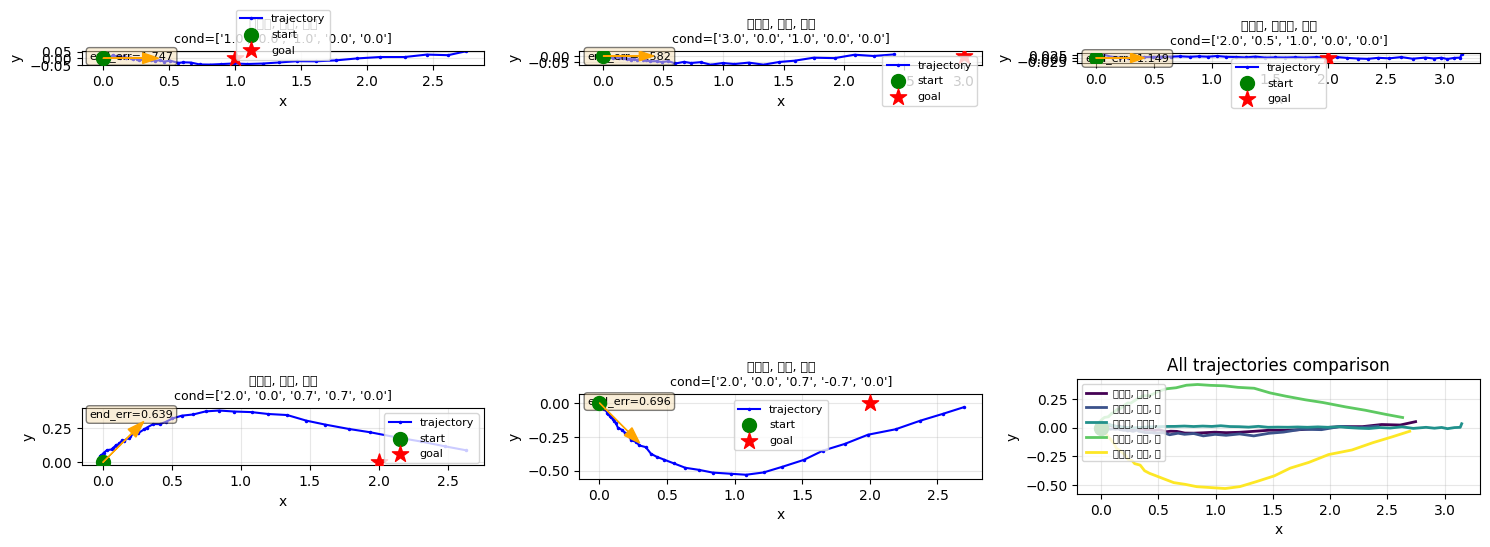


4. 量化 cond 对轨迹终点的影响

场景                          dist    end_x    end_y  end_err path_len
---------------------------------------------------------------------------
短距离, 静止, 朝前                 1.00    2.746    0.052    1.747    2.821
长距离, 静止, 朝前                 3.00    2.418    0.013    0.582    2.526
中距离, 有速度, 朝前                2.00    3.148    0.034    1.149    3.119
中距离, 静止, 偏左                 2.00    2.633    0.089    0.639    2.814
中距离, 静止, 偏右                 2.00    2.695   -0.032    0.696    3.040

5. 检查 canonical frame 变换是否正确

start           goal                dist        goal_can       回转误差
----------------------------------------------------------------------
[-1.2 -1.2]     [1.2 1.2]          3.394 [3.3941128 0.       ]   0.000000
[0. 0.]         [2. 0.]            2.000 [2. 0.]           0.000000
[0. 0.]         [0. 2.]            2.000 [2. 0.]           0.000000
[1. 1.]         [2. 3.]            2.236 [2.236068 0.      ]   0.000000

6. 完整 MPC 场景测试 (单 agent)

World sta

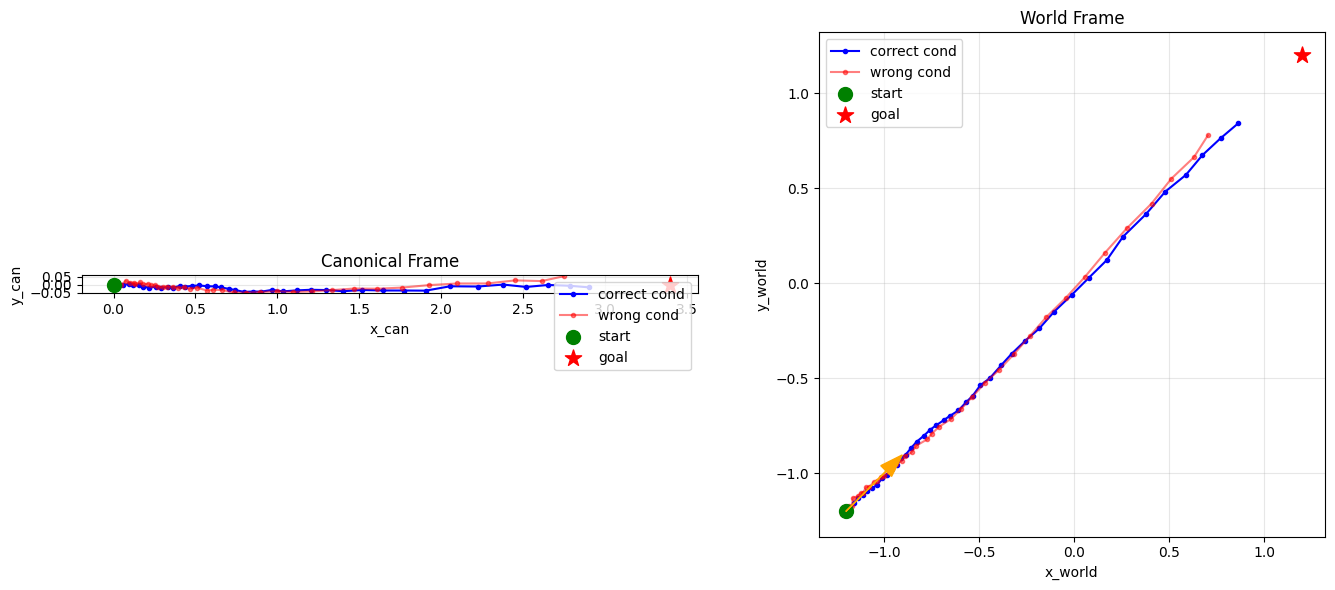


[结果]
  Correct cond -> goal error: 0.4919
  Wrong cond   -> goal error: 0.6502
  Improvement: 0.1582 (32.2% worse with wrong cond)

✅ 正确的 cond 显著改善了轨迹质量！


In [118]:
# ===============================================================
# 完整检查: cond 影响 + canonical frame + 采样质量
# ===============================================================

print("=" * 60)
print("1. 检查 cond 对模型输出的影响")
print("=" * 60)

x_test = torch.randn(1, 5, 40, device=device)
t_test = torch.tensor([0.5], device=device)

with torch.no_grad():
    # 不用 cond
    v_no_cond = model_5ch(x_test, t_test, cond=None)
    
    # 用 dummy cond
    cond1 = torch.tensor([[1, 0, 1, 0, 0]], device=device, dtype=torch.float32)
    v_cond1 = model_5ch(x_test, t_test, cond=cond1)
    
    # 用不同的 cond
    cond2 = torch.tensor([[0, 1, 0, 1, 1]], device=device, dtype=torch.float32)
    v_cond2 = model_5ch(x_test, t_test, cond=cond2)

print(f"v (no cond):   mean={v_no_cond.mean().item():.4f}, std={v_no_cond.std().item():.4f}")
print(f"v (cond1):     mean={v_cond1.mean().item():.4f}, std={v_cond1.std().item():.4f}")
print(f"v (cond2):     mean={v_cond2.mean().item():.4f}, std={v_cond2.std().item():.4f}")

diff_1 = (v_cond1 - v_no_cond).abs().mean().item()
diff_2 = (v_cond2 - v_cond1).abs().mean().item()
print(f"\n|v_cond1 - v_no_cond|: {diff_1:.4f}")
print(f"|v_cond2 - v_cond1|:   {diff_2:.4f}")

if diff_1 < 0.01 and diff_2 < 0.01:
    print("\n✅ cond 对模型输出影响很小")
else:
    print("\n⚠️ cond 对模型输出有影响！")

# ===============================================================
print("\n" + "=" * 60)
print("2. 检查 cond 各维度的统计 (训练数据)")
print("=" * 60)

# cond = [dist, v0, cos(th0_can), sin(th0_can), delta0]
cond_names = ['dist', 'v0', 'cos(th0)', 'sin(th0)', 'delta0']

print(f"\n{'维度':<12} {'mean':>10} {'std':>10} {'min':>10} {'max':>10}")
print("-" * 55)
for i, name in enumerate(cond_names):
    c = cond_all[:, i]
    print(f"{name:<12} {c.mean():>10.4f} {c.std():>10.4f} {c.min():>10.4f} {c.max():>10.4f}")

# ===============================================================
print("\n" + "=" * 60)
print("3. 测试不同 cond 对采样轨迹的影响")
print("=" * 60)

def sample_trajectory_with_cond(cond_vec, seed=42):
    """用指定 cond 采样一条轨迹"""
    g = torch.Generator(device=device)
    g.manual_seed(seed)
    x0 = torch.randn((1, 5, 40), device=device, generator=g) * 0.08
    x0[:, :, 0] = 0.0
    
    cond_t = torch.tensor(cond_vec, device=device, dtype=torch.float32).unsqueeze(0)
    
    # 简单 Euler 积分
    x = x0.clone()
    n_steps = 20
    dt = 1.0 / n_steps
    
    with torch.no_grad():
        for i in range(n_steps):
            t = torch.tensor([i * dt], device=device)
            v = model_5ch(x, t, cond=cond_t)
            x = x + v * dt
    
    return x[0].cpu().numpy()  # (5, 40)

# 测试不同场景的 cond
test_cases = [
    # [dist, v0, cos(th0), sin(th0), delta0]
    ("短距离, 静止, 朝前", [1.0, 0.0, 1.0, 0.0, 0.0]),
    ("长距离, 静止, 朝前", [3.0, 0.0, 1.0, 0.0, 0.0]),
    ("中距离, 有速度, 朝前", [2.0, 0.5, 1.0, 0.0, 0.0]),
    ("中距离, 静止, 偏左", [2.0, 0.0, 0.7, 0.7, 0.0]),
    ("中距离, 静止, 偏右", [2.0, 0.0, 0.7, -0.7, 0.0]),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, cond_vec) in enumerate(test_cases):
    if idx >= len(axes):
        break
    
    traj = sample_trajectory_with_cond(cond_vec, seed=42)
    x, y = traj[0], traj[1]
    
    ax = axes[idx]
    ax.plot(x, y, 'b.-', markersize=3, label='trajectory')
    ax.scatter([0], [0], c='green', s=100, marker='o', zorder=5, label='start')
    ax.scatter([cond_vec[0]], [0], c='red', s=150, marker='*', zorder=5, label='goal')
    
    # 画初始 heading 方向
    th0 = np.arctan2(cond_vec[3], cond_vec[2])
    arrow_len = 0.3
    ax.arrow(0, 0, arrow_len * np.cos(th0), arrow_len * np.sin(th0),
             head_width=0.08, color='orange', zorder=5)
    
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    ax.set_title(f"{name}\ncond={[f'{c:.1f}' for c in cond_vec]}", fontsize=9)
    
    # 计算终点误差
    end_dist = np.sqrt((x[-1] - cond_vec[0])**2 + y[-1]**2)
    ax.text(0.02, 0.98, f"end_err={end_dist:.3f}", transform=ax.transAxes, 
            fontsize=8, va='top', ha='left', 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 最后一个图：对比所有轨迹
ax = axes[-1]
colors = plt.cm.viridis(np.linspace(0, 1, len(test_cases)))
for idx, (name, cond_vec) in enumerate(test_cases):
    traj = sample_trajectory_with_cond(cond_vec, seed=42)
    ax.plot(traj[0], traj[1], '-', color=colors[idx], lw=2, label=name[:10])
ax.scatter([0], [0], c='green', s=100, marker='o', zorder=5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7, loc='upper left')
ax.set_title('All trajectories comparison')

plt.tight_layout()
plt.show()

# ===============================================================
print("\n" + "=" * 60)
print("4. 量化 cond 对轨迹终点的影响")
print("=" * 60)

results = []
for name, cond_vec in test_cases:
    traj = sample_trajectory_with_cond(cond_vec, seed=42)
    x_end, y_end = traj[0, -1], traj[1, -1]
    goal_x = cond_vec[0]
    end_err = np.sqrt((x_end - goal_x)**2 + y_end**2)
    path_len = np.sum(np.sqrt(np.diff(traj[0])**2 + np.diff(traj[1])**2))
    
    results.append({
        'name': name,
        'dist': cond_vec[0],
        'end_x': x_end,
        'end_y': y_end,
        'end_err': end_err,
        'path_len': path_len,
    })

print(f"\n{'场景':<25} {'dist':>6} {'end_x':>8} {'end_y':>8} {'end_err':>8} {'path_len':>8}")
print("-" * 75)
for r in results:
    print(f"{r['name']:<25} {r['dist']:>6.2f} {r['end_x']:>8.3f} {r['end_y']:>8.3f} {r['end_err']:>8.3f} {r['path_len']:>8.3f}")

# ===============================================================
print("\n" + "=" * 60)
print("5. 检查 canonical frame 变换是否正确")
print("=" * 60)

# 测试 world -> canonical -> world 往返
test_points = [
    ([-1.2, -1.2], [1.2, 1.2]),   # 对角线
    ([0.0, 0.0], [2.0, 0.0]),     # 水平
    ([0.0, 0.0], [0.0, 2.0]),     # 垂直
    ([1.0, 1.0], [2.0, 3.0]),     # 任意
]

print(f"\n{'start':<15} {'goal':<15} {'dist':>8} {'goal_can':>15} {'回转误差':>10}")
print("-" * 70)

for start, goal in test_points:
    start = np.array(start, dtype=np.float32)
    goal = np.array(goal, dtype=np.float32)
    
    tf = build_canonical_frame(start, goal)
    
    # 测试往返
    goal_can = tf['w2c'](goal.reshape(1, 2))[0]
    goal_back = tf['c2w'](goal_can.reshape(1, 2))[0]
    roundtrip_err = np.linalg.norm(goal - goal_back)
    
    print(f"{str(start):<15} {str(goal):<15} {tf['dist']:>8.3f} {str(goal_can):<15} {roundtrip_err:>10.6f}")

# ===============================================================
print("\n" + "=" * 60)
print("6. 完整 MPC 场景测试 (单 agent)")
print("=" * 60)

# 模拟一个完整的 MPC 步骤
test_state = np.array([-1.2, -1.2, np.pi/4, 0.3, 0.0], dtype=np.float32)
test_goal = np.array([1.2, 1.2], dtype=np.float32)

tf = build_canonical_frame(test_state[:2], test_goal)

# 计算正确的 cond
v0 = float(test_state[3])
th_world = float(test_state[2])
th_can = tf['w2c_angle'](th_world)
delta0 = float(test_state[4])

correct_cond = np.array([
    tf['dist'],
    v0,
    np.cos(th_can),
    np.sin(th_can),
    delta0,
], dtype=np.float32)

print(f"\nWorld state: pos={test_state[:2]}, theta={np.rad2deg(th_world):.1f} deg, v={v0:.2f}")
print(f"Goal:        {test_goal}")
print(f"Canonical:   dist={tf['dist']:.3f}, th_can={np.rad2deg(th_can):.1f} deg")
print(f"Correct cond: {correct_cond}")

# 用正确 cond 采样
traj_correct = sample_trajectory_with_cond(correct_cond, seed=123)

# 用错误 cond 采样 (dummy)
wrong_cond = np.array([1.0, 0.0, 1.0, 0.0, 0.0], dtype=np.float32)
traj_wrong = sample_trajectory_with_cond(wrong_cond, seed=123)

# 转回 world frame
traj_correct_world = tf['c2w'](traj_correct[:2].T)
traj_wrong_world = tf['c2w'](traj_wrong[:2].T)

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Canonical frame
ax1 = axes[0]
ax1.plot(traj_correct[0], traj_correct[1], 'b.-', label='correct cond')
ax1.plot(traj_wrong[0], traj_wrong[1], 'r.-', alpha=0.5, label='wrong cond')
ax1.scatter([0], [0], c='green', s=100, marker='o', zorder=5, label='start')
ax1.scatter([tf['dist']], [0], c='red', s=150, marker='*', zorder=5, label='goal')
ax1.set_xlabel('x_can')
ax1.set_ylabel('y_can')
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_title('Canonical Frame')

# World frame
ax2 = axes[1]
ax2.plot(traj_correct_world[:, 0], traj_correct_world[:, 1], 'b.-', label='correct cond')
ax2.plot(traj_wrong_world[:, 0], traj_wrong_world[:, 1], 'r.-', alpha=0.5, label='wrong cond')
ax2.scatter([test_state[0]], [test_state[1]], c='green', s=100, marker='o', zorder=5, label='start')
ax2.scatter([test_goal[0]], [test_goal[1]], c='red', s=150, marker='*', zorder=5, label='goal')

# 画 heading 方向
arrow_len = 0.3
ax2.arrow(test_state[0], test_state[1], 
          arrow_len * np.cos(th_world), arrow_len * np.sin(th_world),
          head_width=0.08, color='orange', zorder=5)

ax2.set_xlabel('x_world')
ax2.set_ylabel('y_world')
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_title('World Frame')

plt.tight_layout()
plt.show()

# 计算误差
err_correct = np.linalg.norm(traj_correct_world[-1] - test_goal)
err_wrong = np.linalg.norm(traj_wrong_world[-1] - test_goal)

print(f"\n[结果]")
print(f"  Correct cond -> goal error: {err_correct:.4f}")
print(f"  Wrong cond   -> goal error: {err_wrong:.4f}")
print(f"  Improvement: {err_wrong - err_correct:.4f} ({(err_wrong/err_correct - 1)*100:.1f}% worse with wrong cond)")

if err_correct < err_wrong * 0.8:
    print("\n✅ 正确的 cond 显著改善了轨迹质量！")
else:
    print("\n⚠️ cond 对轨迹质量影响不大，可能模型没有充分学习 conditioning")

In [57]:
# 检查 checkpoint 里是否保存了 cond 相关信息
ckpt = torch.load("cache/model_vel_5ch_canonical_r.pt", map_location=device)

print("=== Checkpoint 完整信息 ===")
for k, v in ckpt.items():
    if isinstance(v, dict):
        print(f"{k}: dict with keys {list(v.keys())}")
    elif isinstance(v, (list, np.ndarray)):
        print(f"{k}: {type(v).__name__}, len={len(v)}")
    elif isinstance(v, torch.Tensor):
        print(f"{k}: Tensor, shape={v.shape}")
    else:
        print(f"{k}: {v}")

# 检查是否有 config 或 args
if 'config' in ckpt:
    print(f"\nConfig: {ckpt['config']}")
if 'args' in ckpt:
    print(f"\nArgs: {ckpt['args']}")
if 'cond_dim' in ckpt:
    print(f"\ncond_dim: {ckpt['cond_dim']}")

=== Checkpoint 完整信息 ===
model_state_dict: dict with keys ['time_mlp.1.weight', 'time_mlp.1.bias', 'time_mlp.3.weight', 'time_mlp.3.bias', 'cond_mlp.0.weight', 'cond_mlp.0.bias', 'cond_mlp.2.weight', 'cond_mlp.2.bias', 'conv_in.weight', 'conv_in.bias', 'down1_block.0.time_mlp.1.weight', 'down1_block.0.time_mlp.1.bias', 'down1_block.0.block.0.weight', 'down1_block.0.block.0.bias', 'down1_block.0.block.2.weight', 'down1_block.0.block.2.bias', 'down1_block.0.block.3.weight', 'down1_block.0.block.3.bias', 'down1_block.0.block.5.weight', 'down1_block.0.block.5.bias', 'down1_block.1.time_mlp.1.weight', 'down1_block.1.time_mlp.1.bias', 'down1_block.1.block.0.weight', 'down1_block.1.block.0.bias', 'down1_block.1.block.2.weight', 'down1_block.1.block.2.bias', 'down1_block.1.block.3.weight', 'down1_block.1.block.3.bias', 'down1_block.1.block.5.weight', 'down1_block.1.block.5.bias', 'down1_sample.weight', 'down1_sample.bias', 'down2_block.0.time_mlp.1.weight', 'down2_block.0.time_mlp.1.bias', 'dow

In [58]:
# 从 cond_mlp 权重推断 cond_dim
cond_mlp_weight = ckpt['model_state_dict']['cond_mlp.0.weight']
print(f"cond_mlp.0.weight shape: {cond_mlp_weight.shape}")
print(f"推断的 cond_dim (输入维度): {cond_mlp_weight.shape[1]}")

# 检查 history
if 'history' in ckpt:
    hist = ckpt['history']
    if 'train_loss' in hist:
        losses = hist['train_loss']
        print(f"\nTrain loss: {losses[0]:.4f} -> {losses[-1]:.4f} ({len(losses)} entries)")

cond_mlp.0.weight shape: torch.Size([512, 5])
推断的 cond_dim (输入维度): 5

Train loss: 2.1779 -> 0.0319 (3000 entries)


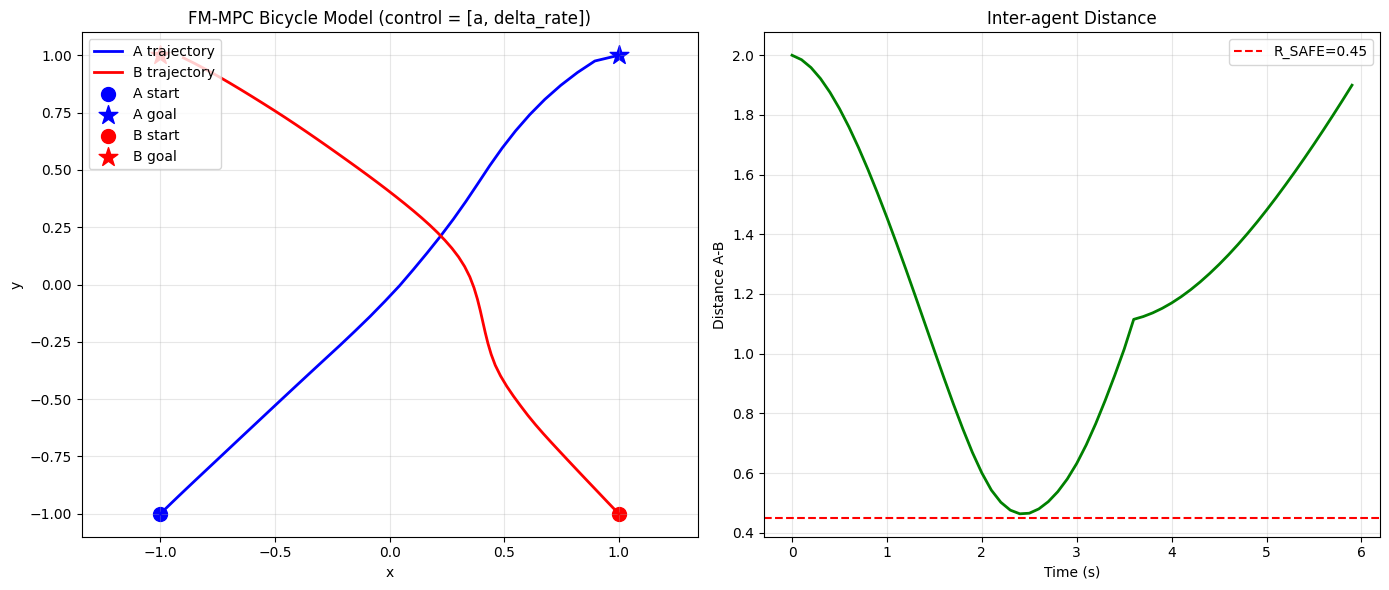

[A final] pos=[1. 1.], dist_to_goal=0.0000, v=0.910, delta=-13.1°
[B final] pos=[-0.89968     0.98881084], dist_to_goal=0.1009, v=0.572, delta=8.3°
[Safety] min_dist=0.4633 (R_SAFE=0.45)


In [ ]:
# # ===============================================================
# # PATCH CELL: Bicycle Model
# # state = [x, y, theta, v, delta], control = [a, delta_rate]
# # 
# # Bicycle kinematics:
# #   x_dot     = v * cos(theta)
# #   y_dot     = v * sin(theta)
# #   theta_dot = v * tan(delta) / L
# #   v_dot     = a
# #   delta_dot = delta_rate
# # ===============================================================

# import numpy as np
# import math
# import matplotlib.pyplot as plt

# # ---- Bicycle model parameters ----
# L = 0.3  # wheelbase (轴距)

# # ---- dynamics limits ----
# delta_max = np.deg2rad(45.0)       # 最大前轮转角
# delta_rate_max = np.deg2rad(120.0) # 最大转向速率


# def wrap_pi(th):
#     return (th + np.pi) % (2 * np.pi) - np.pi


# def vehicle_step_r(s, u, *, dt, v_max):
#     """
#     Bicycle model step.
#     s = [x, y, theta, v, delta]
#     u = [a, delta_rate]
#     """
#     x, y, th, v, delta = s
#     a, delta_rate = float(u[0]), float(u[1])

#     a = float(np.clip(a, -a_max, a_max))
#     delta_rate = float(np.clip(delta_rate, -delta_rate_max, delta_rate_max))

#     v2 = float(np.clip(v + dt * a, v_min, v_max))
#     if v2 < v_floor and abs(a) > 1e-4:
#         v2 = v_floor

#     # Update steering angle
#     delta2 = float(np.clip(delta + dt * delta_rate, -delta_max, delta_max))
    
#     # Bicycle kinematics: omega = v * tan(delta) / L
#     omega = v2 * math.tan(delta2) / L
#     th2 = float(wrap_pi(th + dt * omega))

#     x2 = float(x + dt * v2 * math.cos(th2))
#     y2 = float(y + dt * v2 * math.sin(th2))
#     return np.array([x2, y2, th2, v2, delta2], np.float32)


# def rollout_vehicle_r(s0, a_seq, rdot_seq, *, dt, v_max):
#     Hh = int(len(a_seq))
#     st = np.zeros((Hh + 1, 5), np.float32)
#     st[0] = s0
#     for i in range(Hh):
#         st[i + 1] = vehicle_step_r(st[i], (a_seq[i], rdot_seq[i]), dt=dt, v_max=v_max)
#     return st[:, :2], st


# def _resample_idx(T_src, T_dst):
#     if T_src <= 1:
#         return np.zeros((T_dst,), dtype=np.int32)
#     return np.linspace(0, T_src - 1, T_dst).astype(np.int32)


# def extract_controls_delta_rate_tracking(*, self_state, x_can, controls_norm, H, tf, dt_exec, v_max_self):
#     """FM path -> tracking controller -> [a, delta_rate]"""
#     T = int(x_can.shape[1])

#     xy_can = np.stack([x_can[0, :], x_can[1, :]], axis=1).astype(np.float32)
#     xy_ref = tf['c2w'](xy_can).astype(np.float32)

#     th_can = np.asarray(x_can[2, :], dtype=np.float32)
#     th_ref = wrap_pi(th_can + float(tf['angle_offset']))

#     # FM second control channel as feedforward delta_rate prior
#     if controls_norm is not None:
#         ctrl = np.asarray(controls_norm, dtype=np.float32)
#         if ctrl.ndim == 2 and ctrl.shape[1] == 2:
#             rdot_ff_raw = ctrl[:, 1]
#         elif ctrl.ndim == 2 and ctrl.shape[0] == 2:
#             rdot_ff_raw = ctrl[1, :]
#         else:
#             rdot_ff_raw = x_can[4, :]
#     else:
#         rdot_ff_raw = x_can[4, :]

#     idx = _resample_idx(T, H + 1)
#     ref_xy = xy_ref[idx]
#     ref_th = th_ref[idx]
#     rdot_ff = np.asarray(rdot_ff_raw, dtype=np.float32)[idx[:-1]]

#     lookahead_ratio = 0.18
#     k_delta = 2.0   # gain for desired steering angle
#     k_accel = 1.3

#     s = np.asarray(self_state, dtype=np.float32).copy()  # [x,y,th,v,delta]
#     a_seq = np.zeros((H,), dtype=np.float32)
#     rdot_seq = np.zeros((H,), dtype=np.float32)

#     for i in range(H):
#         x, y, th, v, delta = s
        
#         look_idx = min(i + 1 + int(lookahead_ratio * H), H)
#         p_tar = ref_xy[look_idx]

#         vec = p_tar - s[:2]
#         d = float(np.linalg.norm(vec))

#         th_pos = float(np.arctan2(vec[1], vec[0])) if d > 1e-6 else float(ref_th[min(i + 1, H)])
#         e_pos = float(wrap_pi(th_pos - th))
#         e_ref = float(wrap_pi(float(ref_th[min(i + 1, H)]) - th))
#         e_mix = 0.7 * e_pos + 0.3 * e_ref

#         # For bicycle: compute desired steering angle from heading error
#         # delta_des = atan(L * k * e_th / v)
#         v_eff = max(abs(v), v_floor)
#         delta_des = float(np.arctan(L * k_delta * e_mix / v_eff))
#         delta_des = float(np.clip(delta_des, -delta_max, delta_max))
        
#         # delta_rate to reach desired steering angle
#         rdot_fb = float(np.clip((delta_des - delta) / max(1e-6, dt_exec), -delta_rate_max, delta_rate_max))

#         # blend FM feedforward and feedback tracking
#         rdot = float(np.clip(0.35 * float(rdot_ff[i]) + 0.65 * rdot_fb, -delta_rate_max, delta_rate_max))

#         v_ref = float(np.clip(d / max(1e-6, dt_exec), v_floor, v_max_self))
#         # Slow down when steering hard
#         turn_penalty = max(0.3, 1.0 - 0.5 * abs(delta) / delta_max)
#         v_ref *= turn_penalty
#         a = float(np.clip(k_accel * (v_ref - v), -a_max, a_max))

#         a_seq[i] = a
#         rdot_seq[i] = rdot
#         s = vehicle_step_r(s, (a, rdot), dt=dt_exec, v_max=v_max_self)

#     return a_seq, rdot_seq


# def fm_sample_candidate_delta_rate(*, self_state, goal_xy, other_xy, seed, dist_AB, v_max_self):
#     tf_raw = build_can_tf(self_state[:2], goal_xy)
#     # Compatibility: older cells may define build_can_tf() returning a tuple.
#     if isinstance(tf_raw, dict):
#         tf = tf_raw
#     else:
#         world_to_can, start_can, goal_can = tf_raw
#         start_xy = np.asarray(self_state[:2], np.float32).reshape(2)
#         goal_xy_arr = np.asarray(goal_xy, np.float32).reshape(2)
#         gvec = goal_xy_arr - start_xy
#         angle_offset = float(np.arctan2(gvec[1], gvec[0]))
#         c, s = float(np.cos(angle_offset)), float(np.sin(angle_offset))
#         R_cw = np.array([[c, -s], [s, c]], np.float32)

#         def can_to_world(xy_can):
#             xy_can = np.asarray(xy_can, np.float32).reshape(-1, 2)
#             return ((R_cw @ xy_can.T).T + start_xy).astype(np.float32)

#         tf = {
#             'w2c': world_to_can,
#             'c2w': can_to_world,
#             'start_can': np.asarray(start_can, np.float32).reshape(2),
#             'goal_can': np.asarray(goal_can, np.float32).reshape(2),
#             'angle_offset': angle_offset,
#             'dist': float(np.linalg.norm(gvec)),
#         }

#     other_can = tf['w2c'](np.asarray(other_xy, np.float32).reshape(1, 2))[0]
#     # Inflate obstacle slightly above R_SAFE to leave tracking margin.
#     r_obs = 0.60 if dist_AB < 1.2 else 0.55
#     ellipses = [{"center": other_can, "radius": float(r_obs)}]

#     # Safety-first: always use CBF, and strengthen when agents are close.
#     use_cbf = True
#     cbf_kwargs = {
#         "passes": 8 if dist_AB < 1.2 else 4,
#         "extra_margin": 0.16 if dist_AB < 1.2 else 0.10,
#         "alpha": 24.0 if dist_AB < 1.2 else 14.0,
#         "max_corr_norm": 3.5,
#         "MASK_GATE": 1.0,
#         "SUPPRESS_FRAC": 0.0,
#         "RAMP_FRAC": 0.10,
#     }
#     # Compatibility: older cells define make_x0_noise_can(T, seed) without scale.
#     try:
#         x0_noise = make_x0_noise_can(T_steps, seed=seed, scale=0.03)
#     except TypeError:
#         x0_noise = make_x0_noise_can(T_steps, seed=seed)
#     cond_vec = np.array([1, 0, 1, 0, 0], np.float32)

#     x_can, _, controls_norm = piecewise_sample_fm_5ch_with_cbf(
#         model_5ch=model_5ch,
#         T_steps=T_steps,
#         device=str(device),
#         total_time=total_time,
#         num_segments=num_segments,
#         ode_method=ode_method,
#         atol=1e-5,
#         rtol=1e-5,
#         x0_noise=x0_noise,
#         cond=cond_vec,
#         start_xy_norm=tf['start_can'],
#         goal_xy_norm=tf['goal_can'],
#         ellipses=ellipses,
#         cbf_kwargs=cbf_kwargs,
#         use_cbf=use_cbf,
#         goal_guidance_weight=0.55,
#         goal_guidance_mode="tail",
#     )

#     a_seq, rdot_seq = extract_controls_delta_rate_tracking(
#         self_state=self_state,
#         x_can=x_can,
#         controls_norm=controls_norm,
#         H=H,
#         tf=tf,
#         dt_exec=dt_exec,
#         v_max_self=v_max_self,
#     )
#     return a_seq, rdot_seq, bool(use_cbf)


# def candidate_cost_delta(pos_self, states_self, pos_other_pred, goal_xy, a_seq, rdot_seq, *, v_pref=0.8):
#     goal_xy = np.asarray(goal_xy, np.float32)

#     d_end = float(np.linalg.norm(pos_self[-1] - goal_xy))
#     d_path = float(np.mean(np.linalg.norm(pos_self - goal_xy[None, :], axis=1)))

#     d = np.linalg.norm(pos_self - pos_other_pred, axis=1)
#     viol = np.clip(R_SAFE - d, 0.0, None)
#     coll = float(np.sum(viol ** 2))

#     da = np.diff(a_seq, prepend=a_seq[0])
#     dr = np.diff(rdot_seq, prepend=rdot_seq[0])
#     smooth = float(np.mean(da * da + 0.15 * dr * dr))

#     v_mean = float(np.mean(states_self[:, 3]))
#     speed_pref = float((v_pref - v_mean) ** 2)

#     # Safety-first weighting: increase collision pressure vs path greediness.
#     return (
#         8.0 * d_end +
#         0.8 * d_path +
#         520.0 * coll +
#         0.20 * smooth +
#         0.06 * speed_pref
#     )


# def predict_other_traj_delta(other_state, other_u_last, *, dt, v_max):
#     if other_u_last is None:
#         other_u_last = np.zeros(2, np.float32)
#     a_seq = np.full((H,), float(other_u_last[0]), np.float32)
#     rdot_seq = np.full((H,), float(other_u_last[1]), np.float32)
#     pos, st = rollout_vehicle_r(other_state, a_seq, rdot_seq, dt=dt, v_max=v_max)
#     return pos, st


# def mpc_pick_u0_delta(*, self_state, self_goal, other_state, other_u_last, v_max_self, v_max_other, seed_base):
#     dist_AB = float(np.linalg.norm(self_state[:2] - other_state[:2]))
#     pos_other_pred, _ = predict_other_traj_delta(other_state, other_u_last, dt=dt_exec, v_max=v_max_other)

#     best_J = None
#     best_u0 = None
#     use_cbf_count = 0

#     for k in range(K):
#         seed = int(seed_base + 97 * k)
#         a_seq, rdot_seq, used_cbf = fm_sample_candidate_delta_rate(
#             self_state=self_state,
#             goal_xy=self_goal,
#             other_xy=other_state[:2],
#             seed=seed,
#             dist_AB=dist_AB,
#             v_max_self=v_max_self,
#         )
#         use_cbf_count += int(used_cbf)

#         pos_self, st_self = rollout_vehicle_r(self_state, a_seq, rdot_seq, dt=dt_exec, v_max=v_max_self)
#         J = candidate_cost_delta(pos_self, st_self, pos_other_pred, self_goal, a_seq, rdot_seq, v_pref=0.8)

#         if (best_J is None) or (J < best_J):
#             best_J = J
#             best_u0 = np.array([float(a_seq[0]), float(rdot_seq[0])], np.float32)

#     if best_u0 is None or (not np.all(np.isfinite(best_u0))):
#         best_u0 = np.zeros(2, np.float32)
#         best_J = float("inf")

#     return best_u0, float(best_J), int(use_cbf_count), float(dist_AB)


# # ------------------ run ------------------
# xA0 = np.array([-1, -1], np.float32); gA = np.array([1, 1], np.float32)
# xB0 = np.array([1, -1], np.float32);  gB = np.array([-1, 1], np.float32)

# thA0 = math.atan2(gA[1] - xA0[1], gA[0] - xA0[0])
# thB0 = math.atan2(gB[1] - xB0[1], gB[0] - xB0[0])

# # state=[x,y,theta,v,delta]  (delta是前轮转角)
# sA = np.array([xA0[0], xA0[1], thA0, 0.0, 0.0], np.float32)
# sB = np.array([xB0[0], xB0[1], thB0, 0.0, 0.0], np.float32)

# trajA = [sA.copy()]
# trajB = [sB.copy()]

# uA_last = None
# uB_last = None
# fm_samples = 0
# cbf_used_total = 0
# REPLAN_EVERY_PATCH = 1

# for step in range(MAX_STEPS):
#     dA = float(np.linalg.norm(sA[:2] - gA))
#     dB = float(np.linalg.norm(sB[:2] - gB))
#     doneA = dA < goal_tol
#     doneB = dB < goal_tol
#     if doneA and doneB:
#         break

#     if step % REPLAN_EVERY_PATCH == 0:
#         if not doneA:
#             uA_last, _, cbfA, _ = mpc_pick_u0_delta(
#                 self_state=sA, self_goal=gA,
#                 other_state=sB, other_u_last=uB_last,
#                 v_max_self=v_max_A, v_max_other=v_max_B,
#                 seed_base=1000 + step * 10,
#             )
#             fm_samples += K
#             cbf_used_total += cbfA
#         else:
#             uA_last = np.zeros(2, np.float32)

#         if not doneB:
#             uB_last, _, cbfB, _ = mpc_pick_u0_delta(
#                 self_state=sB, self_goal=gB,
#                 other_state=sA, other_u_last=uA_last,
#                 v_max_self=v_max_B, v_max_other=v_max_A,
#                 seed_base=2000 + step * 10,
#             )
#             fm_samples += K
#             cbf_used_total += cbfB
#         else:
#             uB_last = np.zeros(2, np.float32)

#     if not doneA:
#         sA = vehicle_step_r(sA, uA_last, dt=dt_exec, v_max=v_max_A)
#     else:
#         sA[:2] = gA

#     if not doneB:
#         sB = vehicle_step_r(sB, uB_last, dt=dt_exec, v_max=v_max_B)
#     else:
#         sB[:2] = gB

#     trajA.append(sA.copy())
#     trajB.append(sB.copy())

# trajA = np.asarray(trajA, np.float32)
# trajB = np.asarray(trajB, np.float32)

# dist_AB_over_time = np.linalg.norm(trajA[:, :2] - trajB[:, :2], axis=1)

# fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# ax1, ax2 = axes
# ax1.plot(trajA[:, 0], trajA[:, 1], 'b-', lw=2, label='A trajectory')
# ax1.plot(trajB[:, 0], trajB[:, 1], 'r-', lw=2, label='B trajectory')
# ax1.scatter([xA0[0]], [xA0[1]], c='blue', s=100, marker='o', label='A start')
# ax1.scatter([gA[0]], [gA[1]], c='blue', s=200, marker='*', label='A goal')
# ax1.scatter([xB0[0]], [xB0[1]], c='red', s=100, marker='o', label='B start')
# ax1.scatter([gB[0]], [gB[1]], c='red', s=200, marker='*', label='B goal')
# ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.axis('equal'); ax1.grid(alpha=0.3)
# ax1.legend(loc='upper left'); ax1.set_title('FM-MPC Bicycle Model (control = [a, delta_rate])')

# time_axis = np.arange(len(dist_AB_over_time)) * dt_exec
# ax2.plot(time_axis, dist_AB_over_time, 'g-', lw=2)
# ax2.axhline(y=R_SAFE, color='r', linestyle='--', label=f'R_SAFE={R_SAFE}')
# ax2.set_xlabel('Time (s)'); ax2.set_ylabel('Distance A-B'); ax2.grid(alpha=0.3)
# ax2.legend(); ax2.set_title('Inter-agent Distance')

# plt.tight_layout(); plt.show()

# print(f"[A final] pos={trajA[-1,:2]}, dist_to_goal={float(np.linalg.norm(trajA[-1,:2]-gA)):.4f}, v={trajA[-1,3]:.3f}, delta={np.rad2deg(trajA[-1,4]):.1f}°")
# print(f"[B final] pos={trajB[-1,:2]}, dist_to_goal={float(np.linalg.norm(trajB[-1,:2]-gB)):.4f}, v={trajB[-1,3]:.3f}, delta={np.rad2deg(trajB[-1,4]):.1f}°")
# print(f"[Safety] min_dist={float(dist_AB_over_time.min()):.4f} (R_SAFE={R_SAFE})")

[device] cuda
[sampler] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[sampler params] ['model_5ch', 'T_steps', 'device', 'total_time', 'num_segments', 'ode_method', 'atol', 'rtol', 'noise_scale', 'x0_noise', 'cond', 'start_xy', 'start_xy_norm', 'start_guidance_weight', 'lock_start', 'goal_xy', 'goal_xy_norm', 'goal_guidance_weight', 'goal_guidance_mode', 'use_cbf', 'scaler', 'ellipses', 'tau0_hf', 'p_hf', 'lf_on', 'hf_max', 'cbf_kwargs']
[model] loaded
FM-MPC Bicycle - NO COST (CBF only)
[step   0] dA=2.828 dB=2.828 dist_AB=2.000
[step   1] dA=2.817 dB=2.820 dist_AB=1.987
[step   2] dA=2.798 dB=2.808 dist_AB=1.964
[step   3] dA=2.774 dB=2.792 dist_AB=1.937
[step   4] dA=2.746 dB=2.774 dist_AB=1.906
[step   5] dA=2.713 dB=2.755 dist_AB=1.871
[step   6] dA=2.677 dB=2.736 dist_AB=1.836
[step   7] dA=2.639 dB=2.715 dist_AB=1.802
[step   8] dA=2.601 dB=2.692 dist_AB=1.768
[step   9] dA=2.562 dB=2.667 dist_AB=1.733
[step  20] dA=1.977 dB=2.295 dist_AB=1.305
[step  40] dA=0.987 d

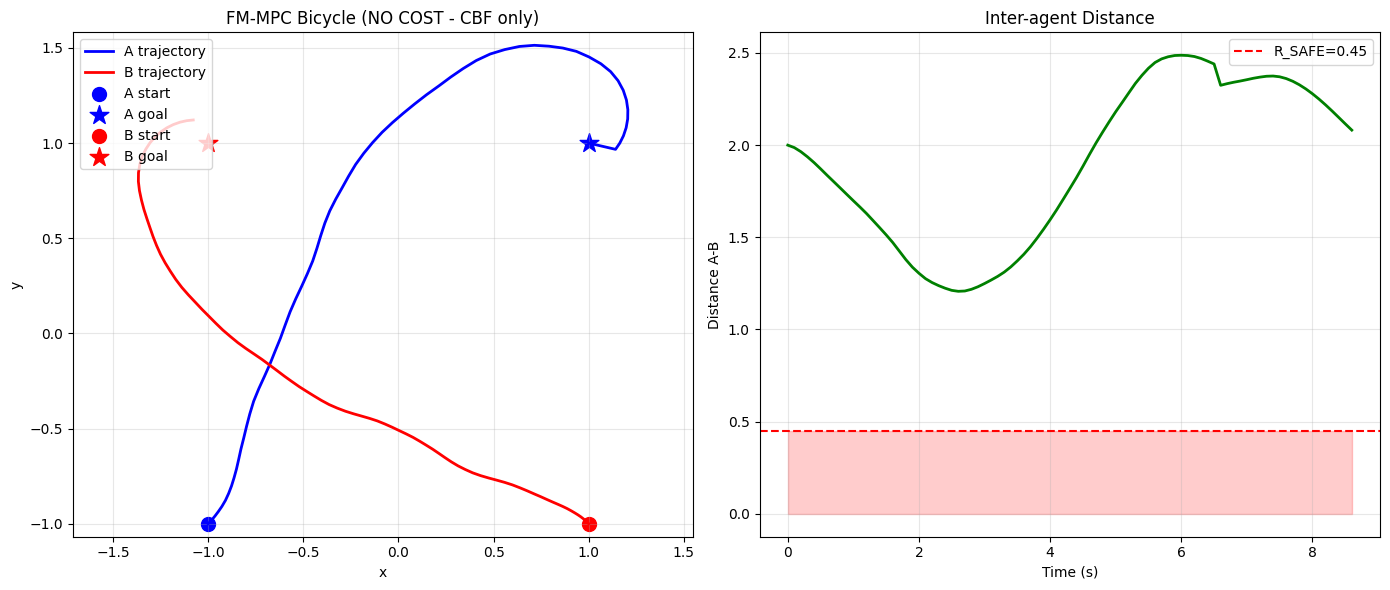


[A final] pos=[1. 1.], dist_to_goal=0.0000
[B final] pos=[-1.0779898  1.1214838], dist_to_goal=0.1444


In [ ]:
# ===============================================================
# FM-MPC Bicycle Model - NO COST VERSION (完整独立版本)
# 直接用第一条 CBF 安全轨迹，不做 cost 选择
# ===============================================================

import sys, math
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[device] {device}")

# ===============================================================
# 0) Load sampler_5h
# ===============================================================
def find_nearest_file(filename: str, start: Path, max_up=12):
    start = start.resolve()
    candidates = []
    p = start
    for _ in range(max_up):
        candidates += list(p.rglob(filename))
        p = p.parent
    if not candidates:
        raise FileNotFoundError(f"{filename} not found from {start}")
    return sorted(candidates, key=lambda x: len(str(x)))[0]

# 清除旧的 sampler 缓存
modules_to_remove = [k for k in sys.modules.keys() if 'sampler' in k.lower()]
for mod in modules_to_remove:
    del sys.modules[mod]

# 也清除 dmpc_fm_cbf 相关的
modules_to_remove = [k for k in sys.modules.keys() if 'dmpc_fm_cbf' in k.lower()]
for mod in modules_to_remove:
    del sys.modules[mod]

import importlib.util
import inspect

sampler_path = find_nearest_file("sampler_5h.py", Path.cwd())
print(f"[sampler] {sampler_path}")

spec = importlib.util.spec_from_file_location("sampler_5h", sampler_path)
sampler_mod = importlib.util.module_from_spec(spec)
sys.modules["sampler_5h"] = sampler_mod
spec.loader.exec_module(sampler_mod)

piecewise_sample_fm_5ch_with_cbf = sampler_mod.piecewise_sample_fm_5ch_with_cbf

# 打印函数签名，确认参数名
sig = inspect.signature(piecewise_sample_fm_5ch_with_cbf)
print(f"[sampler params] {list(sig.parameters.keys())}")

# ===============================================================
# 1) Model check
# ===============================================================
if "model_5ch" not in dir():
    try:
        model_5ch = globals()["model_5ch"]
    except KeyError:
        raise RuntimeError("model_5ch must be loaded before running this cell!")

model_5ch = model_5ch.to(device).eval()
print("[model] loaded")

# ===============================================================
# 2) 所有参数定义
# ===============================================================
dt_exec = 0.10

# FM sampler params
T_steps      = 40
num_segments = 10
total_time   = 1.0
ode_method   = "euler"

# MPC params
H = 14
REPLAN_EVERY_PATCH = 1
MAX_STEPS = 300
goal_tol = 0.15

# Safety
R_SAFE = 0.45

# ===============================================================
# 3) Bicycle Model Parameters
# ===============================================================
L = 0.3  # wheelbase

v_max_A = 1.0
v_max_B = 0.6
v_min   = 0.0
v_floor = 0.08

a_max = 1.5
delta_max = np.deg2rad(45.0)
delta_rate_max = np.deg2rad(120.0)

def wrap_pi(th):
    return (th + np.pi) % (2 * np.pi) - np.pi

def vehicle_step_r(s, u, *, dt, v_max):
    x, y, th, v, delta = s
    a, delta_rate = float(u[0]), float(u[1])

    a = float(np.clip(a, -a_max, a_max))
    delta_rate = float(np.clip(delta_rate, -delta_rate_max, delta_rate_max))

    v2 = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and abs(a) > 1e-4:
        v2 = v_floor

    delta2 = float(np.clip(delta + dt * delta_rate, -delta_max, delta_max))
    omega = v2 * math.tan(delta2) / L
    th2 = float(wrap_pi(th + dt * omega))

    x2 = float(x + dt * v2 * math.cos(th2))
    y2 = float(y + dt * v2 * math.sin(th2))
    return np.array([x2, y2, th2, v2, delta2], np.float32)

def rollout_vehicle_r(s0, a_seq, rdot_seq, *, dt, v_max):
    Hh = int(len(a_seq))
    st = np.zeros((Hh + 1, 5), np.float32)
    st[0] = s0
    for i in range(Hh):
        st[i + 1] = vehicle_step_r(st[i], (a_seq[i], rdot_seq[i]), dt=dt, v_max=v_max)
    return st[:, :2], st

# ===============================================================
# 4) Canonical Frame Transform
# ===============================================================
def build_can_tf(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy, np.float32).reshape(2)
    
    d = goal - start
    dist = float(np.linalg.norm(d) + 1e-9)
    
    angle_offset = float(np.arctan2(d[1], d[0]))
    cos_th = d[0] / dist
    sin_th = d[1] / dist
    
    R_wc = np.array([[cos_th, sin_th],
                     [-sin_th, cos_th]], dtype=np.float32)
    R_cw = R_wc.T
    
    def world_to_can(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return ((xy - start) @ R_wc.T).astype(np.float32)
    
    def can_to_world(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return (xy @ R_cw.T + start).astype(np.float32)
    
    start_can = np.array([0.0, 0.0], np.float32)
    goal_can  = np.array([dist, 0.0], np.float32)
    
    return {
        'w2c': world_to_can,
        'c2w': can_to_world,
        'start_can': start_can,
        'goal_can': goal_can,
        'dist': dist,
        'angle_offset': angle_offset,
    }

def make_x0_noise_can(T, seed, scale=0.05):
    g = torch.Generator(device=device)
    g.manual_seed(int(seed))
    x0 = torch.randn((1, 5, T), device=device, generator=g) * float(scale)
    x0[:, :, 0] = 0.0
    return x0

# ===============================================================
# 5) Extract controls
# ===============================================================
def _resample_idx(T_src, T_dst):
    if T_src <= 1:
        return np.zeros((T_dst,), dtype=np.int32)
    return np.linspace(0, T_src - 1, T_dst).astype(np.int32)

def extract_controls_delta_rate_tracking(*, self_state, x_can, controls_norm, H, tf, dt_exec, v_max_self):
    T = int(x_can.shape[1])

    xy_can = np.stack([x_can[0, :], x_can[1, :]], axis=1).astype(np.float32)
    xy_ref = tf['c2w'](xy_can).astype(np.float32)

    th_can = np.asarray(x_can[2, :], dtype=np.float32)
    th_ref = wrap_pi(th_can + float(tf['angle_offset']))

    if controls_norm is not None:
        ctrl = np.asarray(controls_norm, dtype=np.float32)
        if ctrl.ndim == 2 and ctrl.shape[1] == 2:
            rdot_ff_raw = ctrl[:, 1]
        elif ctrl.ndim == 2 and ctrl.shape[0] == 2:
            rdot_ff_raw = ctrl[1, :]
        else:
            rdot_ff_raw = x_can[4, :]
    else:
        rdot_ff_raw = x_can[4, :]

    idx = _resample_idx(T, H + 1)
    ref_xy = xy_ref[idx]
    ref_th = th_ref[idx]
    rdot_ff = np.asarray(rdot_ff_raw, dtype=np.float32)[idx[:-1]]

    lookahead_ratio = 0.18
    k_delta = 2.0
    k_accel = 1.3

    s = np.asarray(self_state, dtype=np.float32).copy()
    a_seq = np.zeros((H,), dtype=np.float32)
    rdot_seq = np.zeros((H,), dtype=np.float32)

    for i in range(H):
        x, y, th, v, delta = s
        
        look_idx = min(i + 1 + int(lookahead_ratio * H), H)
        p_tar = ref_xy[look_idx]

        vec = p_tar - s[:2]
        d = float(np.linalg.norm(vec))

        th_pos = float(np.arctan2(vec[1], vec[0])) if d > 1e-6 else float(ref_th[min(i + 1, H)])
        e_pos = float(wrap_pi(th_pos - th))
        e_ref = float(wrap_pi(float(ref_th[min(i + 1, H)]) - th))
        e_mix = 0.7 * e_pos + 0.3 * e_ref

        v_eff = max(abs(v), v_floor)
        delta_des = float(np.arctan(L * k_delta * e_mix / v_eff))
        delta_des = float(np.clip(delta_des, -delta_max, delta_max))
        
        rdot_fb = float(np.clip((delta_des - delta) / max(1e-6, dt_exec), -delta_rate_max, delta_rate_max))
        rdot = float(np.clip(0.35 * float(rdot_ff[i]) + 0.65 * rdot_fb, -delta_rate_max, delta_rate_max))

        v_ref = float(np.clip(d / max(1e-6, dt_exec), v_floor, v_max_self))
        turn_penalty = max(0.3, 1.0 - 0.5 * abs(delta) / delta_max)
        heading_penalty = max(0.25, 1.0 - 0.7 * abs(e_mix) / np.pi)
        v_ref *= turn_penalty * heading_penalty
        a = float(np.clip(k_accel * (v_ref - v), -a_max, a_max))

        a_seq[i] = a
        rdot_seq[i] = rdot
        s = vehicle_step_r(s, (a, rdot), dt=dt_exec, v_max=v_max_self)

    return a_seq, rdot_seq

# ===============================================================
# 6) FM sampling (single trajectory, no cost)
# ===============================================================
def fm_sample_single_trajectory(*, self_state, goal_xy, other_xy, seed, dist_AB, v_max_self):
    tf = build_can_tf(self_state[:2], goal_xy)

    other_can = tf['w2c'](np.asarray(other_xy, np.float32).reshape(1, 2))[0]
    r_obs = 0.50 if dist_AB < 1.0 else 0.45
    ellipses = [{"center": other_can, "radius": float(r_obs)}]

    use_cbf = True
    cbf_kwargs = {
        "passes": 8 if dist_AB < 1.0 else 4,
        "extra_margin": 0.16 if dist_AB < 1.0 else 0.10,
        "alpha": 22.0 if dist_AB < 1.0 else 12.0,
        "max_corr_norm": 3.5,
    }
    
    x0_noise = make_x0_noise_can(T_steps, seed=seed, scale=0.03)

    # 调用 sampler - 使用新版参数
    x_can, _, controls_norm = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch,
        T_steps=T_steps,
        device=str(device),
        total_time=total_time,
        num_segments=num_segments,
        ode_method=ode_method,
        atol=1e-5,
        rtol=1e-5,
        noise_scale=1.0,
        x0_noise=x0_noise,
        # guidance
        start_xy_norm=tf['start_can'],
        goal_xy_norm=tf['goal_can'],
        start_guidance_weight=0.3,
        lock_start=True,
        goal_guidance_weight=0.55,
        goal_guidance_mode="tail",
        # CBF
        use_cbf=use_cbf,
        scaler=None,
        ellipses=ellipses,
        cbf_kwargs=cbf_kwargs,
    )

    a_seq, rdot_seq = extract_controls_delta_rate_tracking(
        self_state=self_state,
        x_can=x_can,
        controls_norm=controls_norm,
        H=H,
        tf=tf,
        dt_exec=dt_exec,
        v_max_self=v_max_self,
    )
    return a_seq, rdot_seq, bool(use_cbf)

# ===============================================================
# 7) MPC - NO COST VERSION
# ===============================================================
def mpc_pick_u0_no_cost(*, self_state, self_goal, other_state, v_max_self, seed_base):
    dist_AB = float(np.linalg.norm(self_state[:2] - other_state[:2]))
    seed = int(seed_base)
    
    a_seq, rdot_seq, used_cbf = fm_sample_single_trajectory(
        self_state=self_state,
        goal_xy=self_goal,
        other_xy=other_state[:2],
        seed=seed,
        dist_AB=dist_AB,
        v_max_self=v_max_self,
    )
    
    u0 = np.array([float(a_seq[0]), float(rdot_seq[0])], np.float32)
    
    if not np.all(np.isfinite(u0)):
        u0 = np.zeros(2, np.float32)
    
    return u0, int(used_cbf), float(dist_AB)

# ===============================================================
# 8) Scenario & Run
# ===============================================================
xA0 = np.array([-1, -1], np.float32); gA = np.array([1, 1], np.float32)
xB0 = np.array([1, -1], np.float32);  gB = np.array([-1, 1], np.float32)

thA0 = math.atan2(gA[1] - xA0[1], gA[0] - xA0[0])
thB0 = math.atan2(gB[1] - xB0[1], gB[0] - xB0[0])

sA = np.array([xA0[0], xA0[1], thA0, 0.0, 0.0], np.float32)
sB = np.array([xB0[0], xB0[1], thB0, 0.0, 0.0], np.float32)

trajA = [sA.copy()]
trajB = [sB.copy()]

uA_last = None
uB_last = None
fm_samples = 0
cbf_used_total = 0

print("=" * 60)
print("FM-MPC Bicycle - NO COST (CBF only)")
print("=" * 60)

for step in range(MAX_STEPS):
    dA = float(np.linalg.norm(sA[:2] - gA))
    dB = float(np.linalg.norm(sB[:2] - gB))
    doneA = dA < goal_tol
    doneB = dB < goal_tol
    if doneA and doneB:
        print(f"\n[DONE] Both reached goals at step {step}")
        break

    if step % REPLAN_EVERY_PATCH == 0:
        if not doneA:
            uA_last, cbfA, _ = mpc_pick_u0_no_cost(
                self_state=sA, self_goal=gA,
                other_state=sB,
                v_max_self=v_max_A,
                seed_base=1000 + step * 10,
            )
            fm_samples += 1
            cbf_used_total += cbfA
        else:
            uA_last = np.zeros(2, np.float32)

        if not doneB:
            uB_last, cbfB, _ = mpc_pick_u0_no_cost(
                self_state=sB, self_goal=gB,
                other_state=sA,
                v_max_self=v_max_B,
                seed_base=2000 + step * 10,
            )
            fm_samples += 1
            cbf_used_total += cbfB
        else:
            uB_last = np.zeros(2, np.float32)
        
        if step < 10 or step % 20 == 0:
            dist_AB = float(np.linalg.norm(sA[:2] - sB[:2]))
            print(f"[step {step:3d}] dA={dA:.3f} dB={dB:.3f} dist_AB={dist_AB:.3f}")

    if not doneA:
        sA = vehicle_step_r(sA, uA_last, dt=dt_exec, v_max=v_max_A)
    else:
        sA[:2] = gA

    if not doneB:
        sB = vehicle_step_r(sB, uB_last, dt=dt_exec, v_max=v_max_B)
    else:
        sB[:2] = gB

    trajA.append(sA.copy())
    trajB.append(sB.copy())

trajA = np.asarray(trajA, np.float32)
trajB = np.asarray(trajB, np.float32)

dist_AB_over_time = np.linalg.norm(trajA[:, :2] - trajB[:, :2], axis=1)

print(f"\n[Stats] FM samples={fm_samples}, CBF used={cbf_used_total}")
print(f"[Safety] min_dist={float(dist_AB_over_time.min()):.4f} (R_SAFE={R_SAFE})")

# ===============================================================
# 9) Plot
# ===============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax1, ax2 = axes

ax1.plot(trajA[:, 0], trajA[:, 1], 'b-', lw=2, label='A trajectory')
ax1.plot(trajB[:, 0], trajB[:, 1], 'r-', lw=2, label='B trajectory')
ax1.scatter([xA0[0]], [xA0[1]], c='blue', s=100, marker='o', label='A start')
ax1.scatter([gA[0]], [gA[1]], c='blue', s=200, marker='*', label='A goal')
ax1.scatter([xB0[0]], [xB0[1]], c='red', s=100, marker='o', label='B start')
ax1.scatter([gB[0]], [gB[1]], c='red', s=200, marker='*', label='B goal')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.axis('equal'); ax1.grid(alpha=0.3)
ax1.legend(loc='upper left'); ax1.set_title('FM-MPC Bicycle (NO COST - CBF only)')

time_axis = np.arange(len(dist_AB_over_time)) * dt_exec
ax2.plot(time_axis, dist_AB_over_time, 'g-', lw=2)
ax2.axhline(y=R_SAFE, color='r', linestyle='--', label=f'R_SAFE={R_SAFE}')
ax2.fill_between(time_axis, 0, R_SAFE, alpha=0.2, color='red')
ax2.set_xlabel('Time (s)'); ax2.set_ylabel('Distance A-B'); ax2.grid(alpha=0.3)
ax2.legend(); ax2.set_title('Inter-agent Distance')

plt.tight_layout(); plt.show()

print(f"\n[A final] pos={trajA[-1,:2]}, dist_to_goal={float(np.linalg.norm(trajA[-1,:2]-gA)):.4f}")
print(f"[B final] pos={trajB[-1,:2]}, dist_to_goal={float(np.linalg.norm(trajB[-1,:2]-gB)):.4f}")

[device] cuda
[sampler] D:\copy\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[sampler params] ['model_5ch', 'T_steps', 'device', 'total_time', 'num_segments', 'ode_method', 'atol', 'rtol', 'noise_scale', 'x0_noise', 'cond', 'start_xy', 'start_xy_norm', 'start_guidance_weight', 'lock_start', 'goal_xy', 'goal_xy_norm', 'goal_guidance_weight', 'goal_guidance_mode', 'use_cbf', 'scaler', 'ellipses', 'tau0_hf', 'p_hf', 'lf_on', 'hf_max', 'cbf_kwargs']
[model] loaded
FM-MPC Bicycle - NO COST (CBF only) + Correct Cond
cond = [dist, v0, cos(th0_can), sin(th0_can), delta0]
[step   0] dA=2.828 dB=2.828 dist_AB=2.000 vA=0.00 vB=0.00
[step   1] dA=2.816 dB=2.820 dist_AB=1.985 vA=0.13 vB=0.08
[step   2] dA=2.793 dB=2.807 dist_AB=1.960 vA=0.22 vB=0.14
[step   3] dA=2.763 dB=2.789 dist_AB=1.925 vA=0.30 vB=0.18
[step   4] dA=2.726 dB=2.767 dist_AB=1.883 vA=0.38 vB=0.22
[step   5] dA=2.680 dB=2.742 dist_AB=1.833 vA=0.45 vB=0.25
[step   6] dA=2.628 dB=2.713 dist_AB=1.776 vA=0.52 vB=0.29
[step   7] dA=2.570 dB=2

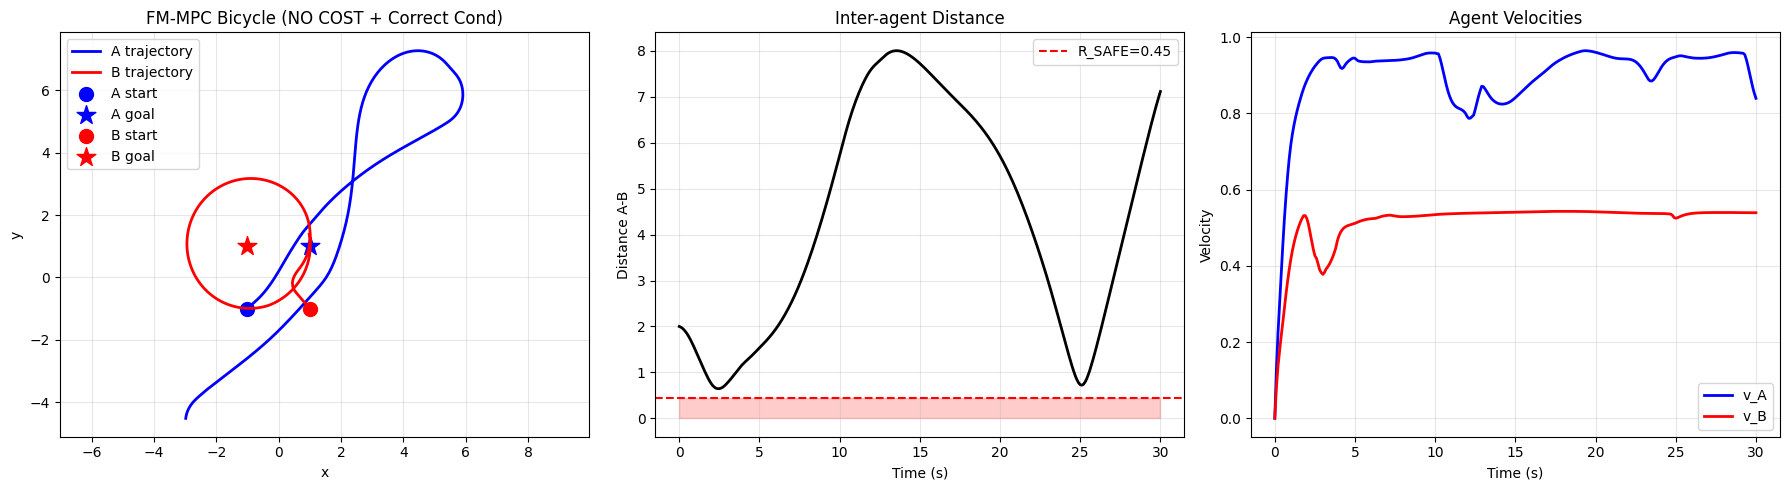


[A final] pos=[-2.9813764 -4.521947 ], dist_to_goal=6.8076
[B final] pos=[0.9809657 1.3866584], dist_to_goal=2.0183


In [120]:
# ===============================================================
# FM-MPC Bicycle Model - NO COST VERSION (带正确的 cond)
# 直接用第一条 CBF 安全轨迹，不做 cost 选择
# ===============================================================

import sys, math
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[device] {device}")

# ===============================================================
# 0) Load sampler_5h
# ===============================================================
def find_nearest_file(filename: str, start: Path, max_up=12):
    start = start.resolve()
    candidates = []
    p = start
    for _ in range(max_up):
        candidates += list(p.rglob(filename))
        p = p.parent
    if not candidates:
        raise FileNotFoundError(f"{filename} not found from {start}")
    return sorted(candidates, key=lambda x: len(str(x)))[0]

# 清除旧的 sampler 缓存
modules_to_remove = [k for k in sys.modules.keys() if 'sampler' in k.lower()]
for mod in modules_to_remove:
    del sys.modules[mod]

modules_to_remove = [k for k in sys.modules.keys() if 'dmpc_fm_cbf' in k.lower()]
for mod in modules_to_remove:
    del sys.modules[mod]

import importlib.util
import inspect

sampler_path = find_nearest_file("sampler_5h.py", Path.cwd())
print(f"[sampler] {sampler_path}")

spec = importlib.util.spec_from_file_location("sampler_5h", sampler_path)
sampler_mod = importlib.util.module_from_spec(spec)
sys.modules["sampler_5h"] = sampler_mod
spec.loader.exec_module(sampler_mod)

piecewise_sample_fm_5ch_with_cbf = sampler_mod.piecewise_sample_fm_5ch_with_cbf

sig = inspect.signature(piecewise_sample_fm_5ch_with_cbf)
print(f"[sampler params] {list(sig.parameters.keys())}")

# ===============================================================
# 1) Model check
# ===============================================================
if "model_5ch" not in dir():
    try:
        model_5ch = globals()["model_5ch"]
    except KeyError:
        raise RuntimeError("model_5ch must be loaded before running this cell!")

model_5ch = model_5ch.to(device).eval()
print("[model] loaded")

# ===============================================================
# 2) 所有参数定义
# ===============================================================
dt_exec = 0.10

# FM sampler params
T_steps      = 40
num_segments = 10
total_time   = 1.0
ode_method   = "euler"

# MPC params
H = 14
REPLAN_EVERY_PATCH = 1
MAX_STEPS = 300
goal_tol = 0.15

# Safety
R_SAFE = 0.45

# ===============================================================
# 3) Bicycle Model Parameters
# ===============================================================
L = 0.3  # wheelbase

v_max_A = 1.0
v_max_B = 0.6
v_min   = 0.0
v_floor = 0.08

a_max = 1.5
delta_max = np.deg2rad(45.0)
delta_rate_max = np.deg2rad(120.0)

def wrap_pi(th):
    return (th + np.pi) % (2 * np.pi) - np.pi

def vehicle_step_r(s, u, *, dt, v_max):
    x, y, th, v, delta = s
    a, delta_rate = float(u[0]), float(u[1])

    a = float(np.clip(a, -a_max, a_max))
    delta_rate = float(np.clip(delta_rate, -delta_rate_max, delta_rate_max))

    v2 = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and abs(a) > 1e-4:
        v2 = v_floor

    delta2 = float(np.clip(delta + dt * delta_rate, -delta_max, delta_max))
    omega = v2 * math.tan(delta2) / L
    th2 = float(wrap_pi(th + dt * omega))

    x2 = float(x + dt * v2 * math.cos(th2))
    y2 = float(y + dt * v2 * math.sin(th2))
    return np.array([x2, y2, th2, v2, delta2], np.float32)

def rollout_vehicle_r(s0, a_seq, rdot_seq, *, dt, v_max):
    Hh = int(len(a_seq))
    st = np.zeros((Hh + 1, 5), np.float32)
    st[0] = s0
    for i in range(Hh):
        st[i + 1] = vehicle_step_r(st[i], (a_seq[i], rdot_seq[i]), dt=dt, v_max=v_max)
    return st[:, :2], st

# ===============================================================
# 4) Canonical Frame Transform
# ===============================================================
def build_can_tf(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy, np.float32).reshape(2)
    
    d = goal - start
    dist = float(np.linalg.norm(d) + 1e-9)
    
    angle_offset = float(np.arctan2(d[1], d[0]))
    cos_th = d[0] / dist
    sin_th = d[1] / dist
    
    R_wc = np.array([[cos_th, sin_th],
                     [-sin_th, cos_th]], dtype=np.float32)
    R_cw = R_wc.T
    
    def world_to_can(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return ((xy - start) @ R_wc.T).astype(np.float32)
    
    def can_to_world(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return (xy @ R_cw.T + start).astype(np.float32)
    
    def world_to_can_angle(th_world):
        """World frame angle -> Canonical frame angle"""
        return wrap_pi(th_world - angle_offset)
    
    def can_to_world_angle(th_can):
        """Canonical frame angle -> World frame angle"""
        return wrap_pi(th_can + angle_offset)
    
    start_can = np.array([0.0, 0.0], np.float32)
    goal_can  = np.array([dist, 0.0], np.float32)
    
    return {
        'w2c': world_to_can,
        'c2w': can_to_world,
        'w2c_angle': world_to_can_angle,
        'c2w_angle': can_to_world_angle,
        'start_can': start_can,
        'goal_can': goal_can,
        'dist': dist,
        'angle_offset': angle_offset,
    }

def make_x0_noise_can(T, seed, scale=0.05):
    g = torch.Generator(device=device)
    g.manual_seed(int(seed))
    x0 = torch.randn((1, 5, T), device=device, generator=g) * float(scale)
    x0[:, :, 0] = 0.0
    return x0

# ===============================================================
# 5) Extract controls
# ===============================================================
def _resample_idx(T_src, T_dst):
    if T_src <= 1:
        return np.zeros((T_dst,), dtype=np.int32)
    return np.linspace(0, T_src - 1, T_dst).astype(np.int32)

def extract_controls_delta_rate_tracking(*, self_state, x_can, controls_norm, H, tf, dt_exec, v_max_self):
    T = int(x_can.shape[1])

    xy_can = np.stack([x_can[0, :], x_can[1, :]], axis=1).astype(np.float32)
    xy_ref = tf['c2w'](xy_can).astype(np.float32)

    th_can = np.asarray(x_can[2, :], dtype=np.float32)
    th_ref = wrap_pi(th_can + float(tf['angle_offset']))

    if controls_norm is not None:
        ctrl = np.asarray(controls_norm, dtype=np.float32)
        if ctrl.ndim == 2 and ctrl.shape[1] == 2:
            rdot_ff_raw = ctrl[:, 1]
        elif ctrl.ndim == 2 and ctrl.shape[0] == 2:
            rdot_ff_raw = ctrl[1, :]
        else:
            rdot_ff_raw = x_can[4, :]
    else:
        rdot_ff_raw = x_can[4, :]

    idx = _resample_idx(T, H + 1)
    ref_xy = xy_ref[idx]
    ref_th = th_ref[idx]
    rdot_ff = np.asarray(rdot_ff_raw, dtype=np.float32)[idx[:-1]]

    lookahead_ratio = 0.18
    k_delta = 2.0
    k_accel = 1.3

    s = np.asarray(self_state, dtype=np.float32).copy()
    a_seq = np.zeros((H,), dtype=np.float32)
    rdot_seq = np.zeros((H,), dtype=np.float32)

    for i in range(H):
        x, y, th, v, delta = s
        
        look_idx = min(i + 1 + int(lookahead_ratio * H), H)
        p_tar = ref_xy[look_idx]

        vec = p_tar - s[:2]
        d = float(np.linalg.norm(vec))

        th_pos = float(np.arctan2(vec[1], vec[0])) if d > 1e-6 else float(ref_th[min(i + 1, H)])
        e_pos = float(wrap_pi(th_pos - th))
        e_ref = float(wrap_pi(float(ref_th[min(i + 1, H)]) - th))
        e_mix = 0.7 * e_pos + 0.3 * e_ref

        v_eff = max(abs(v), v_floor)
        delta_des = float(np.arctan(L * k_delta * e_mix / v_eff))
        delta_des = float(np.clip(delta_des, -delta_max, delta_max))
        
        rdot_fb = float(np.clip((delta_des - delta) / max(1e-6, dt_exec), -delta_rate_max, delta_rate_max))
        rdot = float(np.clip(0.35 * float(rdot_ff[i]) + 0.65 * rdot_fb, -delta_rate_max, delta_rate_max))

        v_ref = float(np.clip(d / max(1e-6, dt_exec), v_floor, v_max_self))
        turn_penalty = max(0.3, 1.0 - 0.5 * abs(delta) / delta_max)
        heading_penalty = max(0.25, 1.0 - 0.7 * abs(e_mix) / np.pi)
        v_ref *= turn_penalty * heading_penalty
        a = float(np.clip(k_accel * (v_ref - v), -a_max, a_max))

        a_seq[i] = a
        rdot_seq[i] = rdot
        s = vehicle_step_r(s, (a, rdot), dt=dt_exec, v_max=v_max_self)

    return a_seq, rdot_seq

# ===============================================================
# 6) FM sampling (single trajectory, no cost) - 带正确的 cond
# ===============================================================
def fm_sample_single_trajectory(*, self_state, goal_xy, other_xy, seed, dist_AB, v_max_self):
    tf = build_can_tf(self_state[:2], goal_xy)

    other_can = tf['w2c'](np.asarray(other_xy, np.float32).reshape(1, 2))[0]
    r_obs = 0.50 if dist_AB < 1.0 else 0.45
    ellipses = [{"center": other_can, "radius": float(r_obs)}]

    use_cbf = True
    cbf_kwargs = {
        "passes": 8 if dist_AB < 1.0 else 4,
        "extra_margin": 0.16 if dist_AB < 1.0 else 0.10,
        "alpha": 22.0 if dist_AB < 1.0 else 12.0,
        "max_corr_norm": 3.5,
    }
    
    x0_noise = make_x0_noise_can(T_steps, seed=seed, scale=0.03)

    # ========== 正确的 cond (与训练时一致) ==========
    # cond = [dist, v0, cos(th0_can), sin(th0_can), delta0]
    v0 = float(self_state[3])                        # 初始速度
    th_world = float(self_state[2])                  # world frame heading
    th_can = tf['w2c_angle'](th_world)               # canonical frame heading
    delta0 = float(self_state[4])                    # 初始转向角
    
    cond_vec = np.array([
        tf['dist'],           # [0] 到目标的距离
        v0,                   # [1] 初始速度
        np.cos(th_can),       # [2] cos(初始 heading in canonical)
        np.sin(th_can),       # [3] sin(初始 heading in canonical)
        delta0,               # [4] 初始转向角
    ], dtype=np.float32)
    # ================================================

    x_can, _, controls_norm = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch,
        T_steps=T_steps,
        device=str(device),
        total_time=total_time,
        num_segments=num_segments,
        ode_method=ode_method,
        atol=1e-5,
        rtol=1e-5,
        noise_scale=1.0,
        x0_noise=x0_noise,
        cond=cond_vec,  # ✅ 添加正确的 cond
        # guidance
        start_xy_norm=tf['start_can'],
        goal_xy_norm=tf['goal_can'],
        start_guidance_weight=0.3,
        lock_start=True,
        goal_guidance_weight=0.55,
        goal_guidance_mode="tail",
        # CBF
        use_cbf=use_cbf,
        scaler=None,
        ellipses=ellipses,
        cbf_kwargs=cbf_kwargs,
    )

    a_seq, rdot_seq = extract_controls_delta_rate_tracking(
        self_state=self_state,
        x_can=x_can,
        controls_norm=controls_norm,
        H=H,
        tf=tf,
        dt_exec=dt_exec,
        v_max_self=v_max_self,
    )
    return a_seq, rdot_seq, bool(use_cbf)

# ===============================================================
# 7) MPC - NO COST VERSION
# ===============================================================
def mpc_pick_u0_no_cost(*, self_state, self_goal, other_state, v_max_self, seed_base):
    dist_AB = float(np.linalg.norm(self_state[:2] - other_state[:2]))
    seed = int(seed_base)
    
    a_seq, rdot_seq, used_cbf = fm_sample_single_trajectory(
        self_state=self_state,
        goal_xy=self_goal,
        other_xy=other_state[:2],
        seed=seed,
        dist_AB=dist_AB,
        v_max_self=v_max_self,
    )
    
    u0 = np.array([float(a_seq[0]), float(rdot_seq[0])], np.float32)
    
    if not np.all(np.isfinite(u0)):
        u0 = np.zeros(2, np.float32)
    
    return u0, int(used_cbf), float(dist_AB)

# ===============================================================
# 8) Scenario & Run
# ===============================================================
xA0 = np.array([-1, -1], np.float32); gA = np.array([1, 1], np.float32)
xB0 = np.array([1, -1], np.float32);  gB = np.array([-1, 1], np.float32)

thA0 = math.atan2(gA[1] - xA0[1], gA[0] - xA0[0])
thB0 = math.atan2(gB[1] - xB0[1], gB[0] - xB0[0])

sA = np.array([xA0[0], xA0[1], thA0, 0.0, 0.0], np.float32)
sB = np.array([xB0[0], xB0[1], thB0, 0.0, 0.0], np.float32)

trajA = [sA.copy()]
trajB = [sB.copy()]

uA_last = None
uB_last = None
fm_samples = 0
cbf_used_total = 0

print("=" * 60)
print("FM-MPC Bicycle - NO COST (CBF only) + Correct Cond")
print("=" * 60)
print(f"cond = [dist, v0, cos(th0_can), sin(th0_can), delta0]")
print("=" * 60)

for step in range(MAX_STEPS):
    dA = float(np.linalg.norm(sA[:2] - gA))
    dB = float(np.linalg.norm(sB[:2] - gB))
    doneA = dA < goal_tol
    doneB = dB < goal_tol
    if doneA and doneB:
        print(f"\n[DONE] Both reached goals at step {step}")
        break

    if step % REPLAN_EVERY_PATCH == 0:
        if not doneA:
            uA_last, cbfA, _ = mpc_pick_u0_no_cost(
                self_state=sA, self_goal=gA,
                other_state=sB,
                v_max_self=v_max_A,
                seed_base=1000 + step * 10,
            )
            fm_samples += 1
            cbf_used_total += cbfA
        else:
            uA_last = np.zeros(2, np.float32)

        if not doneB:
            uB_last, cbfB, _ = mpc_pick_u0_no_cost(
                self_state=sB, self_goal=gB,
                other_state=sA,
                v_max_self=v_max_B,
                seed_base=2000 + step * 10,
            )
            fm_samples += 1
            cbf_used_total += cbfB
        else:
            uB_last = np.zeros(2, np.float32)
        
        if step < 10 or step % 20 == 0:
            dist_AB = float(np.linalg.norm(sA[:2] - sB[:2]))
            print(f"[step {step:3d}] dA={dA:.3f} dB={dB:.3f} dist_AB={dist_AB:.3f} vA={sA[3]:.2f} vB={sB[3]:.2f}")

    if not doneA:
        sA = vehicle_step_r(sA, uA_last, dt=dt_exec, v_max=v_max_A)
    else:
        sA[:2] = gA

    if not doneB:
        sB = vehicle_step_r(sB, uB_last, dt=dt_exec, v_max=v_max_B)
    else:
        sB[:2] = gB

    trajA.append(sA.copy())
    trajB.append(sB.copy())

trajA = np.asarray(trajA, np.float32)
trajB = np.asarray(trajB, np.float32)

dist_AB_over_time = np.linalg.norm(trajA[:, :2] - trajB[:, :2], axis=1)
coll_steps = np.where(dist_AB_over_time < R_SAFE)[0]

print(f"\n[Stats] FM samples={fm_samples}, CBF used={cbf_used_total}")
print(f"[Safety] min_dist={float(dist_AB_over_time.min()):.4f} (R_SAFE={R_SAFE})")
print(f"[Safety] collision_steps={len(coll_steps)}")

# ===============================================================
# 9) Plot
# ===============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Trajectories
ax1 = axes[0]
ax1.plot(trajA[:, 0], trajA[:, 1], 'b-', lw=2, label='A trajectory')
ax1.plot(trajB[:, 0], trajB[:, 1], 'r-', lw=2, label='B trajectory')
ax1.scatter([xA0[0]], [xA0[1]], c='blue', s=100, marker='o', label='A start')
ax1.scatter([gA[0]], [gA[1]], c='blue', s=200, marker='*', label='A goal')
ax1.scatter([xB0[0]], [xB0[1]], c='red', s=100, marker='o', label='B start')
ax1.scatter([gB[0]], [gB[1]], c='red', s=200, marker='*', label='B goal')
if len(coll_steps) > 0:
    ax1.scatter(trajA[coll_steps, 0], trajA[coll_steps, 1], c='black', s=40, marker='x', label='Collision')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.axis('equal'); ax1.grid(alpha=0.3)
ax1.legend(loc='upper left'); ax1.set_title('FM-MPC Bicycle (NO COST + Correct Cond)')

# Distance
ax2 = axes[1]
time_axis = np.arange(len(dist_AB_over_time)) * dt_exec
ax2.plot(time_axis, dist_AB_over_time, 'k-', lw=2)
ax2.axhline(y=R_SAFE, color='r', linestyle='--', label=f'R_SAFE={R_SAFE}')
ax2.fill_between(time_axis, 0, R_SAFE, alpha=0.2, color='red')
ax2.set_xlabel('Time (s)'); ax2.set_ylabel('Distance A-B'); ax2.grid(alpha=0.3)
ax2.legend(); ax2.set_title('Inter-agent Distance')

# Velocities
ax3 = axes[2]
ax3.plot(time_axis[:len(trajA)], trajA[:, 3], 'b-', lw=2, label='v_A')
ax3.plot(time_axis[:len(trajB)], trajB[:, 3], 'r-', lw=2, label='v_B')
ax3.set_xlabel('Time (s)'); ax3.set_ylabel('Velocity'); ax3.grid(alpha=0.3)
ax3.legend(); ax3.set_title('Agent Velocities')

plt.tight_layout()
plt.show()

print(f"\n[A final] pos={trajA[-1,:2]}, dist_to_goal={float(np.linalg.norm(trajA[-1,:2]-gA)):.4f}")
print(f"[B final] pos={trajB[-1,:2]}, dist_to_goal={float(np.linalg.norm(trajB[-1,:2]-gB)):.4f}")

In [ ]:
# ============================================================
# FM-MPC Bicycle (Pure Pursuit STANDARD + Time-Expanded Prediction + Stop-at-Goal)
# - FM sampler outputs x_can (5,T): [x, y, theta, ?, ?]  (we mainly use XY path)
# - Control executed on bicycle: u = [a, delta_rate]
# Fixes:
#   1) Standard pure pursuit curvature -> delta_des (no unit-mixing)
#   2) Predict other agent by rolling out its last control (cheap + dynamic)
#   3) Use multiple predicted points as obstacles (time-expanded ellipses)
#   4) Smaller obstacle radius + mild inflation near
#   5) Proper goal speed profile + creep + full stop near goal
# ============================================================

import numpy as np, torch, math, sys, matplotlib.pyplot as plt
from pathlib import Path

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[device] {device}")

# ===============================================================
# 0) Load sampler_5h
# ===============================================================
repo_sampler = (Path.cwd().parent / "dmpc_fm_cbf" / "sampler_5h.py").resolve()
if repo_sampler.exists():
    sampler_path = repo_sampler
else:
    def find_nearest_file(filename, start, max_up=12):
        start = start.resolve()
        candidates = []
        p = start
        for _ in range(max_up):
            candidates += list(p.rglob(filename))
            p = p.parent
        if not candidates:
            raise FileNotFoundError(f"{filename} not found from {start}")
        return sorted(candidates, key=lambda x: len(str(x)))[0]
    sampler_path = find_nearest_file("sampler_5h.py", Path.cwd())

print(f"[sampler] {sampler_path}")

import importlib.util, inspect
spec = importlib.util.spec_from_file_location("sampler_5h", sampler_path)
sampler_mod = importlib.util.module_from_spec(spec)
sys.modules["sampler_5h"] = sampler_mod
spec.loader.exec_module(sampler_mod)

piecewise_sample_fm_5ch_with_cbf = sampler_mod.piecewise_sample_fm_5ch_with_cbf
sampler_sig = inspect.signature(piecewise_sample_fm_5ch_with_cbf)
print("[sampler sig]", sampler_sig)
assert "cond" in sampler_sig.parameters, "Loaded sampler has no cond; wrong sampler file?"

# ===============================================================
# 1) Model check
# ===============================================================
if "model_5ch" not in dir():
    try:
        model_5ch = globals()["model_5ch"]
    except KeyError:
        raise RuntimeError("model_5ch must be loaded before running this cell!")

model_5ch = model_5ch.to(device).eval()
print("[model] loaded")

# ===============================================================
# 2) Parameters
# ===============================================================
dt_exec = 0.10

# FM
T_steps      = 40
num_segments = 5
total_time   = 1.0
ode_method   = "euler"
noise_scale  = 0.08

# MPC
H = 12
K = 5
REPLAN_EVERY = 1
MAX_STEPS = 300

# Goal / stopping
goal_tol      = 0.35     # reach condition
stop_radius   = 0.45     # start braking hard and align
creep_radius  = 0.90     # start slowing down
v_creep       = 0.12     # crawl speed

# Safety
R_SAFE = 0.45

# ===============================================================
# 3) Bicycle dynamics  (state = [x, y, theta, v, delta])
# ===============================================================
v_max_A   = 1.0
v_max_B   = 0.6
v_min     = 0.0
a_max     = 1.5
L         = 0.30
delta_max = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_floor   = 0.05  # small positive to avoid deadlock at start

def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, *, dt, v_max):
    x, y, th, v, delta = s
    a  = float(np.clip(u[0], -a_max, a_max))
    dr = float(np.clip(u[1], -delta_rate_max, delta_rate_max))

    v2 = float(np.clip(v + dt * a, v_min, v_max))
    # if accelerating and too small, lift to floor to escape zero-speed singularity
    if v2 < v_floor and a > 0.02:
        v2 = v_floor

    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2 = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))

    x2 = x + dt * v2 * math.cos(th2)
    y2 = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, *, dt, v_max):
    Hh = U.shape[0]
    st = np.zeros((Hh+1, 5), dtype=np.float32)
    st[0] = s0
    for i in range(Hh):
        st[i+1] = bicycle_step(st[i], U[i], dt=dt, v_max=v_max)
    return st[:, :2], st

# ===============================================================
# 4) Canonical frame (SE2: start->origin, goal->+x)
# ===============================================================
def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy, np.float32).reshape(2)
    d = goal - start
    dist = float(np.linalg.norm(d) + 1e-9)
    c = float(d[0] / dist)
    s = float(d[1] / dist)

    R_wc = np.array([[c, s], [-s, c]], dtype=np.float32)  # world->can
    R_cw = R_wc.T

    def w2c(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return ((xy - start) @ R_wc.T).astype(np.float32)

    def c2w(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return (xy @ R_cw.T + start).astype(np.float32)

    def w2c_angle(th_w):
        # subtract canonical heading offset
        return wrap_pi(th_w - math.atan2(s, c))

    return {
        "w2c": w2c, "c2w": c2w,
        "w2c_angle": w2c_angle,
        "start_can": np.array([0.0, 0.0], np.float32),
        "goal_can":  np.array([dist, 0.0], np.float32),
        "dist": dist,
    }

# ===============================================================
# 5) CBF settings (time-expanded obstacles)
# ===============================================================
# Smaller radii (you asked to reduce)
r_obs_far  = 0.32
r_obs_near = 0.38

SAFE_DIST_FAR  = 2.0
SAFE_DIST_NEAR = 1.0

CBF_LIGHT  = dict(passes=2,  extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG = dict(passes=5, extra_margin=0.3, alpha=20.0, max_corr_norm=3.0)

def get_cbf_config(dist_AB):
    if dist_AB > SAFE_DIST_FAR:
        return False, None
    elif dist_AB > SAFE_DIST_NEAR:
        return True, CBF_LIGHT
    else:
        return True, CBF_STRONG

# ===============================================================
# 6) Other-agent prediction (cheap rollout with last control)
# ===============================================================
def predict_other_traj(other_state, other_u_last, *, H, dt, v_max):
    """
    Cheap dynamic prediction:
    - roll out bicycle using last executed control (constant over horizon)
    """
    if other_u_last is None:
        other_u_last = np.zeros(2, np.float32)
    U = np.tile(np.asarray(other_u_last, np.float32).reshape(1,2), (H,1))
    pos, st = rollout_bicycle(other_state, U, dt=dt, v_max=v_max)
    return pos, st

def build_time_expanded_ellipses(tf, other_pred_pos, dist_AB):
    """
    Create multiple obstacle circles along predicted other trajectory.
    Put more weight on early times.
    """
    if other_pred_pos is None or len(other_pred_pos) < 2:
        return []

    # choose indices biased toward early horizon
    idxs = [0, 1, 2, 4, 6, 8, 10, len(other_pred_pos)-1]
    idxs = [i for i in idxs if 0 <= i < len(other_pred_pos)]
    idxs = sorted(list(dict.fromkeys(idxs)))  # unique

    r = (r_obs_near if dist_AB < 1.2 else r_obs_far)
    ellipses = []
    for i in idxs:
        c_can = tf["w2c"](other_pred_pos[i].reshape(1,2))[0]
        ellipses.append({"center": c_can.copy(), "radius": float(r)})
    return ellipses

# ===============================================================
# 7) FM sampling (uses predicted other trajectory as time-expanded obstacles)
# ===============================================================
def make_x0_noise(T, seed):
    g = torch.Generator(device=device)
    g.manual_seed(int(seed))
    x0 = torch.randn((1, 5, T), device=device, generator=g) * float(noise_scale)
    x0[:, :, 0] = 0.0
    return x0

def sample_fm_path(*, self_state, goal_xy, other_pred_pos, seed):
    self_xy = self_state[:2]
    tf = build_canonical_frame(self_xy, goal_xy)

    # distance to other's current predicted position
    if other_pred_pos is None or len(other_pred_pos) == 0:
        other_now = self_xy
    else:
        other_now = other_pred_pos[0]
    dist_AB = float(np.linalg.norm(self_xy - other_now))

    use_cbf, cbf_kwargs = get_cbf_config(dist_AB)
    ellipses = build_time_expanded_ellipses(tf, other_pred_pos, dist_AB) if use_cbf else []

    x0_noise = make_x0_noise(T_steps, seed)

    # cond_vec: keep consistent with your training (dist, v0, cos(th_can), sin(th_can), delta0)
    v0 = float(self_state[3])
    th_can = tf["w2c_angle"](float(self_state[2]))
    delta0 = float(self_state[4])
    cond_vec = np.array([tf["dist"], v0, np.cos(th_can), np.sin(th_can), delta0], dtype=np.float32)

    x_can, states_norm, controls_norm = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch,
        T_steps=T_steps,
        device=str(device),
        total_time=total_time,
        num_segments=num_segments,
        ode_method=ode_method,
        atol=1e-4, rtol=1e-4,
        noise_scale=noise_scale,
        x0_noise=x0_noise,
        cond=cond_vec,
        start_xy_norm=tf["start_can"],
        goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.45,
        goal_guidance_weight=0.90,
        goal_guidance_mode="tail",
        lock_start=True,
        use_cbf=bool(use_cbf),
        scaler=None,
        ellipses=ellipses,
        cbf_kwargs=cbf_kwargs,
    )

    # use XY path only
    xy_can = x_can[0:2, :].T.astype(np.float32)     # (T,2)
    path_xy = tf["c2w"](xy_can).astype(np.float32)  # (T,2)
    return path_xy, bool(use_cbf), dist_AB

# ===============================================================
# 8) Standard Pure Pursuit -> bicycle controls
# ===============================================================
def _closest_index(path_xy, pos_xy):
    d = np.linalg.norm(path_xy - pos_xy.reshape(1,2), axis=1)
    return int(np.argmin(d))

def _lookahead_point(path_xy, pos_xy, *, Ld, start_idx=0):
    """
    Find first point whose distance to pos >= Ld, scanning forward.
    If not found, return last point.
    """
    for i in range(start_idx, len(path_xy)):
        if float(np.linalg.norm(path_xy[i] - pos_xy)) >= Ld:
            return path_xy[i], i
    return path_xy[-1], len(path_xy)-1

def pure_pursuit_controls(s0, path_xy, goal_xy, *, H, dt, v_max):
    """
    Standard pure pursuit for bicycle:
      alpha = angle(target - pos) - theta
      kappa = 2*sin(alpha)/Ld
      delta_des = atan(L*kappa)
      delta_rate = (delta_des - delta)/dt clipped
    Speed profile:
      far: approach v_max
      within creep_radius: scale down to v_creep
      within stop_radius: brake to stop
    """
    s = s0.copy()
    U = np.zeros((H, 2), dtype=np.float32)

    # tune
    Ld_min = 0.35
    Ld_max = 1.10
    k_v    = 1.2      # speed gain from goal distance
    k_brake = 4.0     # braking gain near stop

    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)

    last_path_idx = 0

    for i in range(H):
        x, y, th, v, delta = s
        pos = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))

        # --- goal stop logic ---
        if d_goal <= stop_radius:
            # brake and straighten wheels
            a = float(np.clip(-k_brake * v, -a_max, 0.0))
            delta_des = 0.0
            dr = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))
            U[i] = np.array([a, dr], dtype=np.float32)
            s = bicycle_step(s, U[i], dt=dt, v_max=v_max)
            continue

        # --- lookahead distance (bigger when faster) ---
        Ld = float(np.clip(0.55 + 0.65 * v, Ld_min, Ld_max))

        # find nearest on path then lookahead
        near_idx = _closest_index(path_xy, pos)
        near_idx = max(near_idx, last_path_idx)  # do not go backward
        target, last_path_idx = _lookahead_point(path_xy, pos, Ld=Ld, start_idx=near_idx)

        # bearing to target
        dx = float(target[0] - x)
        dy = float(target[1] - y)
        ang = float(math.atan2(dy, dx))
        alpha = float(wrap_pi(ang - th))

        # curvature & steering
        kappa = 2.0 * math.sin(alpha) / max(1e-3, Ld)
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))

        # speed profile (approach goal)
        v_des = float(np.clip(k_v * d_goal, v_creep, v_max))
        if d_goal < creep_radius:
            # linearly go to creep speed
            v_des = float(np.clip(v_creep + (v_max - v_creep) * (d_goal / creep_radius), v_creep, v_max))

        # turn penalty: slow down if steering large
        turn_pen = max(0.35, 1.0 - 0.55 * abs(delta_des) / delta_max)
        v_des *= turn_pen

        a = float(np.clip((v_des - v) / dt, -a_max, a_max))

        U[i] = np.array([a, dr], dtype=np.float32)
        s = bicycle_step(s, U[i], dt=dt, v_max=v_max)

    return U

# ===============================================================
# 9) Cost (optional but kept for K candidates selection)
#    If you want "NO COST", set K=1 and just take first sample.
# ===============================================================
W_END   = 18.0
W_PATH  = 1.5
W_COLL  = 450.0
W_SMOOTH = 0.25

def compute_cost(pos_self, pos_other_pred, goal_xy, U):
    goal_xy = np.asarray(goal_xy, np.float32)
    d_end = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path = float(np.mean(np.linalg.norm(pos_self - goal_xy.reshape(1,2), axis=1)))

    # time-aligned distance
    M = min(len(pos_self), len(pos_other_pred))
    if M <= 1:
        min_d = float("inf")
    else:
        d = np.linalg.norm(pos_self[:M] - pos_other_pred[:M], axis=1)
        min_d = float(d.min())

    viol = max(0.0, R_SAFE - min_d)
    coll = float(viol * viol)

    dU = np.diff(U, axis=0, prepend=U[0:1])
    smooth = float(np.mean(dU[:,0]**2 + 0.4*dU[:,1]**2))

    return W_END*d_end + W_PATH*d_path + W_COLL*coll + W_SMOOTH*smooth

# ===============================================================
# 10) MPC replan
# ===============================================================
def mpc_replan(self_state, goal_xy, other_state, other_u_last, *, v_max_self, v_max_other, seed_base):
    other_pred_pos, _ = predict_other_traj(other_state, other_u_last, H=H, dt=dt_exec, v_max=v_max_other)

    best = None  # (J, u0, path_cache, used_cbf)
    cbf_count = 0

    for k in range(K):
        seed = int(seed_base + 137*k + 7919)
        try:
            path_xy, used_cbf, distAB = sample_fm_path(
                self_state=self_state, goal_xy=goal_xy, other_pred_pos=other_pred_pos, seed=seed
            )
        except Exception as e:
            print(f"  [WARN] FM sample failed: {e}")
            continue

        cbf_count += int(used_cbf)

        U = pure_pursuit_controls(self_state, path_xy, goal_xy, H=H, dt=dt_exec, v_max=v_max_self)
        pos_self, st_self = rollout_bicycle(self_state, U, dt=dt_exec, v_max=v_max_self)

        J = compute_cost(pos_self, other_pred_pos, goal_xy, U)
        u0 = U[0].copy()

        if best is None or J < best[0]:
            best = (J, u0, path_xy.copy(), used_cbf)

    if best is None:
        return np.zeros(2, np.float32), float("inf"), None, 0

    return best[1], best[0], best[2], cbf_count

# ===============================================================
# 11) Scenario setup
# ===============================================================
xA0 = np.array([-1.2, -1.2], dtype=np.float32); gA = np.array([ 1.2,  1.2], dtype=np.float32)
xB0 = np.array([ 1.2, -1.2], dtype=np.float32); gB = np.array([-1.2,  1.2], dtype=np.float32)

thA0 = float(math.atan2(gA[1] - xA0[1], gA[0] - xA0[0]))
thB0 = float(math.atan2(gB[1] - xB0[1], gB[0] - xB0[0]))

# [x, y, theta, v, delta]
sA = np.array([xA0[0], xA0[1], thA0, 0.0, 0.0], dtype=np.float32)
sB = np.array([xB0[0], xB0[1], thB0, 0.0, 0.0], dtype=np.float32)

trajA = [sA.copy()]
trajB = [sB.copy()]
uA = np.zeros(2, np.float32)
uB = np.zeros(2, np.float32)

pathA_cache = None
pathB_cache = None

cbf_total = 0
replan_count = 0

print("="*60)
print("FM-MPC Bicycle (Pure Pursuit STANDARD + Time-Expanded Prediction)")
print("="*60)
print(f"H={H}, K={K}, dt={dt_exec}, T_steps={T_steps}")
print(f"goal_tol={goal_tol}, creep_radius={creep_radius}, stop_radius={stop_radius}, v_creep={v_creep}")
print("="*60)

# ===============================================================
# 12) Main loop
# ===============================================================
for step in range(MAX_STEPS):
    dA = float(np.linalg.norm(sA[:2] - gA))
    dB = float(np.linalg.norm(sB[:2] - gB))
    doneA = (dA < goal_tol and sA[3] < 0.08)
    doneB = (dB < goal_tol and sB[3] < 0.08)

    if doneA and doneB:
        print(f"\n[DONE] both reached goals at step {step}")
        break

    if step % REPLAN_EVERY == 0:
        replan_count += 1

        if not doneA:
            uA, JA, pathA_cache, cbfA = mpc_replan(
                sA, gA, sB, uB, v_max_self=v_max_A, v_max_other=v_max_B, seed_base=1000 + step*31
            )
            cbf_total += cbfA
        else:
            uA = np.zeros(2, np.float32)
            pathA_cache = None

        if not doneB:
            uB, JB, pathB_cache, cbfB = mpc_replan(
                sB, gB, sA, uA, v_max_self=v_max_B, v_max_other=v_max_A, seed_base=2000 + step*37
            )
            cbf_total += cbfB
        else:
            uB = np.zeros(2, np.float32)
            pathB_cache = None

        if step < 15 or step % 20 == 0:
            dist_AB = float(np.linalg.norm(sA[:2] - sB[:2]))
            print(f"[step {step:3d}] dA={dA:.3f} dB={dB:.3f} dist_AB={dist_AB:.3f} "
                  f"vA={sA[3]:.2f} vB={sB[3]:.2f} uA=[{uA[0]:+.2f},{uA[1]:+.2f}] uB=[{uB[0]:+.2f},{uB[1]:+.2f}]")

    # execute one step
    if not doneA:
        sA = bicycle_step(sA, uA, dt=dt_exec, v_max=v_max_A)
    if not doneB:
        sB = bicycle_step(sB, uB, dt=dt_exec, v_max=v_max_B)

    trajA.append(sA.copy())
    trajB.append(sB.copy())

trajA = np.asarray(trajA, np.float32)
trajB = np.asarray(trajB, np.float32)

print(f"\n[stats] replans={replan_count} | FM samples={replan_count * K * 2} | CBF used={cbf_total}")

# ===============================================================
# 13) Analysis & plots
# ===============================================================
dist_AB = np.linalg.norm(trajA[:, :2] - trajB[:, :2], axis=1)
coll_steps = np.where(dist_AB < R_SAFE)[0]
print(f"[collision] min_dist={float(dist_AB.min()):.4f} | collision_steps={len(coll_steps)}")
print(f"[A final] pos={trajA[-1,:2]} | dist_to_goal={float(np.linalg.norm(trajA[-1,:2]-gA)):.4f} | v={trajA[-1,3]:.3f}")
print(f"[B final] pos={trajB[-1,:2]} | dist_to_goal={float(np.linalg.norm(trajB[-1,:2]-gB)):.4f} | v={trajB[-1,3]:.3f}")

t = np.arange(len(trajA)) * dt_exec

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(trajA[:,0], trajA[:,1], lw=2, label="Agent A")
ax.plot(trajB[:,0], trajB[:,1], lw=2, label="Agent B")
ax.scatter([xA0[0]], [xA0[1]], s=90, marker="o", label="A start")
ax.scatter([gA[0]],  [gA[1]],  s=180, marker="*", label="A goal")
ax.scatter([xB0[0]], [xB0[1]], s=90, marker="o", label="B start")
ax.scatter([gB[0]],  [gB[1]],  s=180, marker="*", label="B goal")
if len(coll_steps) > 0:
    ax.scatter(trajA[coll_steps,0], trajA[coll_steps,1], s=40, marker="x", label="Collision(A)")
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("FM-MPC Bicycle: Trajectories")

ax2 = axes[1]
ax2.plot(t, dist_AB, lw=2)
ax2.axhline(R_SAFE, ls="--", label=f"R_safe={R_SAFE}")
ax2.fill_between(t, 0, R_SAFE, alpha=0.2)
ax2.grid(alpha=0.3); ax2.legend()
ax2.set_title("Distance Between Agents")
ax2.set_xlabel("Time (s)"); ax2.set_ylabel("Inter-agent Distance")

ax3 = axes[2]
ax3.plot(t, trajA[:,3], lw=2, label="v_A")
ax3.plot(t, trajB[:,3], lw=2, label="v_B")
ax3.grid(alpha=0.3); ax3.legend()
ax3.set_title("Agent Velocities")
ax3.set_xlabel("Time (s)"); ax3.set_ylabel("Velocity")

plt.tight_layout()
plt.show()
